In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
import statsmodels.api as sm
import pyfixest as pf          # PPML with absorbed fixed effects (ppmlhdfe)

try:
    import geopandas as gpd
except Exception:            # maps are optional in this notebook
    gpd = None
try:
    import seaborn as sns
except Exception:
    sns = None

# ---------------------------------------------------------------- style
document_width_pt = 511.0
plt.rc("font", family="serif")
toulouse_color = (132 / 255, 46 / 255, 27 / 255)
reference_color = toulouse_color#(0.75, 0.30, 0.20)
sim_color = (0.247, 0.404, 0.667)
font_size = 15
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size + 2,
    "xtick.labelsize": font_size - 3,
    "ytick.labelsize": font_size - 3,
    "legend.fontsize": font_size - 3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})


def get_figsize(document_width_pt=document_width_pt, wf=1.0, hf=0.5):
    """Figure size in inches from a LaTeX \\showthe\\columnwidth width in points."""
    fig_width = document_width_pt * wf / 72.27
    return [fig_width, fig_width * hf]


def _despine(ax=None):
    if sns is not None:
        sns.despine(ax=ax)
    else:
        for side in ("top", "right"):
            (ax or plt.gca()).spines[side].set_visible(False)


## Loading

`load_granular_data` rebuilds on the Python side the moment layout that
`load_parameters.jl` builds under `--granular=true --ca_level=aa`. The full (unmasked)
moment vector stacks six blocks in this order:

| # | block | length | content |
|---|-------|--------|---------|
| 1 | labor          | 1 | aggregate labor share |
| 2 | industry share | $S$ | share of the downstream industry's input bill going to each sector |
| 3 | $\pi_r$        | $R_d$ | share of downstream sales made in each downstream region |
| 4 | reg_coef       | $N_{REG}$ | distance-bin coefficients of the extensive margin (cloglog) |
| 5 | $\gamma$       | $S \times n_{AA}$ | sourcing shares by (sector, attraction area), sector-major |
| 6 | $\bar G_s(0)$  | $S$ | share of regions hosting no supplier of sector $s$ |

The criterion does not use all of them. `MOMENT_MASK` drops the first industry share and
the first $\pi_r$ (both are implied by the others adding up), every (sector, area) pair
with no observed supplier, and, in each sector, the **reference area** — the one with the
largest observed sourcing share, which the within-sector adding-up constraint determines
once the others are known. Block 6 is never masked.

**Which estimate is being reported.** `mu` selects it, and it selects *everything*
consistently — moments, standard errors, Jacobian, and the simulated firm-level economy:

| `mu` | estimate | moments | inference |
|------|----------|---------|-----------|
| 1 | $\hat\theta_1$, the Step-1 identity-weighted fit | `step1/best_simulated_moments.npy` | `step2/inference/` (inference *at* $\hat\theta_1$ is written there) |
| 2 | $\hat\theta_2$, the Step-3 efficiently-weighted fit | `step3/best_simulated_moments.npy` | `step3/inference/` |

The run folder is reconstructed from the flags rather than passed as a path, so a
mismatch between the flags used for estimation and the flags used here surfaces as a
missing folder instead of a plausible-looking but wrong set of numbers.


In [2]:
# Rebuilds, on the Python side, the moment layout `load_parameters.jl` builds under
# `--granular=true --ca_level=aa`, and reads back everything the reporting needs.
# The block layout, the mask and the meaning of `mu` are documented in the markdown
# cell above.

# mu -> (folder holding the moments, folder holding the inference)
MU_DIRS = {1: ("step1", "step2"), 2: ("step3", "step3")}


def reporting_folder(industry, base="..", profile_T=True, ca_level="aa",
                     granular=True, relax_n_lo=False, optimizer="pso"):
    """Reproduce main.jl's output_folder naming exactly."""
    name = f"reporting_{industry}"
    name += "_profiled" if profile_T else ""
    name += "_aa" if ca_level == "aa" else ""
    name += "_gran" if granular else ""
    name += "_nlo1" if (relax_n_lo and granular) else ""
    name += f"_{optimizer}"
    return Path(base) / name


def _read_named_value(coefs, name):
    """stats.csv scalar by name: a column called `name`, else a labelled row."""
    if name in coefs.columns:
        vals = coefs[name].dropna().values
        if len(vals):
            return float(vals[0])
    if "value" in coefs.columns:
        for col in coefs.columns:
            hit = coefs.index[coefs[col].astype(str).str.strip().str.lower() == name.lower()]
            if len(hit):
                return float(coefs.loc[hit[0], "value"])
    return None


def _gk_col(G_K, cands):
    """Column of G_K.csv by case-insensitive name, mirroring load_parameters.jl's _gk_col."""
    hit = next((c for c in G_K.columns if c.strip().lower() in cands), None)
    if hit is None:
        raise KeyError(f"G_K.csv is missing a column among {cands}; has {list(G_K.columns)}")
    return hit


def _as_ze_string(col):
    """ZE codes as 4-character strings, whether the column came back as int, float or str."""
    if pd.api.types.is_numeric_dtype(col):
        return col.astype("Int64").astype(str).str.zfill(4)
    return col.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(4)


def _aa_names(X_dr, n_AA):
    """
    Attraction-area names, in the model's AA column order.

    AA column `a` is anchored on the a-th downstream region, and the downstream
    regions are enumerated in ZE-index (sorted ze2010) order — which is the row
    order of X_dr.csv restricted to the downstream rows. The names live in
    `X_dr.query('downstream').ze2010_downstream`.
    """
    flag = next((c for c in ("downstream", "downstream_region") if c in X_dr.columns), None)
    if flag is None:
        raise KeyError("X_dr.csv has neither a `downstream` nor a `downstream_region` column")
    sub = X_dr[X_dr[flag].astype(bool)]
    col = next((c for c in ("ze2010_downstream", "ze2010") if c in sub.columns), None)
    if col is None:
        raise KeyError("X_dr.csv has neither `ze2010_downstream` nor `ze2010`")
    names = _as_ze_string(sub[col]).tolist()
    if len(names) != n_AA:
        raise ValueError(f"{len(names)} downstream rows in X_dr.csv vs n_AA = {n_AA} "
                         "attraction areas in attraction_area_linkages.npy")
    return names


def _region_labels(data):
    """
    Model region index (1..R) -> ZE code -> display NAME.

    The model orders regions by sorted `ze2010`, exactly as `load_parameters.jl` builds
    `X_rs`, so the l-th row of the distance matrix and the integer codes in
    `suppliers.parquet` are the l-th entry of that sorted list. `france` covers more
    commuting zones than the model does, so the join is on the CODE, and a zone with no
    name falls back to its code rather than to NaN.
    """
    fdf = data.get("filter_N_upstream_df")
    if fdf is None:
        codes = [str(i) for i in range(1, data["R"] + 1)]
    else:
        codes = sorted(_as_ze_string(fdf["ze2010"]).unique())
    if len(codes) != data["R"]:
        raise ValueError(f"{len(codes)} ZE codes in filter_N_upstream.csv but R = "
                         f"{data['R']} regions in the model.")
    out = pd.DataFrame({"index": np.arange(1, data["R"] + 1), "ze2010": codes})
    fr = data.get("france")
    if fr is not None and "ze2010_name" in fr.columns:
        names = fr[["ze2010", "ze2010_name"]].copy()
        names["ze2010"] = _as_ze_string(names["ze2010"])
        out = out.merge(names.drop_duplicates("ze2010"), on="ze2010", how="left")
    else:
        out["ze2010_name"] = out["ze2010"]
    out["ze2010_name"] = out["ze2010_name"].fillna(out["ze2010"])
    return out


def ze_name_of_code(data):
    """ZE code -> display name, for anything keyed on the code rather than the index."""
    lab = _region_labels(data)
    return dict(zip(lab["ze2010"], lab["ze2010_name"]))


def aa_display_names(data):
    """
    Attraction-area display names, in AA column order.

    Area `a` is anchored on the a-th downstream region, so its name is that commuting
    zone's name — which is what a reader recognises, unlike the bare ZE code.
    """
    m = ze_name_of_code(data)
    return [m.get(str(a), str(a)) for a in data["aa_names"]]


def load_granular_data(industry, mu=2, base="..", profile_T=True, ca_level="aa",
                       granular=True, relax_n_lo=False, optimizer="pso", K=-1,
                       k_max=None):
    """
    Load everything the granular / attraction-area reporting needs.

    Parameters
    ----------
    industry : str          "aero", "auto", ...
    mu       : 1 or 2       1 = step1 best parameters (mu_1), 2 = step3 best
                            parameters (mu_2, the efficient estimate).
    K        : int          which stage column of best_simulated_moments to read
                            (-1 = the last, i.e. the final stage of the step).

    Returns a flat dict meant to be splatted into the namespace, exactly like
    `load_industry_data` in analysis.ipynb:

        data = load_granular_data(industry, mu=2)
        globals().update(data)        # in a script / notebook cell

    which binds `input_folder`, `folder`, `coefs`, `agg_labor_share`, `epsilon`,
    `agg_industry_share`, `emp_pi_r`, `reg_coef`, `emp_gamma_ls`, `X_dr`, `X_rs`,
    `filter_N_upstream_df`, `distances`, `france`, `ref`, `idf_ze`, `N_downstream`,
    `regional_wage`, `best_params`, `best_simulated_moments`,
    `suppliers`, `empirical_moments`, `empirical_moments_dict`
    and `best_simulated_moments_dict` under the same names the old notebook used —
    plus the granular / attraction-area additions (`emp_gamma_aa`, `AA_ACTIVE`,
    `CELL_MASK`, `aa_of_ze`, `aa_names`, `T_REF_AA`, `G_target`, `se_empirical`,
    `se_simulated`, `granular_diagnostics`, ...). The gamma blocks are at the
    ATTRACTION-AREA level and keyed `gamma_aa`, not `emp_gamma_ls`.
    """
    if mu not in MU_DIRS: # Load the best parameter index, either one or two. 
        raise ValueError(f"mu must be 1 (step1) or 2 (step3), got {mu}")
    # Highest K kept from the count-curve inputs. Defaults to the notebook constant, so
    # raising COUNT_CURVE_K_MAX in the Constants cell widens everything at once.
    k_max = int(globals().get("COUNT_CURVE_K_MAX", 3)) if k_max is None else int(k_max)
    step_dir, inf_step = MU_DIRS[mu]

    input_folder = Path(base) / f"baseline_{industry}"
    folder = reporting_folder(industry, base=base, profile_T=profile_T, ca_level=ca_level, 
                              granular=granular, relax_n_lo=relax_n_lo, optimizer=optimizer) # Given the argument, construct the folder name. 
    if not folder.exists():
        raise FileNotFoundError(f"run folder {folder} not found — check profile_T / ca_level / "
                                "granular / relax_n_lo / optimizer against main.jl's naming")

    n_coef = int(np.load(folder / "n_reg_coef.npy")) # Number of regression coefficients. 
    n_tau_path = folder / "n_tau.npy" 
    n_tau = int(np.load(n_tau_path)) if n_tau_path.exists() else n_coef  # Number of coefficients parametrizing the trade costs.  

    # ---------------------------------------------------------------- targets
    coefs = pd.read_csv(input_folder / "stats.csv")
    epsilon = coefs.loc[0, "value"]
    agg_labor_share = coefs.loc[1, "value"]

    agg_industry_share = np.load(input_folder / "input_share.npy").ravel()
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy")          # (S, R)
    filter_N_upstream = np.load(input_folder / "filter_N_upstream.npy")  # (S, R), binary
    X_rs = np.load(input_folder / "X_rs.npy")                          # (S, R)
    domestic_share = np.load(input_folder / "domestic_share.npy").ravel()
    N_downstream = np.load(input_folder / "N_downstream_per_region.npy").ravel()
    S, R = filter_N_upstream.shape

    X_dr = pd.read_csv(input_folder / "X_dr.csv")
    if "ze2010" in X_dr.columns:
        X_dr["ze2010"] = _as_ze_string(X_dr["ze2010"])
    emp_pi_r = X_dr["X_dr"].values[N_downstream != 0].astype(float)
    emp_pi_r = emp_pi_r / emp_pi_r.sum()

    if n_coef == 1:
        reg_coef = np.array([_read_named_value(coefs, "reg_coef_cloglog_1")], dtype=float)
    else:
        reg_coef = np.load(input_folder / f"reg_coef_cloglog_{n_coef}.npy").ravel()

    # ------------------------------------------------- attraction-area mapping
    AA_link = np.load(input_folder / "attraction_area_linkages.npy")   # (R, R_downstream)
    if AA_link.shape[0] != R:
        raise ValueError(f"attraction_area_linkages.npy is {AA_link.shape}, expected ({R}, R_d)")
    if not np.all(AA_link.sum(axis=1) == 1):
        raise ValueError("every ZE must belong to exactly one attraction area")
    aa_of_ze = AA_link.argmax(axis=1)          # 0-based AA index per ZE
    n_AA = AA_link.shape[1]
    aa_names = _aa_names(X_dr, n_AA)

    # 𝒜⁺_s : (sector, AA) hosting at least one observed supplier; CELL_MASK: simulated cells
    supplier_cells = (filter_N_upstream == 1) & (X_rs > 0)
    AA_ACTIVE = np.zeros((S, n_AA), dtype=bool)
    for s in range(S):
        AA_ACTIVE[s, aa_of_ze[supplier_cells[s]]] = True
    CELL_MASK = (filter_N_upstream == 1) & AA_ACTIVE[:, aa_of_ze]

    # gamma target at the AA level: sum over EVERY cell of the area, controls included
    emp_gamma_aa = np.zeros((S, n_AA))                                 # (S, n_AA)
    for s in range(S):
        np.add.at(emp_gamma_aa[s], aa_of_ze[CELL_MASK[s]], emp_gamma_ls[s][CELL_MASK[s]])

    # reference AA per sector = largest empirical share among the active columns
    T_REF_AA = np.full(S, -1, dtype=int)
    for s in range(S):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size:
            T_REF_AA[s] = act[np.argmax(emp_gamma_aa[s, act])]

    # ------------------------------------------------------------- count moment
    G_target = np.full(S, np.nan)
    N_supplier_s = np.full(S, np.nan)
    sector_codes = None
    G_curve, G_curve_K, G_pmf = None, None, None
    G_pmf_se = None
    gk_path = input_folder / "G_K.csv"
    if granular:
        # G_K.csv is `group, A129, G, K, N_supplier_s`: `G` is the value column,
        # G = Pr(K_ls <= K), and the K = 0 row is the targeted moment Gbar_s(0).
        # Names are matched case-insensitively, as load_parameters.jl does.
        #
        # The WHOLE curve is kept, not only the targeted row: G_s(K) for K >= 1 is a
        # genuinely untargeted check on the count distribution (gate V8 of
        # documentation/granular_validation.md), and load_parameters.jl reads the K = 0
        # row alone, so nothing on the Julia side carries it.
        G_K = pd.read_csv(gk_path)
        c_sector = _gk_col(G_K, ("a129", "sector"))
        c_K = _gk_col(G_K, ("k",))
        c_G = _gk_col(G_K, ("g",))
        c_N = _gk_col(G_K, ("n_supplier_s", "n_supplier", "n_suppliers"))
        sector_codes = sorted(G_K[c_sector].unique())
        if len(sector_codes) != S:
            raise ValueError(f"G_K.csv covers {len(sector_codes)} sectors, expected S = {S}")
        G_curve_K = sorted({int(k) for k in G_K[c_K].astype(float).round()})
        G_curve = np.full((S, len(G_curve_K)), np.nan)
        for s, code in enumerate(sector_codes):
            sub = G_K[G_K[c_sector] == code]
            k_sub = sub[c_K].astype(float).round().astype(int).values
            g_sub = sub[c_G].astype(float).values
            for kk, gg in zip(k_sub, g_sub):
                G_curve[s, G_curve_K.index(kk)] = gg
            if 0 not in k_sub:
                raise ValueError(f"G_K.csv has no K=0 row for A129={code}")
            G_target[s] = G_curve[s, G_curve_K.index(0)]
            N_supplier_s[s] = float(pd.unique(sub[c_N])[0])

        # The INCREMENTS, p_s(K) = Pr[K_ls = K] = G(K) - G(K-1), which is what the
        # reporting plots. G_K.csv stores the CDF, but N_hat_s is calibrated on the
        # K = 0 level, so under a cumulative convention every panel would contain the
        # fitted level and re-test what is already targeted. The increments isolate the
        # untargeted content -- the SHAPE of the count distribution. p_s(0) = G_s(0), so
        # the targeted panel is unchanged.
        # Truncate at k_max BEFORE differencing (the increment at K needs only K and
        # K-1, so dropping the tail changes nothing that survives). G_target was already
        # taken from the K = 0 column above and is unaffected.
        keep = [i for i, k in enumerate(G_curve_K) if k <= k_max]
        G_curve_K = [G_curve_K[i] for i in keep]
        G_curve = G_curve[:, keep]

        # A (sector, K) row absent from G_K.csv leaves a NaN in the CDF, and differencing
        # then poisons TWO increments -- K and K+1 -- so a single missing row silently
        # erases two empirical points. But G is CUMULATIVE: where no row was written, no
        # mass was added, so the CDF is simply flat there. Carry the last value forward
        # (K = 0 is required present, asserted above) and say which cells were filled,
        # so a gap is visible rather than turning into a hole in the figure.
        filled = []
        for s_i in range(S):
            for j in range(1, len(G_curve_K)):
                if not np.isfinite(G_curve[s_i, j]) and np.isfinite(G_curve[s_i, j - 1]):
                    G_curve[s_i, j] = G_curve[s_i, j - 1]
                    filled.append((sector_codes[s_i], G_curve_K[j]))
        if filled:
            print(f"[load] G_K.csv has no row for {filled}; the CDF is flat there (no mass "
                  "added), so those increments are read as 0 rather than dropped.")
        # Requires consecutive K from 0; a gap would make the difference meaningless.
        if G_curve_K == list(range(len(G_curve_K))):
            G_pmf = np.diff(G_curve, axis=1, prepend=0.0)
        else:
            G_pmf = None
            print(f"[load] G_K.csv has non-consecutive K = {G_curve_K}; the increments "
                  "p_s(K) = G(K) - G(K-1) are not well defined and are left empty.")

    # ------------------- bootstrap variance of the empirical increments (optional)
    # `G_K_var.csv` is `A129, K, var` (or `se`) and carries the BOOTSTRAP variance of
    # p_s(K) = share of cells with EXACTLY K suppliers -- the same object G_pmf holds.
    # It is optional: absent, the empirical panels are drawn without a band, exactly as
    # before. Sigma_data's count block covers K = 0 only, which is why the rest needs a
    # file at all; the K = 0 column is therefore a free CONSISTENCY CHECK against it and
    # is compared below rather than trusted.
    gkv_path = input_folder / "G_K_var.csv"
    if granular and gkv_path.exists() and sector_codes is not None:
        gkv = pd.read_csv(gkv_path)
        v_sector = _gk_col(gkv, ("a129", "sector"))
        v_K = _gk_col(gkv, ("k",))
        # The value column, by name where the name says what it is, and otherwise by
        # elimination: a file written off G_K.csv's own schema often keeps the column
        # called `G`, which names the object measured, not the statistic. Whatever is
        # left once A129 and K are removed is taken as a VARIANCE (the file's stated
        # content), and the choice is printed rather than assumed silently -- a variance
        # read as an SE would be off by orders of magnitude, which is exactly what the
        # K = 0 check against diag(Sigma_data) below is there to catch.
        _named = {c: c.strip().lower() for c in gkv.columns}
        v_col = next((c for c, n in _named.items()
                      if n in ("var", "variance", "v", "var_g", "g_var")), None)
        is_var = v_col is not None
        if v_col is None:
            v_col = next((c for c, n in _named.items()
                          if n in ("se", "sd", "std", "stderr", "se_g")), None)
        if v_col is None:
            spare = [c for c in gkv.columns if c not in (v_sector, v_K)]
            if len(spare) != 1:
                raise KeyError(
                    f"{gkv_path.name}: cannot tell which column holds the variance. "
                    f"Columns are {list(gkv.columns)}; expected one named var/variance "
                    "(or se/sd/std) beside A129 and K, or exactly one other column.")
            v_col, is_var = spare[0], True
            print(f"[load] {gkv_path.name}: reading column '{v_col}' as the VARIANCE of "
                  "the increment p_s(K) (no var/se column name to go on). Rename it to "
                  "`var` or `se` to be explicit.")
        # Sectors are matched BY VALUE on the A129 code, so the two files must agree on
        # its dtype: an int64 A129 here against a string one in G_K.csv (a leading zero,
        # a quoted field) matches nothing and would hand back an all-NaN band with no
        # complaint. Compare on the stripped string form, and say which codes missed.
        gkv_key = gkv[v_sector].astype(str).str.strip()
        G_pmf_se = np.full((S, len(G_curve_K)), np.nan)
        unmatched = []
        for s_i, code in enumerate(sector_codes):
            sub = gkv[gkv_key == str(code).strip()]
            if sub.empty:
                unmatched.append(code)
                continue
            for kk, vv in zip(sub[v_K].astype(float).round().astype(int).values,
                              sub[v_col].astype(float).values):
                if kk in G_curve_K:
                    G_pmf_se[s_i, G_curve_K.index(kk)] = (
                        np.sqrt(max(vv, 0.0)) if is_var else abs(vv))
        if unmatched:
            print(f"[load] G_K_var.csv has no row for A129 = {unmatched} (it carries "
                  f"{sorted(gkv_key.unique())[:6]}...); those sectors get no empirical "
                  "band. The A129 column must hold the same sector CODES as G_K.csv.")

    # sector names, in the model's 1..S order (sorted A129), as in load_parameters.jl
    fdf_path = input_folder / "filter_N_upstream.csv"
    if fdf_path.exists():
        filter_N_upstream_df = pd.read_csv(fdf_path)
        filter_N_upstream_df["ze2010"] = filter_N_upstream_df["ze2010"].astype(str).str.zfill(4)
        sector_names = [str(a) for a in sorted(filter_N_upstream_df["A129"].unique())]
    else:
        filter_N_upstream_df = None
        sector_names = [str(s + 1) for s in range(S)]
    if len(sector_names) != S:
        sector_names = [str(s + 1) for s in range(S)]

    # G_target is ordered by G_K.csv's OWN sorted A129, the labels by
    # filter_N_upstream.csv's. load_parameters.jl does the same and asserts only that
    # the two have the same LENGTH, so a differing code SET silently assigns each
    # sector another sector's zero-supplier target — the count moment then reads as a
    # fit failure (or a suspiciously good fit) in the wrong sector, in Julia and here
    # alike. Compare the sets, not the counts.
    if granular and sector_codes is not None and filter_N_upstream_df is not None:
        _gk = [str(a) for a in sector_codes]
        if _gk != list(sector_names):
            raise ValueError(
                "G_K.csv and filter_N_upstream.csv do not enumerate the same sectors:\n"
                f"  G_K.csv            : {_gk}\n"
                f"  filter_N_upstream  : {list(sector_names)}\n"
                "Gbar_s(0) would be attached to the wrong sector (in load_parameters.jl too).")

    # ------------------------------------------------ FULL empirical moment vector
    blocks_emp = [np.array([agg_labor_share], dtype=float),
                  agg_industry_share.astype(float),
                  emp_pi_r,
                  reg_coef.astype(float),
                  emp_gamma_aa.ravel()]            # C-order on (S, n_AA) == Julia vec((n_AA, S))
    if granular:
        blocks_emp.append(G_target)
    block_sizes = [b.size for b in blocks_emp]
    empirical_moments_full = np.concatenate(blocks_emp)

    # MOMENT_MASK, exactly as load_parameters.jl builds it
    mask = np.ones(empirical_moments_full.size, dtype=bool)
    # Indices at where each moment starts.
    off_ind, off_pi = 1, 1 + S
    off_reg = off_pi + emp_pi_r.size
    off_gam = off_reg + reg_coef.size
    mask[off_ind] = False                              # first industry share
    mask[off_pi] = False                               # first pi_r
    mask[off_gam:off_gam + S * n_AA] = AA_ACTIVE.ravel()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            mask[off_gam + s * n_AA + T_REF_AA[s]] = False

    # ------------------------------------------------------- simulated moments
    sim_path = folder / step_dir / "best_simulated_moments.npy"
    if not sim_path.exists():
        raise FileNotFoundError(
            f"{sim_path} not found. main.jl writes it via run_reporting(<run>/{step_dir}); "
            "for mu = 2 the step-3 reporting call must have run.")
    best_simulated_moments = np.load(sim_path)
    if best_simulated_moments.ndim == 1:
        best_simulated_moments = best_simulated_moments[:, None]
    if best_simulated_moments.shape[0] != empirical_moments_full.size:
        raise ValueError(
            f"simulated moment vector has {best_simulated_moments.shape[0]} rows but the "
            f"empirical layout has {empirical_moments_full.size}. The run's "
            "granular/ca_level flags and the ones passed here disagree.")
    sim_vec = best_simulated_moments[:, K]

    keys = ["agg_labor_share", "agg_industry_share", "emp_pi_r", "reg_coef", "gamma_aa"] # Moment name
    if granular:
        keys.append("G0")
    edges = np.cumsum(block_sizes)[:-1]
    emp_blocks = dict(zip(keys, np.split(empirical_moments_full, edges)))
    sim_blocks = dict(zip(keys, np.split(sim_vec, edges)))
    emp_blocks["gamma_aa"] = emp_blocks["gamma_aa"].reshape(S, n_AA)
    sim_blocks["gamma_aa"] = sim_blocks["gamma_aa"].reshape(S, n_AA)

    # All stages, block by block, with the STAGE axis last — the layout
    # analysis.ipynb's `best_simulated_moments_dict[key][..., K]` expects.
    stage_blocks = {}
    for k, b in zip(keys, np.split(best_simulated_moments, edges, axis=0)):
        stage_blocks[k] = (b.reshape(S, n_AA, b.shape[1]) if k == "gamma_aa" else b)

    best_parameters_list, best_params = None, None
    bp_path = folder / step_dir / "best_parameters_list.npy"
    if bp_path.exists():
        best_parameters_list = np.load(bp_path)
        best_params = best_parameters_list[:, K] if best_parameters_list.ndim > 1 \
            else best_parameters_list

    # --------------------------------------------------------- standard errors
    # The inference subsystem stacks three moment blocks in a fixed order — the
    # extensive-margin coefficients, the sourcing shares, the zero-supplier shares (the
    # "beta, gamma, G" ordering invariant of CLAUDE.md; the arrows used elsewhere in the
    # code name that stacking order, nothing causal).
    #   Sigma_data       : the bootstrap covariance of the EMPIRICAL moments — how
    #                      precisely each target is measured in the data;
    #   se_moments_fitted: sqrt(diag(G V G')), the SE of the FITTED moment. Under
    #                      profile_T, V is the SANDWICH covariance of alpha_hat and G the
    #                      PROFILED Jacobian dm/dalpha (alpha moved, T following through
    #                      the Sinkhorn inversion), so this is the delta-method
    #                      propagation of alpha_hat's sandwich SE — not an efficient SE
    #                      from the free-parameter Jacobian, which under profiling would
    #                      treat T as free when it is not.
    n_gamma_kept = int(mask[off_gam:off_gam + S * n_AA].sum())
    n_gb = reg_coef.size + n_gamma_kept + (S if granular else 0)

    def _gb_split(v, what):
        v = np.asarray(v).ravel()
        if v.size != n_gb:
            raise ValueError(f"{what} has length {v.size}, expected n_gb = {n_gb} "
                             f"(= {reg_coef.size} beta + {n_gamma_kept} gamma"
                             + (f" + {S} G0)" if granular else ")"))
        out = {"reg_coef": v[:reg_coef.size],
               "gamma_aa": v[reg_coef.size:reg_coef.size + n_gamma_kept]}
        if granular:
            out["G0"] = v[-S:]
        return out

    se_emp, se_sim = None, None
    sigma_path = folder / "step2" / "Sigma_data.npy"
    if sigma_path.exists():
        Sigma_data = np.load(sigma_path)
        se_emp = _gb_split(np.sqrt(np.maximum(np.diag(Sigma_data), 0.0)), "diag(Sigma_data)")
    else:
        Sigma_data = None
    fitted_path = folder / inf_step / "inference" / "se_moments_fitted.npy"
    if fitted_path.exists():
        se_sim = _gb_split(np.load(fitted_path), "se_moments_fitted.npy")

    # ------- the count DISTRIBUTION: Julia's own fitted curve and its delta-method SE
    # Written by `compute_profiled_T_inference`. `se_G_curve_delta.npy` is (S, |K|):
    # for a FREE sector at K = 0 it collapses to the bootstrap SE of the target (the
    # count moment is fit by construction, so its variance IS the target's); for K >= 1
    # it is the residualized alpha + gamma propagation plus the scaled target channel;
    # for a CLAMPED sector N_hat_s cannot move, so the target channel drops out at
    # every K. Absent (an older run, or a Jacobian reloaded from disk) => the simulated
    # panels fall back to the Python reconstruction with no band.
    G_curve_sim, G_curve_sim_se, G_curve_sim_K = None, None, None
    inf_dir = folder / inf_step / "inference"
    if granular:
        p_se, p_fit, p_K = (inf_dir / "se_G_curve_delta.npy",
                            inf_dir / "G_curve_fitted.npy",
                            inf_dir / "count_curve_K.npy")
        if p_se.exists():
            G_curve_sim_se = np.load(p_se)
        if p_fit.exists():
            G_curve_sim = np.load(p_fit)
        if p_K.exists():
            G_curve_sim_K = [int(round(k)) for k in np.load(p_K).ravel()]

    # ----------------------------------------- moment and parameter labels ----
    # Both axes of the Jacobian, rebuilt exactly as load_parameters.jl SECTION 13 does.
    #   rows    : the MASKED moment vector, six blocks;
    #   columns : the IDENTIFIED parameters, layout [Omega_L | Omega_s(S) | A(R_d) |
    #             alpha(N_TAU) | T(active (s,AA), s-major)], minus the S+2 directions
    #             the internal normalisations kill (Omega_s[1], A[1], each sector's
    #             reference T).
    moment_labels, moment_block_sizes = [], []
    moment_labels.append("labor")
    moment_block_sizes.append(1)
    moment_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]
    moment_block_sizes.append(S - 1)
    moment_labels += [f"pi_r[{a}]" for a in aa_names[1:]]
    moment_block_sizes.append(len(aa_names) - 1)
    moment_labels += ([f"reg_coef[{b + 1}]" for b in range(n_coef)] if n_coef > 1
                      else ["reg_coef"])
    moment_block_sizes.append(n_coef)
    gam_free = AA_ACTIVE.copy()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            gam_free[s, T_REF_AA[s]] = False
    moment_labels += [f"gamma[{sector_names[s]}-AA{aa_names[a]}]"
                      for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    moment_block_sizes.append(int(gam_free.sum()))
    if granular:
        moment_labels += [f"G0[{sector_names[s]}]" for s in range(S)]
        moment_block_sizes.append(S)

    param_labels, param_block_sizes = [], []
    param_labels.append("Omega_L")
    param_block_sizes.append(1)
    param_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]   # Omega_s[1] normalised out
    param_block_sizes.append(S - 1)
    param_labels += [f"A[{a}]" for a in aa_names[1:]]                      # A[1] normalised out
    param_block_sizes.append(len(aa_names) - 1)
    param_labels += (["alpha"] if n_tau == 1 else [f"alpha_{b + 1}" for b in range(n_tau)])
    param_block_sizes.append(n_tau)
    param_labels += [f"T[{sector_names[s]}-AA{aa_names[a]}]"
                     for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    param_block_sizes.append(int(gam_free.sum()))

    moment_block_names = ["Labor share", "Industry shares", "Downstream sales",
                          "Extensive margin", "Regional sourcing shares"] \
        + (["Zero-supplier share"] if granular else [])
    param_block_names = ["Omega_L", "Industry shares", "Productivity",
                         "Trade cost", "Comparative advantage"]

    # ------------------------------------------------------------- Jacobian ---
    # Rows = the masked moments, columns = the parameters. The full free-parameter
    # Jacobian is saved for diagnostics at both estimates, even under profile_T (where
    # INFERENCE runs on the alpha-only profiled Jacobian instead).
    #
    # Under GRANULAR the Julia side appends the S VARIETY-COUNT columns dm/dN_s on the
    # right (compute_jacobian's `append_N_s`): N_s is calibrated by the integer bisection
    # exactly as T is calibrated by the Sinkhorn inversion, so both belong on the
    # parameter axis. `<file>_n_s_columns.npy` records how many were appended; older
    # trees have none, and the width settles it.
    jac_file = "jacobian_all.npy" if mu == 1 else "jacobian_all_step3.npy"
    jac_dir = folder / inf_step
    jac = {}
    for key, suffix in (("J", ""), ("J_elast", "_elasticity"),
                        ("J_sd", "_sd"), ("J_elast_sd", "_elasticity_sd"),
                        ("jacobian_param_indices", "_param_indices")):
        p = jac_dir / jac_file.replace(".npy", f"{suffix}.npy")
        jac[key] = np.load(p) if p.exists() else None
    n_N_path = jac_dir / jac_file.replace(".npy", "_n_s_columns.npy")
    n_N_cols = int(np.load(n_N_path).ravel()[0]) if n_N_path.exists() else None
    if jac["J"] is not None:
        n_r, n_c = jac["J"].shape
        if n_N_cols is None:
            n_N_cols = n_c - len(param_labels)
        if (n_r != int(mask.sum()) or n_c != len(param_labels) + n_N_cols
                or n_N_cols not in (0, S)):
            raise ValueError(
                f"{jac_file} is {n_r}x{n_c} but the layout rebuilt here is "
                f"{int(mask.sum())} moments x {len(param_labels)} parameters "
                f"(+{n_N_cols} variety counts) — the run's flags and the ones passed "
                "here disagree.")
        if n_N_cols:
            param_labels += [f"N_s[{sector_names[s]}]" for s in range(S)]
            param_block_sizes.append(S)
            param_block_names.append("Variety count")
    else:
        n_N_cols = n_N_cols or 0

    # --------------------------------------------------- variance-covariance ---
    # Sigma_data (bootstrap, empirical) and Sigma_sim (K re-simulations) over the same
    # three-block subsystem; Omega = Sigma_data + Sigma_sim is what the estimator
    # actually weighted with, and W_step3 = inv(Omega).
    def _npy(p):
        return np.load(p) if p.exists() else None

    Sigma_sim = _npy(folder / "step2" / "Sigma_sim.npy")
    Omega = _npy(folder / "step2" / "Omega.npy")
    W_step3 = _npy(folder / "step2" / "W_step3.npy")
    if Omega is None and Sigma_data is not None and Sigma_sim is not None:
        Omega = Sigma_data + Sigma_sim

    # ------------------------------------------------- granular diagnostics
    granular_diag = None
    diag_path = folder / inf_step / "granular_diagnostics.npz"
    if granular and diag_path.exists():
        with np.load(diag_path) as z:
            granular_diag = {k: z[k] for k in z.files}

    # ------------------------------- optional artefacts (geography, panels) -----
    # Everything below is best-effort: it is what the DOWNSTREAM cells of the old
    # notebook reach for after `globals().update(data)`, and none of it is needed by
    # the moment reporting, so a missing file leaves a None rather than failing.
    idf_ze = ['1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
              '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
              '1113', '1108', '1107']

    def _opt(fn, *a, **kw):
        try:
            return fn(*a, **kw)
        except Exception:
            return None

    distances = _opt(np.load, input_folder / "full_distances.npy")
    regional_wage = _opt(np.load, input_folder / "regional_wages.npy")
    france = None if gpd is None else _opt(
        lambda: gpd.read_file(input_folder / "france.gpkg", encoding="utf-8").sort_values(by="ze2010"))
    ref = None
    if france is not None and distances is not None:
        def _build_ref():
            n = len(france)
            r = pd.DataFrame(distances[:n, :n], index=france["ze2010"].values,
                             columns=france["ze2010"].values).reset_index()
            r.rename(columns={"index": "ze2010_i"}, inplace=True)
            return r.melt(id_vars="ze2010_i", var_name="ze2010_j", value_name="M_ij")
        ref = _opt(_build_ref)

    # Firm-level artefacts. main.jl writes them into the STEP folder of the estimate
    # they were computed at — step1 for theta_hat_1, step3 for theta_hat_2 — so `mu`
    # selects the simulated economy exactly as it selects the moments and the inference.
    suppliers_path = folder / step_dir / "suppliers.parquet"
    suppliers = _opt(pd.read_parquet, suppliers_path) if suppliers_path.exists() else None
    # The INFINITE-VARIETY benchmark, written beside it under GRANULAR: the same
    # economy solved on the estimation draws (`N_rho` per sector, one to two orders of
    # magnitude above the calibrated `N_hat_s`), i.e. the `N_s -> infinity` limit of the
    # same model. It is what `granularity_report` measures the finite-variety economy
    # against. Absent from a tree written before the post-hoc block drew varieties, in
    # which case `suppliers.parquet` IS that benchmark and carries no `replication`
    # column -- which is exactly how `supplier_count_check` diagnoses such a tree.
    continuum_path = folder / step_dir / "suppliers_continuum.parquet"
    suppliers_continuum = (_opt(pd.read_parquet, continuum_path)
                           if continuum_path.exists() else None)
    n_hat_path = folder / step_dir / "post_hoc_N_hat.npy"
    post_hoc_N_hat = _opt(np.load, n_hat_path) if n_hat_path.exists() else None
    w_srd_r_path = folder / step_dir / "w_srd_r.npy"
    w_srd_r = _opt(np.load, w_srd_r_path) if w_srd_r_path.exists() else None

    return {
        # identity / paths
        "industry": industry, "mu": mu, "K": K,
        "input_folder": input_folder, "folder": folder,
        "step_dir": step_dir, "inference_step": inf_step,
        "granular": granular, "ca_level": ca_level,
        # dimensions
        "S": S, "R": R, "n_AA": n_AA, "n_coef": n_coef, "n_tau": n_tau,
        "sector_names": sector_names, "sector_codes": sector_codes, "aa_names": aa_names,
        # structure
        "aa_of_ze": aa_of_ze, "AA_ACTIVE": AA_ACTIVE, "CELL_MASK": CELL_MASK,
        "T_REF_AA": T_REF_AA, "domestic_share": domestic_share,
        "filter_N_upstream": filter_N_upstream, "filter_N_upstream_df": filter_N_upstream_df,
        "X_rs": X_rs, "X_dr": X_dr, "emp_gamma_ls": emp_gamma_ls,
        # scalars / targets
        "epsilon": epsilon, "agg_labor_share": agg_labor_share,
        "agg_industry_share": agg_industry_share, "emp_pi_r": emp_pi_r,
        "reg_coef": reg_coef, "G_target": G_target, "N_supplier_s": N_supplier_s,
        # the WHOLE empirical count curve, Pr(K_ls <= K) by (sector, K); only the
        # K = 0 column is targeted, the rest is the untargeted fit check
        "G_curve": G_curve, "G_curve_K": G_curve_K,
        # the INCREMENTS (exactly K) and their bootstrap SE, which is what is plotted
        "G_pmf": G_pmf, "G_pmf_se": G_pmf_se,
        "emp_gamma_aa": emp_gamma_aa, "coefs": coefs,
        "d": "C30C" if industry == "aero" else "C29A",
        # moments
        "block_sizes": block_sizes, "moment_mask": mask,
        "empirical_moments_full": empirical_moments_full,
        "empirical_moments": empirical_moments_full.reshape(-1, 1),
        "reference_empirical_moments": blocks_emp,
        "best_simulated_moments": best_simulated_moments,
        "best_parameters_list": best_parameters_list, "best_params": best_params,
        "empirical_moments_dict": emp_blocks,
        "simulated_moments_dict": sim_blocks,
        # every stage, stage axis LAST — the analysis.ipynb layout
        # (`best_simulated_moments_dict[key][..., K]`)
        "best_simulated_moments_dict": stage_blocks,
        # geography / panels (None when the file is absent)
        "idf_ze": idf_ze, "distances": distances, "france": france, "ref": ref,
        "regional_wage": regional_wage, "N_downstream": N_downstream,
        "suppliers": suppliers, "suppliers_path": suppliers_path, "w_srd_r": w_srd_r,
        "suppliers_continuum": suppliers_continuum, "post_hoc_N_hat": post_hoc_N_hat,
        # labels / block layout (both Jacobian axes)
        "moment_labels": moment_labels, "moment_block_sizes": moment_block_sizes,
        "moment_block_names": moment_block_names,
        "param_labels": param_labels, "param_block_sizes": param_block_sizes,
        "param_block_names": param_block_names,
        # Jacobian (None when the file is absent)
        "J": jac["J"], "J_elast": jac["J_elast"], "J_sd": jac["J_sd"],
        "J_elast_sd": jac["J_elast_sd"], "n_N_cols": n_N_cols,
        "jacobian_param_indices": jac["jacobian_param_indices"],
        # inference
        "Sigma_data": Sigma_data, "Sigma_sim": Sigma_sim, "Omega": Omega,
        "W_step3": W_step3,
        "se_empirical": se_emp, "se_simulated": se_sim,
        "G_curve_sim": G_curve_sim, "G_curve_sim_se": G_curve_sim_se,
        "G_curve_sim_K": G_curve_sim_K,
        "granular_diagnostics": granular_diag,
    }


# --- The Ricardian geometry: the estimated T and alpha, and the closed-form win
# probabilities -------------------------------------------------------------------
#
# These live HERE, beside the loader, rather than inside the comparative-advantage
# section, because TWO sections need them: that one, to weigh comparative advantage
# against distance, and the amplification section, to propagate a shock with one of
# the two forces switched off. A section must run on its own after the loader, so a
# helper with two consumers cannot sit in either of them.
#
# Everything is computed CELL by CELL — a cell is a (sector, region) pair. Comparative
# advantage is read off the cell's attraction area, `T[s, aa_of_ze[l]]`, which is the
# one line to change the day regions are allowed a T of their own; distance is always
# the region's own distance to the buyer.


def model_theta(data):
    """Frechet shape parameter: from stats.csv when it carries one, else THETA_DEFAULT.

    Every theta*alpha-scaled quantity below — the distance equivalence, the variance
    decomposition, the win probabilities — moves with it.
    """
    v = _read_named_value(data["coefs"], "theta") if data.get("coefs") is not None else None
    return float(v) if v is not None and np.isfinite(v) and v > 0 else THETA_DEFAULT


def unpack_estimated_T(data):
    """
    The estimated comparative advantage, reference-normalised exactly as
    `unpack_params` does, plus alpha.

    `best_params` is the RAW theta vector, layout
        [Omega_L(1) | Omega_s(S) | A(R_d) | alpha(N_TAU) | T(active (s,AA), s-major)],
    where the T block carries EVERY active (sector, area) including each sector's
    reference — `unpack_params` divides the sector by its reference entry, which is
    what makes T_{ref,s} = 1 the gauge. The length is asserted against the rebuilt
    layout, so a flag mismatch is an error rather than a silently shifted vector.
    """
    bp = data.get("best_params")
    if bp is None:
        raise FileNotFoundError(
            f"no best_params in {data['folder']}/{data['step_dir']}/ — "
            "best_parameters_list.npy is written by run_reporting.")
    bp = np.asarray(bp, dtype=float).ravel()

    S, n_AA, n_tau = data["S"], data["n_AA"], data["n_tau"]
    AA_ACTIVE = data["AA_ACTIVE"]
    R_d = len(data["aa_names"])                       # one area per downstream region
    n_T = int(AA_ACTIVE.sum())
    expected = 1 + S + R_d + n_tau + n_T
    if bp.size != expected:
        raise ValueError(
            f"best_params has {bp.size} entries but the layout rebuilt here is "
            f"{expected} = 1 + {S} + {R_d} + {n_tau} + {n_T} — the run's flags and the "
            "ones passed here disagree.")

    alpha = bp[1 + S + R_d: 1 + S + R_d + n_tau]
    T = np.zeros((S, n_AA))
    T[AA_ACTIVE] = bp[1 + S + R_d + n_tau:]           # C-order on (S, n_AA) == s-major
    for s in range(S):
        ref = data["T_REF_AA"][s]
        if ref >= 0 and T[s, ref] > 0:
            T[s] = T[s] / T[s, ref]
    return {"T": T, "alpha": alpha, "theta": model_theta(data)}


def _downstream_ze_index(data):
    """The 1..R ZE index of each attraction area, in AA column order."""
    Nd = np.asarray(data["N_downstream"]).ravel()
    idx = np.flatnonzero(Nd != 0) + 1                 # 1-based, sorted — the model's order
    if idx.size != data["n_AA"]:
        raise ValueError(f"{idx.size} downstream regions in N_downstream_per_region.npy "
                         f"but {data['n_AA']} attraction areas.")
    return idx


def sourcing_geometry(data, alpha=None, equalise_T=False):
    """
    The exact Ricardian win probabilities `rho[s][l, r]` and the pieces they are built
    from, per sector, over CELLS l = regions.

    `alpha=0` switches the distance force off, `equalise_T=True` switches comparative
    advantage off — the two counterfactuals, both closed form.
    """
    est = unpack_estimated_T(data)
    if est["alpha"].size != 1:
        raise ValueError(
            f"N_TAU = {est['alpha'].size}: tau is binned, not the power law d^alpha, so "
            "there is no single distance elasticity to trade off against T. Re-run the "
            "reporting on an n_tau = 1 fit for this section.")
    a = float(est["alpha"][0]) if alpha is None else float(alpha)
    theta = est["theta"]

    D = np.load(data["input_folder"] / "distances.npy")[:data["R"], :data["R"]]
    down = _downstream_ze_index(data)
    aa_of_ze, CELL_MASK = data["aa_of_ze"], data["CELL_MASK"]

    out = {}
    for s in range(data["S"]):
        cells = np.flatnonzero(CELL_MASK[s])                       # 0-based ZE
        if cells.size == 0:
            continue
        # the ONE line that assumes comparative advantage is constant within an area
        T_cell = np.ones(cells.size) if equalise_T else est["T"][s, aa_of_ze[cells]]
        d = np.maximum(D[np.ix_(cells, down - 1)], 1.0)            # (n_cell, R_d)
        psi = T_cell[:, None] * d ** (-theta * a)
        tot = psi.sum(axis=0, keepdims=True)
        out[s] = {"cells": cells, "areas": aa_of_ze[cells], "T_cell": T_cell,
                  "distance": d, "log_psi": np.log(np.maximum(psi, 1e-300)),
                  "rho": np.divide(psi, tot, out=np.zeros_like(psi), where=tot > 0)}
    return {"by_sector": out, "alpha": a, "theta": theta, "T": est["T"],
            "alpha_hat": float(est["alpha"][0]), "downstream": down}


## Constants

In [3]:
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 2
THETA_DEFAULT = 1.
# within-sector CES elasticity. CALIBRATED, not estimated and not written to any
# artefact: `load_parameters.jl` sets nu_s = 1.5 for every sector. It is the
# substitution parameter of the granular decomposition, so it belongs beside theta.
NU_S_DEFAULT = 1.5

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=True, optimizer="pso")

# Highest K kept anywhere in the count-curve reporting: the panels, the empirical
# increments read out of G_K.csv, and the bootstrap variances read out of G_K_var.csv
# are ALL truncated here. Raise it to look further into the tail, but only as far as
# the data pipeline actually tabulates — G_K_var.csv in particular is usually written
# for a few low K only, and a K beyond it simply leaves that panel's empirical band
# empty rather than failing.
#
# K = 0 is the targeted moment (block 6); everything above it is a free check on the
# SHAPE of the supplier-count distribution (gate V8).
COUNT_CURVE_K_MAX = 3
COUNT_CURVE_K = tuple(range(COUNT_CURVE_K_MAX + 1))

# Radii for the amplification section; the FIRST is the headline one, used by the
# bar chart and the scatter. Any tuple works — (100,), (100, 200), (50, 100, 200)...
AMPLIFICATION_RADII = (100, 200)

# Mean of log Dist in the EMPIRICAL estimation sample of the spatial-comovement
# regression (both industries). The reduced form is linear in the level of the exposure,
# so its delta/gamma is a compressed reading of an elasticity and the compression depends
# on this number — it is what puts the model's eta and the published delta/gamma on the
# same scale. See the untargeted-moment section.
EMPIRICAL_MEAN_LOG_D = 5.8

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# Amplification and spatial diffusion of downstream shocks

Section 5.1 of the paper. A demand shock lands on a downstream region; the model says how
much upstream activity it generates and where that activity goes. Those are two different
questions, and the second splits into three more, so the section is run as **seven tests**
taken one at a time.

| | Question | Statistic | What the answer looks like |
|---|---|---|---|
| 1 | How large is the response? | $D_r = 1 + \sum_l X_{lr}$ | A number near 1.85, nearly flat across regions — and flat for a structural reason: neither $T$ nor $\alpha$ enters $D_r$ |
| 2 | Is that large? | Leontief multipliers from the IO table | The model captures one upstream tier; the benchmark says what share of the aggregate that is |
| 3 | How far does the response travel? | $d_r$, the average sourcing distance | ~350 km in both industries — a level that identifies nothing on its own |
| 4 | Which force keeps the euro close? | $d_r$ with one force switched off | Auto held close by capability, aero by proximity |
| 5 | Where does the response land? | concentration and commonality of $\omega_r$ | Hub-and-spoke = concentrated **and** common |
| 6 | How much does the region keep? | $L_r(d)$ | The sign reversal: in aero, capability *lowers* the local share |
| 7 | What does finite $N_s$ cost? | granular vs continuum | The expected shares are invariant; the **support** is not |

Tests 1–2 are about the SIZE of the response, 3–6 about its INCIDENCE. Test 7 is not a
caveat on the others but a measurement in its own right: with $N_s$ finite the network is a
random object, and what granularity moves is how many origins one shock reaches.

**Three conventions set the LEVEL of $D_r$ and are worth stating before any number is read.**
`share` in `suppliers.parquet` is `exp_val`, a share of the downstream firm's UNIT COST, and
the markup $\mu$ is not applied — the published figure's convention. The parquet's
`intermediate_derivative` is that quantity renormalised WITHIN intermediates, so it sums to
one and is *not* an amplification measure. And the model has one upstream tier, so $D_r$ is
the whole of its amplification, with no round-2 Leontief term — which is exactly what test 2
puts a number on.

## Definitions

The four cells below define everything the seven tests use. They are kept together rather
than split test by test because the objects are shared: every test after the first is built
on the same diffusion frame, and the counterfactual regimes feed tests 4, 5 and 6 alike.
Run these four, then any test on its own.


In [4]:
# The two objects of Figure 6 — the amplification coefficient D_r and the share of
# the upstream sales it generates that stays within a radius of the shock. Both are
# read off the simulated firm-level economy, so `mu` selects them. The conventions
# that set the LEVEL of D_r are in the markdown above; the radius is a free
# parameter throughout.

AMPLIFICATION_RADIUS_KM = 100      # the paper's Figure 6; 200 etc. are just as valid
# The radii every function below defaults to. It is a PRIVATE copy of the Constants
# cell's `AMPLIFICATION_RADII`, so re-running that cell cannot clobber an edit here
# and the section still runs when only the definition cells have been executed.
_DEFAULT_RADII = (AMPLIFICATION_RADIUS_KM, 200)


def build_diffusion_frame(data, value_col="share", per_replication=False):
    """
    One row per (shocked downstream region, upstream cell): the upstream sales that
    one euro spent in the downstream region generates there, and the distance
    between the two.

    The grid is ZERO-FILLED over every (downstream region, region) pair — a cell that
    supplies nothing still belongs in the denominator's support and, more to the
    point, in the map. Distances come from `distances.npy` read by the model's own
    integer region indices, so there is no ZE-name round trip to get wrong.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            f"or {data['folder']}/ — main.jl writes one per estimate in its post-hoc block.")
    if value_col not in sup.columns:
        raise KeyError(f"`{value_col}` is not a column of suppliers.parquet "
                       f"({list(sup.columns)}).")

    R = data["R"]
    D = np.load(data["input_folder"] / "distances.npy")[:R, :R]

    # The parquet holds `n_rep` INDEPENDENT realisations of the finite-variety economy
    # (see the section header). Pooling and dividing by `n_rep` gives E[X_lr], on which
    # D_r -- linear in the euros -- is the exact expectation. `per_replication=True`
    # keeps the realisations apart instead, which is what the dispersion needs.
    keys = ["ze2010_downstream", "ze2010"]
    has_rep = "replication" in sup.columns
    n_rep = int(sup["replication"].nunique()) if has_rep else 1
    if per_replication and has_rep:
        keys = ["replication"] + keys
        scale = 1.0
    else:
        scale = 1.0 / n_rep
    agg = (sup.groupby(keys, as_index=False)
              .agg(upstream_sales=(value_col, "sum"),
                   n_links=(value_col, "size")))
    agg["upstream_sales"] *= scale
    agg["n_links"] = agg["n_links"] * scale
    shocked = np.sort(sup["ze2010_downstream"].unique())

    levels = ([np.sort(sup["replication"].unique())] if keys[0] == "replication" else []) \
        + [shocked, np.arange(1, R + 1)]
    grid = pd.MultiIndex.from_product(levels, names=keys).to_frame(index=False)
    df = grid.merge(agg, on=keys, how="left").fillna(
        {"upstream_sales": 0.0, "n_links": 0})
    df["distance"] = D[df["ze2010"].to_numpy() - 1, df["ze2010_downstream"].to_numpy() - 1]

    lab = _region_labels(data)
    df = (df.merge(lab.rename(columns={"index": "ze2010", "ze2010": "ze_code",
                                       "ze2010_name": "ze_name"}), on="ze2010")
            .merge(lab.rename(columns={"index": "ze2010_downstream",
                                       "ze2010": "shocked_code",
                                       "ze2010_name": "shocked_name"}),
                   on="ze2010_downstream"))
    df["value_col"] = value_col
    return df


def amplification_summary(data, radii=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                          diffusion=None):
    """
    One row per shocked downstream region: the amplification coefficient and the
    share of the upstream sales it generates that stays within each radius.

    `radii` is a tuple, so 100 km and 200 km (or any other) come out of one pass.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "amplification": 1.0 + tot,
        "supplier_cells": df.assign(hit=df["upstream_sales"] > 0)
                            .groupby("ze2010_downstream")["hit"].sum(),
        "mean_upstream_distance": df.eval("upstream_sales * distance")
                                    .groupby(df["ze2010_downstream"]).sum() / tot.replace(0, np.nan),
    })
    for d in radii:
        near = df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"].sum()
        out[f"share_within_{int(d)}km"] = (near.reindex(out.index).fillna(0.0)
                                           / tot.replace(0, np.nan))
    out.attrs["value_col"] = value_col
    out.attrs["radii"] = tuple(radii)
    return out.sort_values("amplification", ascending=False)


def local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                        value_col="share", diffusion=None):
    """
    The share within `d` as a FUNCTION of `d`: the mean across shocked regions, its
    interquartile band, and the sales-weighted mean. The single 100 km number of
    Figure 6 is one point on this curve, and the curve says whether that number is a
    knife edge or a plateau.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    rows = []
    for d in radii:
        near = (df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"]
                  .sum().reindex(tot.index).fillna(0.0))
        sh = (near / tot.replace(0, np.nan)).dropna()
        rows.append({"radius_km": d, "mean": sh.mean(), "median": sh.median(),
                     "p25": sh.quantile(0.25), "p75": sh.quantile(0.75),
                     "weighted_mean": float(near.sum() / tot.sum()) if tot.sum() > 0 else np.nan})
    return pd.DataFrame(rows).set_index("radius_km")


# --- The same shock, with one force switched off ----------------------------
#
# Where a shock goes is decided by the Ricardian competition, which is closed form
# (`sourcing_geometry`, defined in the comparative-advantage section above and reused
# here rather than duplicated). So the propagation can be recomputed with either force
# removed without re-simulating or re-estimating anything.

# The two switches, each applied alone. Turning BOTH off — the uniform 1/n draw over
# the sector's modelled cells — is still supported by `sourcing_geometry` and is what the
# gate pins the closed form against, but it is not reported: a benchmark in which nothing
# selects among cells is not a counterfactual economy, and reading the two real regimes
# against it invites the reader to treat "chance" as the null the model is tested against.
CF_REGIMES = {"Both forces": dict(),
              "Distance only": dict(equalise_T=True),
              "Comparative advantage only": dict(alpha=0.0)}

# The realised economy is drawn beside the regimes wherever both appear, so it needs a
# colour of its own: sharing "Both forces"' would make the granularity gap invisible.
CF_COLORS = {"Realised": (0.32, 0.32, 0.32),
             "Both forces": toulouse_color,
             "Distance only": sim_color,
             "Comparative advantage only": (0.45, 0.60, 0.45),
             "Neither": (0.72, 0.72, 0.72)}    # kept for a caller that asks for it


def _parquet_sector_index(data, sup):
    """
    The model's 0-based sector index for every row of `suppliers.parquet`.

    The parquet's `A129` column holds the model's OWN index 1..S, not the A129 code —
    the column glossary says so, and `main.jl` writes `sectors = s`. It is read as such
    and then cross-checked: a column that does not fit 1..S is tried against
    `sector_names` before the function gives up, so a file written with real codes is
    NAMED rather than silently mapped onto the wrong sectors.
    """
    S = data["S"]
    col = sup["A129"]
    if pd.api.types.is_numeric_dtype(col):
        idx = col.to_numpy().astype(int) - 1
        if idx.size and idx.min() >= 0 and idx.max() < S:
            return idx
    name_of = {str(c): s for s, c in enumerate(data["sector_names"])}
    mapped = col.astype(str).str.strip().map(name_of)
    if mapped.notna().all():
        return mapped.to_numpy().astype(int)
    bad = sorted(set(col[mapped.isna()].astype(str)))[:5]
    raise ValueError(
        f"cannot place suppliers.parquet's A129 values {bad} among the model's S = {S} "
        f"sectors {list(data['sector_names'])} — the column should be the model index "
        "1..S, as main.jl writes it.")


def counterfactual_diffusion_frame(data, alpha=None, equalise_T=False,
                                   value_col="share", diffusion=None, verbose=True):
    """
    The same diffusion frame with the upstream euros REALLOCATED across cells by the
    closed-form win probabilities of a counterfactual regime.

    What is held fixed is what the model makes a cost-share object: how much of a
    downstream region's euro leaves for upstream at all, and how that splits across
    SECTORS. Neither involves T or alpha — the section header derives
    $D_r = 1 + (1-\\Omega_L)(P_r/c_r)^{1-\\lambda}$, in which the comparative-advantage
    parameters simply do not appear. What the two forces decide is where INSIDE a sector
    the euro lands, so

        X_{lr} = sum_s spend_{sr} * rho^{regime}_{lrs},

    with `spend` read off the realised economy and rho from `sourcing_geometry`:
    `alpha=0` switches distance off, `equalise_T=True` switches comparative advantage
    off, both switches off is the uniform benchmark.

    Two consequences, both worth stating before the figures are read.

    Since sum_l rho = 1 for every (sector, buyer), the TOTAL upstream sales of every
    shocked region — hence $D_r$ — is identical under every regime. Cancelling a channel
    moves a shock in space; it does not change its size. That is a property of the
    one-tier structure, not an approximation, and it is why the counterfactual figures
    are all about $L_r(d)$ and none of them re-draws $D_r$.

    And "Both forces" is the closed-form EXPECTATION of the allocation, whereas the
    parquet is one realised finite-variety draw of it: the closed form spreads mass over
    every modelled cell, the realisation concentrates it on the varieties that happened
    to win. The two therefore differ, and the gap is simulation noise plus that
    granularity — `counterfactual_amplification` prints it rather than hiding it, and
    "Both forces" (not the realised frame) is the right baseline to read the other three
    regimes against.
    """
    base = (build_diffusion_frame(data, value_col) if diffusion is None
            else diffusion).copy()
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            "— the counterfactual needs the realised sector-level spending.")

    geom = sourcing_geometry(data, alpha=alpha, equalise_T=equalise_T)
    col_of_rd = {int(z): j for j, z in enumerate(geom["downstream"])}
    spend = (sup.assign(_s=_parquet_sector_index(data, sup))
                .groupby(["ze2010_downstream", "_s"])[value_col].sum())
    # `sup` pools `n_rep` realisations of the finite-variety economy, so the sector spend
    # is AVERAGED over them, exactly as `build_diffusion_frame` averages the euros it
    # reallocates. Without this every regime would allocate `n_rep` euros where the base
    # frame allocates one and $D_r$ — linear in those euros — would come out `n_rep`
    # times too large. $L_r(d)$ is a ratio within a regime and would not have shown it,
    # which is why the division is here rather than left to the reader.
    if "replication" in sup.columns:
        spend = spend / float(sup["replication"].nunique())

    R = data["R"]
    X = np.zeros((R, R))                      # [upstream region, shocked region], 0-based
    dropped = []
    for (rd, s), tot in spend.items():
        blk = geom["by_sector"].get(int(s))
        j = col_of_rd.get(int(rd))
        if blk is None or j is None:
            dropped.append((int(rd), int(s), float(tot)))
            continue
        X[blk["cells"], int(rd) - 1] += float(tot) * blk["rho"][:, j]
    if dropped and verbose:
        lost = sum(t for _, _, t in dropped)
        print(f"  [counterfactual] {len(dropped)} (buyer, sector) pairs have no modelled "
              f"cells or no downstream column and were dropped "
              f"({lost:.3g} of upstream sales): {[(r, s) for r, s, _ in dropped[:4]]}")

    out = base.drop(columns=[c for c in ("upstream_sales", "n_links") if c in base.columns])
    out["upstream_sales"] = X[out["ze2010"].to_numpy() - 1,
                              out["ze2010_downstream"].to_numpy() - 1]
    out["n_links"] = np.nan       # a closed-form allocation has no realised linkages
    out.attrs["regime"] = ("alpha=0 " if alpha == 0 else "") + ("T equalised" if equalise_T else "")
    out.attrs["value_col"] = value_col
    return out


def counterfactual_frames(data, regimes=CF_REGIMES, value_col="share", diffusion=None,
                          verbose=True):
    """One reallocated diffusion frame per regime, built once off a shared base frame."""
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    return {label: counterfactual_diffusion_frame(data, value_col=value_col,
                                                  diffusion=base, verbose=verbose, **kw)
            for label, kw in regimes.items()}


def counterfactual_amplification(data, regimes=CF_REGIMES, radii=None, value_col="share",
                                 frames=None, diffusion=None, verbose=True):
    """
    One row per (shocked region, regime): the amplification coefficient, the share of
    upstream sales within each radius, and the mean distance those sales travel.

    The realised economy is reported too, as the regime `"Realised"`, so the closed-form
    "Both forces" row can be read against the draw it is the expectation of.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    frames = (counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                    diffusion=base, verbose=verbose)
              if frames is None else frames)

    rows = {"Realised": amplification_summary(data, radii=radii, value_col=value_col,
                                              diffusion=base)}
    rows.update({lab: amplification_summary(data, radii=radii, value_col=value_col,
                                            diffusion=f) for lab, f in frames.items()})
    out = pd.concat([s.assign(regime=lab) for lab, s in rows.items()])
    out["regime"] = pd.Categorical(out["regime"], categories=list(rows), ordered=True)
    out = out.reset_index().set_index(["ze2010_downstream", "regime"]).sort_index()

    if verbose:
        amp = out["amplification"].unstack("regime")
        spread = float((amp[list(frames)].max(axis=1) - amp[list(frames)].min(axis=1)).max())
        gap = float((amp["Both forces"] - amp["Realised"]).abs().max())
        col = f"share_within_{int(radii[0])}km"
        sh = out[col].unstack("regime")
        print(f"  [counterfactual] D_r is identical across regimes to {spread:.2e} "
              f"(it must be: sum_l rho = 1), and matches the realised D_r to {gap:.2e}")
        print(f"  [counterfactual] {col}: realised {sh['Realised'].mean():.3f} vs "
              f"closed-form both-forces {sh['Both forces'].mean():.3f} — the gap is "
              "granularity, not a different economy")
    return out


def counterfactual_summary(data, regimes=CF_REGIMES, radii=None, value_col="share",
                           detail=None, frames=None, diffusion=None, verbose=False):
    """
    The counterfactual in one table: per regime, how much of the shock stays within each
    radius and how far it travels on average.

    Two averages per radius, because they answer different questions: `share_within_*`
    is the mean across shocked regions (the typical region), `weighted_*` weights each
    region by the upstream sales it generates (the aggregate euro).
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    det = (counterfactual_amplification(data, regimes=regimes, radii=radii,
                                        value_col=value_col, frames=frames,
                                        diffusion=diffusion, verbose=verbose)
           if detail is None else detail)
    w = det["upstream_sales"]
    out = pd.DataFrame({
        "amplification": det["amplification"].groupby(level="regime", observed=True).mean(),
        "mean_upstream_distance":
            (det["mean_upstream_distance"] * w).groupby(level="regime", observed=True).sum()
            / w.groupby(level="regime", observed=True).sum(),
    })
    for d in radii:
        c = f"share_within_{int(d)}km"
        out[c] = det[c].groupby(level="regime", observed=True).mean()
        out[f"weighted_{c}"] = ((det[c] * w).groupby(level="regime", observed=True).sum()
                                / w.groupby(level="regime", observed=True).sum())
    return out

# --- The economy is FINITE-VARIETY, and the parquet has to say so ------------
#
# The model gives sector s exactly N_s varieties; the count moment calibrates N_hat_s
# against the share of cells hosting no supplier. `N_rho` is a DIFFERENT object -- the
# number of draws integrating over the variety continuum, `max(100, max_s N_HI)` in
# load_parameters.jl, one to two orders of magnitude larger. A post-hoc economy written
# over N_rho draws is the N_s -> infinity limit of the model, not the model, and the
# symptom is visible without any reference: a shock reaches nearly EVERY commuting zone
# while the fitted count moment says three quarters of the cells host nobody.


def supplier_count_check(data, verbose=True):
    """
    Does `suppliers.parquet` carry `N_hat_s` varieties per sector, as the model says?

    The exact test counts DISTINCT VARIETY INDICES within a (sector, replication): the
    model gives sector s exactly N_s of them, every one of which is won by somebody, so
    the count must equal `N_hat_s` on the nose.

    Counting distinct FIRMS cannot do that job, and the reason is worth stating because
    it is the fallback path. One variety is won by different cells for different buyers,
    so it yields between one and `R_downstream` firms; a legitimate variety economy can
    therefore show up to `R_downstream` firms per variety, and a draw-count economy
    shows `N_rho / N_hat_s`, which on the real data is of the same order. The two are
    separable only through the variety index itself. A tree written before the parquet
    carried one falls back to the firm count, and the verdict is then a BOUND: above
    `R_downstream` firms per variety the economy cannot be a variety economy at all.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir', '<step>')}/.")

    s_idx = _parquet_sector_index(data, sup)
    rep = (sup["replication"].to_numpy() if "replication" in sup.columns
           else np.zeros(len(sup), dtype=int))
    exact = "variety" in sup.columns
    unit = sup["variety"] if exact else sup["SIREN"]
    frame = pd.DataFrame({"sector": s_idx, "replication": rep,
                          "unit": unit.to_numpy()})
    per = (frame.drop_duplicates(["sector", "replication", "unit"])
                .groupby(["sector", "replication"]).size()
                .groupby("sector").mean())

    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    col = "varieties_in_parquet" if exact else "firms_per_sector"
    out = pd.DataFrame({
        "sector": [str(c) for c in data["sector_names"]],
        "N_hat": (np.asarray(n_hat, dtype=float) if n_hat is not None
                  else np.full(data["S"], np.nan)),
        col: per.reindex(range(data["S"])).to_numpy(),
    }).set_index("sector")
    out["ratio"] = out[col] / out["N_hat"]
    out["n_replications"] = int(pd.Series(rep).nunique())
    out.attrs["exact"] = exact

    R_d = int(sup["ze2010_downstream"].nunique())
    tol = 1e-9 if exact else float(R_d)
    ok = bool(out["N_hat"].notna().all()) and bool((out["ratio"] - 1.0).max() <= tol)
    if verbose:
        print(out.round(2).to_string())
        if out["N_hat"].isna().any():
            print("  [UNKNOWN] no N_hat_s on disk (post_hoc_N_hat.npy or "
                  "granular_diagnostics.npz) — nothing to check the count against.")
        elif not exact:
            print(f"  [BOUND] no `variety` column: counting FIRMS, which a variety "
                  f"economy inflates by at most R_downstream = {R_d}. "
                  + (f"ratio max {out['ratio'].max():.1f} <= {R_d}: consistent with a "
                     "variety economy, though not proof of one."
                     if ok else
                     f"ratio max {out['ratio'].max():.1f} > {R_d}: this economy was "
                     "solved on the estimation DRAWS, not on N_hat_s varieties. "
                     "Re-run main.jl's post-hoc block."))
        elif ok:
            print(f"  [OK] {out['n_replications'].iloc[0]} realisation(s), exactly "
                  "N_hat_s varieties per sector.")
        else:
            print("  [FAIL] the variety count in the parquet is not N_hat_s.")
    return out


def _n_hat_from_diagnostics(data):
    """`N_hat_s` from `granular_diagnostics.npz`, the fallback when the post-hoc run
    predates `post_hoc_N_hat.npy`. It is written only when its own step ran, so it can
    be stale relative to the parquet — which is why the post-hoc file is preferred."""
    for step in (data.get("step_dir", "step3"), "step3", "step1"):
        p = data["folder"] / step / "granular_diagnostics.npz"
        if p.exists():
            with np.load(p, allow_pickle=True) as z:
                for k in ("N_hat", "N_s", "N_hat_s"):
                    if k in z.files:
                        return np.asarray(z[k], dtype=float)
    return None


# --- Averaging over realisations, and what granularity costs ----------------
#
# With N_s finite the network is a RANDOM object, so no single realisation is a result.
# Two different things follow, and they must not be run together.
#
# (1) The AVERAGE network. `build_diffusion_frame` divides the pooled euros by the
#     number of realisations, so every downstream object is built on E[X_lr]. D_r is
#     linear in those euros, so the averaged frame gives E[D_r] exactly.
#
# (2) The DISPERSION, which is content and not error. `L_r(d)` is a ratio, so its mean
#     across realisations is not the ratio of the means; more to the point, the SUPPORT
#     is what granularity moves — a buyer sources N_hat_s varieties per sector, so it
#     reaches a few dozen origins, not every commuting zone.
#
# And granularity itself is the deviation from the N_s -> infinity economy, which is
# `suppliers_continuum.parquet`: the SAME parameters solved on the estimation draws.
# The two differ for a reason that is not sampling noise. The within-sector index
# p_sr = [N_s^{-1} sum_rho p_rho^{1-nu}]^{1/(1-nu)} is nonlinear in the draws, so its
# EXPECTATION moves with N_s; with lambda < 1 a higher intermediate price index raises
# the intermediate share, hence D_r. That is the price-index channel.


def replication_summaries(data, radii=None, value_col="share", diffusion=None):
    """
    `amplification_summary` computed SEPARATELY for each realisation of the economy.

    Indexed by (replication, shocked region). A tree with no `replication` column comes
    back with the single realisation labelled 0, so callers need no special case.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    df = (build_diffusion_frame(data, value_col, per_replication=True)
          if diffusion is None else diffusion)
    if "replication" not in df.columns:
        df = df.assign(replication=0)
    out = []
    for b, sub in df.groupby("replication"):
        s = amplification_summary(data, radii=radii, value_col=value_col,
                                  diffusion=sub.drop(columns="replication"))
        out.append(s.assign(replication=b))
    return (pd.concat(out).set_index("replication", append=True)
              .reorder_levels(["replication", "ze2010_downstream"]).sort_index())


def granular_band(data, radii=None, value_col="share", per_rep=None):
    """
    Per shocked region, each quantity's mean and spread ACROSS realisations.

    The mean of `share_within_d` here is the mean of a RATIO — the direct estimate of
    E[L_r(d)] — where the averaged-frame figure is a ratio of means; they differ at
    O(1/n_rep). `supplier_cells` is the one that changes character: on the averaged
    frame it is the UNION of origins over all realisations, here it is how many origins
    a single shock actually reaches, which is the granular object.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    per = (replication_summaries(data, radii=radii, value_col=value_col)
           if per_rep is None else per_rep)
    cols = ["amplification", "mean_upstream_distance", "supplier_cells"] + \
           [f"share_within_{int(d)}km" for d in radii]
    g = per.groupby(level="ze2010_downstream")
    out = pd.DataFrame({"region": g["region"].first()})
    for c in cols:
        out[f"{c}"] = g[c].mean()
        out[f"{c}_sd"] = g[c].std(ddof=1)
    out["n_replications"] = g.size()
    return out


def granularity_report(data, radii=None, value_col="share", verbose=True):
    """
    The finite-variety economy against its infinite-variety limit, quantity by quantity.

    Returns one row per quantity: the granular mean (over realisations), its spread
    across realisations, the continuum value, and the gap. The gap is granularity; the
    spread is how much a single draw can move the answer.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    cont = data.get("suppliers_continuum")
    if cont is None:
        raise FileNotFoundError(
            "no suppliers_continuum.parquet beside suppliers.parquet — the "
            "infinite-variety benchmark is written by main.jl's post-hoc block under "
            "GRANULAR; a tree without it predates the finite-variety economy.")

    per = replication_summaries(data, radii=radii, value_col=value_col)
    band = granular_band(data, radii=radii, per_rep=per)
    ref = amplification_summary(
        data, radii=radii, value_col=value_col,
        diffusion=build_diffusion_frame(dict(data, suppliers=cont), value_col))

    cols = ["amplification", "mean_upstream_distance", "supplier_cells"] + \
           [f"share_within_{int(d)}km" for d in radii]
    rows = []
    for c in cols:
        # across regions: the granular economy's mean, the spread a single draw carries,
        # and the same statistic in the N_s -> infinity economy
        rows.append({"quantity": c,
                     "granular_mean": band[c].mean(),
                     "sd_across_draws": band[f"{c}_sd"].mean(),
                     "continuum": ref[c].mean()})
    out = pd.DataFrame(rows).set_index("quantity")
    out["granularity"] = out["granular_mean"] - out["continuum"]
    out["granularity_rel"] = out["granularity"] / out["continuum"].replace(0, np.nan)
    out.attrs["n_replications"] = int(per.index.get_level_values("replication").nunique())

    if verbose:
        n = out.attrs["n_replications"]
        print(f"  granularity = the finite-variety economy minus its N_s -> infinity "
              f"limit ({n} realisations):")
        print(out.round(4).to_string())
        gap = out.loc["supplier_cells"]
        print(f"  a shock reaches {gap['granular_mean']:.0f} origins with N_hat_s "
              f"varieties against {gap['continuum']:.0f} in the continuum — the "
              "extensive margin is the whole of what granularity is for.")
    return out



In [5]:
# The two Figure-6 panels (the second with every radius nested on one bar), the radius
# sweep the fixed 100 km hides, the two together in one scatter, and the same shock
# propagated with one force switched off.

def plot_amplification(data, value_col="share", summary=None, figsize=None,
                       save_to=None):
    """Top panel of Figure 6: the amplification coefficient D_r, by commuting zone."""
    s = (amplification_summary(data, value_col=value_col) if summary is None
         else summary).sort_values("amplification")
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s["amplification"], color=toulouse_color)
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel("Commuting zone")
    ax.set_xlim(left=1.0)
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean $D_r$ = {s['amplification'].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def _ring_colors(n):
    """
    Colours for nested radii: the headline radius in the section's own colour, every
    ring beyond it in blue, lightening outward so the order of the radii is visible
    without reading the legend.
    """
    if n <= 1:
        return [toulouse_color]
    blue = np.asarray(sim_color, dtype=float)
    rings = [tuple(1.0 - (1.0 - blue) * (1.0 - 0.30 * k / max(1, n - 2)))
             if n > 2 else tuple(blue) for k in range(n - 1)]
    return [toulouse_color] + rings


def plot_local_share(data, radii=None, value_col="share", summary=None, radius_km=None,
                     sort_by="share_within_100km", order=None, xmax=None, ax=None, figsize=None,
                     save_to=None, title=None):
    """
    Bottom panel of Figure 6, with every radius on the SAME bar.

    $L_r(d)$ is a CDF in $d$: the 200 km share CONTAINS the 100 km one. Side-by-side
    bars would hide that nesting and invite the two numbers to be read as competing
    measurements. Drawn nested instead — the widest radius first, each narrower one
    painted over it, all fully opaque — one bar says "this much stays within 100 km, and
    this much more is picked up by going out to 200 km", which is what the nesting
    means. Regions are sorted by the headline (smallest) radius, so the inner segments
    form a staircase and the blue extensions are read against it.

    `xmax` pins the axis. Left to itself it tracks the widest bar, which uses the panel
    but gives the two industries different scales; pass the same number to both when the
    figures are to be compared side by side.
    """
    if radii is None:
        radii = (radius_km,) if radius_km is not None else _DEFAULT_RADII
    radii = tuple(sorted({float(r) for r in np.atleast_1d(radii)}))
    cols = [f"share_within_{int(r)}km" for r in radii]

    s = (amplification_summary(data, radii=radii, value_col=value_col)
         if summary is None else summary)
    missing = [c for c in cols if c not in s.columns]
    if missing:
        raise KeyError(f"{missing} not in the summary — pass `radii={radii}` to "
                       "amplification_summary, or let this function build it.")
    s = s.reindex(order) if order is not None else s.sort_values(sort_by or cols[0])

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    colors = _ring_colors(len(radii))
    y = np.arange(len(s))
    handles = []
    for i in range(len(radii) - 1, -1, -1):          # widest first, narrowest on top
        lab = (f"within {radii[0]:g} km" if i == 0
               else f"{radii[i-1]:g}–{radii[i]:g} km")
        handles.append(ax.barh(y, s[cols[i]].to_numpy(), height=0.75, color=colors[i],
                               alpha=1.0, label=lab, zorder=2 + (len(radii) - i)))
    ax.set_yticks(y)
    ax.set_yticklabels(s["region"].astype(str))
    ax.set_ylim(-0.7, len(s) - 0.3)
    # no bar comes near 1, and a mostly empty panel is harder to read, not more honest:
    # the axis tracks the widest bar unless `xmax` pins it
    top = float(s[cols[-1]].max())
    ax.set_xlim(0, xmax if xmax is not None else max(0.1, np.ceil(top * 20) / 20 + 0.05))
    # the means ride on the x label: inside the panel they would sooner or later land on
    # a bar, and in the title they would run into the legend
    ax.set_xlabel("Share of the upstream sales a shock generates\n"
                  + "mean  " + ",  ".join(f"{s[c].mean():.3f} within {r:g} km"
                                          for r, c in zip(radii, cols)))
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    # the legend sits ABOVE the axes: with a bar per commuting zone there is no corner
    # inside the plot it can occupy without covering the regions it explains
    ax.legend(handles=handles[::-1], frameon=False, fontsize=9, ncol=len(radii),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    ax.set_title(title or (f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"),
                 fontsize=10, loc="right")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.figure.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


# The 100 km share is a number attached to a PLACE, and the contrast between the two
# industries is a contrast of geography: aerospace concentrates on two hubs, motor
# vehicles spreads over a corridor. A bar chart sorted by value hides exactly that,
# so the same column is also drawn on the map of commuting zones.
#
# The colour scale is PINNED by default and shared by both panels. The whole content
# of the pair is that aerospace reaches 0.42 where motor vehicles never passes 0.18;
# a per-panel scale would rescale that away and paint the two maps alike.
LOCAL_SHARE_MAP_VLIM = (0.0, 0.45)
LOCAL_SHARE_MAP_VLIM_WIDE = (0.0, 0.60)   # the same scale, pinned for the 200 km map


def plot_local_share_map(data, radius_km=None, value_col="share", summary=None,
                         diffusion=None, vlim=LOCAL_SHARE_MAP_VLIM, cmap="viridis",
                         n_label=0, missing_color="0.88", ax=None, figsize=None,
                         save_to=None, title=None, cbar=True):
    """
    $L_r(d)$ on the map: every SHOCKED downstream commuting zone coloured by the share
    of the upstream sales its own shock keeps within `radius_km`.

    Only downstream zones carry a value — the object is indexed by where the shock
    STARTS, not by where the euros land — so every other zone is drawn in
    `missing_color`. That is not missing data: those zones host no downstream producer
    and there is no shock to originate there.

    `vlim` pins the colour scale so the two industries are comparable; a value outside
    it would be clipped, so an exceedance is reported rather than silently flattened.

    `n_label` names that many of the most local zones on the map. It defaults to ZERO:
    the figure's content is the SHAPE of the colour field — a couple of bright hubs
    against a dark ground, or an even mid-tone corridor — and a name pinned to the
    brightest patch pulls the eye to one zone and invites the pair to be read as a
    ranking of places rather than as two geographies. The zones that matter are named in
    the text, where they can be given their number.
    """
    fr = data.get("france")
    # a GeoDataFrame, not merely a table of codes: the loader leaves `france` at None
    # when geopandas is absent, and a run tree assembled without the geometry can still
    # carry the names, so the geometry is what is checked for
    if fr is None or not hasattr(fr, "geometry"):
        raise FileNotFoundError(
            "no commuting-zone GEOMETRY in `data['france']` (france.gpkg missing, or "
            "geopandas is not installed) — the map cannot be drawn.")

    radius_km = _DEFAULT_RADII[0] if radius_km is None else radius_km
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col,
                               diffusion=diffusion)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    if col not in s.columns:
        raise KeyError(f"{col} is not in the summary — pass `radii=({radius_km},)` to "
                       "amplification_summary, or let this function build it.")

    # the summary is indexed by the MODEL's downstream region index; the map is keyed on
    # the ZE code, so it goes through the same index -> code table as every label here
    code_of = _region_labels(data).set_index("index")["ze2010"]
    s["ze2010"] = _as_ze_string(code_of.reindex(s.index))

    geo = fr.copy()
    geo["ze2010"] = _as_ze_string(geo["ze2010"])
    geo = geo.merge(s[["ze2010", col, "region"]], on="ze2010", how="left")
    shocked = geo[geo[col].notna()]
    if shocked.empty:
        raise ValueError("no shocked commuting zone matched france.gpkg on `ze2010` — "
                         "the codes are formatted differently on the two sides.")

    vmin, vmax = (float(shocked[col].min()), float(shocked[col].max())) if vlim is None \
        else (float(vlim[0]), float(vlim[1]))
    over = shocked.loc[shocked[col] > vmax, "region"]
    if len(over):
        print(f"  [map] {len(over)} zone(s) above the pinned vmax = {vmax:g} and so "
              f"clipped: {', '.join(map(str, over))} — widen LOCAL_SHARE_MAP_VLIM.")
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.5, hf=1.0))
    geo[geo[col].isna()].plot(facecolor=missing_color, ax=ax, edgecolor="white",
                              linewidth=0.25)
    shocked.plot(column=col, ax=ax, norm=norm, cmap=cmap, edgecolor="black",
                 linewidth=0.35)

    for _, row in shocked.nlargest(n_label, col).iterrows() if n_label else ():
        p = row.geometry.representative_point()
        ax.annotate(str(row["region"]), (p.x, p.y), fontsize=8, xytext=(6, 4),
                    textcoords="offset points", color="black",
                    path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])

    ax.set_xlim(-5, 10)
    ax.set_ylim(42, 52)
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title, fontsize=11)
    if cbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cb = ax.figure.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.035,
                                pad=0.02, aspect=35)
        cb.set_label(f"Share of upstream sales within {radius_km:g} km", fontsize=9)
        cb.ax.tick_params(labelsize=8)
        cb.minorticks_off()
    ax.figure.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                             mark=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                             profile=None, figsize=None, save_to=None):
    """
    The share within `d` against `d`: the median across shocked regions with its
    interquartile band, and the sales-weighted mean. Shows whether the headline
    number is robust to the radius or sits on a steep part of the curve.
    """
    p = (local_share_profile(data, radii=radii, value_col=value_col)
         if profile is None else profile)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    ax.fill_between(p.index, p["p25"], p["p75"], color=sim_color, alpha=0.20,
                    label="interquartile range across regions")
    ax.plot(p.index, p["median"], marker="o", color=sim_color, label="median region")
    ax.plot(p.index, p["weighted_mean"], marker="s", color=reference_color,
            linestyle="--", label="sales-weighted mean")
    ax.set_ylim(0, 1)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.98), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share of upstream sales within the radius")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_amplification_vs_local(data, radius_km=AMPLIFICATION_RADIUS_KM,
                                value_col="share", summary=None, n_label=5,
                                figsize=None, save_to=None):
    """
    How much a shock amplifies against how much of it stays nearby — the two panels
    of Figure 6 in one picture. Labelled: the `n_label` regions that keep the least
    locally, and the `n_label` that amplify the most.
    """
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    flagged = set(s.nsmallest(n_label, col).index) | set(s.nlargest(n_label, "amplification").index)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.7))
    plain = s.loc[~s.index.isin(flagged)]
    named = s.loc[s.index.isin(flagged)]
    ax.scatter(plain["amplification"], plain[col], s=30, color=toulouse_color, alpha=0.8)
    ax.scatter(named["amplification"], named[col], s=45, facecolors="none",
               edgecolors=toulouse_color, linewidths=1.2)
    texts = [ax.text(r["amplification"], r[col], str(r["region"]), fontsize=8)
             for _, r in named.iterrows()]
    try:                                   # nicer label placement when available
        from adjustText import adjust_text
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5, color="black"))
    except ImportError:
        pass
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

def plot_counterfactual_local_share(data, regimes=CF_REGIMES, radius_km=None,
                                    value_col="share", detail=None, frames=None,
                                    diffusion=None, include_realised=True, xmax=None,
                                    figsize=None, save_to=None):
    """
    The same shock, propagated with one force switched off: the share of upstream sales
    staying within `radius_km`, region by region, one bar per regime.

    Read as two switches against the estimated allocation, not against chance. The step
    from `Both forces` to `Distance only` is what comparative advantage was doing; the
    step to `Comparative advantage only` is what proximity was doing. The first is the
    one with content: $T$ pulls sourcing towards a few favoured areas wherever they
    happen to be, so removing it pushes the local share UP for most regions and down
    only for those that host a favoured area — a SIGNED prediction, which is why the two
    industries can disagree. Removing distance can only push it down.

    Regions keep the order of the previous figure (the realised share within the same
    radius), so the two are read together. $D_r$ is not re-plotted: it is identical in
    every regime by construction, which is the whole point — the counterfactual moves a
    shock in space without changing its size.
    """
    radius_km = _DEFAULT_RADII[0] if radius_km is None else radius_km
    det = (counterfactual_amplification(data, regimes=regimes, radii=(radius_km,),
                                        value_col=value_col, frames=frames,
                                        diffusion=diffusion)
           if detail is None else detail)
    col = f"share_within_{int(radius_km)}km"
    if col not in det.columns:
        raise KeyError(f"{col} is not in the detail table — pass "
                       f"`radii=({radius_km},)` to counterfactual_amplification.")

    wide = det[col].unstack("regime")
    order = wide["Realised"].sort_values().index      # the order of the previous figure
    labels = [r for r in (["Realised"] if include_realised else []) + list(regimes)
              if r in wide.columns]
    wide = wide[labels].reindex(order)
    names = det["region"].groupby(level="ze2010_downstream").first().reindex(wide.index)

    # one row per region, sized so each of the regimes keeps a legible bar
    fig, ax = plt.subplots(
        figsize=figsize or (9, max(3.5, 0.085 * len(labels) * len(wide))))
    y = np.arange(len(wide))
    height = 0.8 / len(labels)
    for k, lab in enumerate(labels):
        off = ((len(labels) - 1) / 2 - k) * height        # first label on top of the group
        ax.barh(y + off, wide[lab].to_numpy(), height=height, alpha=1.0,
                color=CF_COLORS.get(lab, toulouse_color),
                edgecolor="white", linewidth=0.4, label=lab)
    ax.set_yticks(y)
    ax.set_yticklabels(names.astype(str))
    ax.set_ylim(-0.6, len(wide) - 0.4)
    top = float(np.nanmax(wide.to_numpy()))
    ax.set_xlim(0, xmax if xmax is not None else max(0.1, np.ceil(top * 20) / 20 + 0.05))
    ax.set_xlabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.legend(frameon=False, fontsize=9, ncol=min(3, len(labels)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_counterfactual_distance(data, regimes=CF_REGIMES, value_col="share",
                                 detail=None, frames=None, diffusion=None,
                                 include_realised=True, units="pct", baseline="Both forces",
                                 kind="bar", annotate_km=True, xmin=None, xmax=None,
                                 figsize=None, save_to=None):
    """
    The per-buyer companion of `plot_counterfactual_local_share`: the average sourcing
    distance `d_r` of each shocked region, one mark per regime, regions in the SAME
    order as that figure (ascending realised local share) so the two read together.

    `units` is the design decision, and it is the one that makes the figure readable.
    Every `d_r` sits between roughly 250 and 450 km, so in KILOMETRES the entire
    counterfactual lives in the last sixth of the axis and the eye reads the LEVEL of
    the sourcing distance -- which is common across regions and carries no information --
    rather than its MOVEMENT, which is the whole content. `units="pct"` (the default)
    therefore plots each regime as a percentage deviation from `baseline` ("Both forces",
    the estimated economy), so the origin IS the baseline: a bar's length is then the
    effect itself, read against a zero that means something, and the honest-zero
    objection that forced `kind="point"` in kilometres no longer applies. The level is
    not thrown away -- with `annotate_km=True` each row carries its baseline `d_r` in
    kilometres at the right margin, so the percentage can be converted back to a
    distance buyer by buyer. `units="km"` keeps the original levels figure.

    `kind` still switches bars (length from the origin) against points joined by a rule
    (position only, so a cropped window is legitimate). In percentage units the baseline
    regime is exactly zero by construction and is drawn as the zero rule, not as a
    series.
    """
    det = (counterfactual_amplification(data, regimes=regimes, value_col=value_col,
                                        frames=frames, diffusion=diffusion, verbose=False)
           if detail is None else detail)
    if kind not in ("bar", "point"):
        raise ValueError(f"kind must be 'bar' or 'point', got {kind!r}.")
    if units not in ("pct", "km"):
        raise ValueError(f"units must be 'pct' or 'km', got {units!r}.")

    wide = det["mean_upstream_distance"].unstack("regime")
    # the ordering of plot_counterfactual_local_share, so the two panels line up
    share_cols = [c for c in det.columns if c.startswith("share_within_")]
    if share_cols and "Realised" in wide.columns:
        order = det[sorted(share_cols)[0]].unstack("regime")["Realised"].sort_values().index
    else:
        order = wide.iloc[:, 0].sort_values().index
    labels = [r for r in (["Realised"] if include_realised else []) + list(regimes)
              if r in wide.columns]
    wide = wide[labels].reindex(order)
    names = det["region"].groupby(level="ze2010_downstream").first().reindex(wide.index)

    base_km = None
    if units == "pct":
        if baseline not in wide.columns:
            raise KeyError(f"baseline regime {baseline!r} not among {list(wide.columns)}.")
        base_km = wide[baseline].astype(float)
        wide = wide.drop(columns=[baseline]).apply(
            lambda c: 100.0 * (c.astype(float) - base_km) / base_km)
        labels = [l for l in labels if l != baseline]

    fig, ax = plt.subplots(
        figsize=figsize or (9, max(3.5, 0.085 * max(len(labels), 1) * len(wide))))
    y = np.arange(len(wide))
    if kind == "bar":
        height = 0.8 / max(len(labels), 1)
        for k, lab in enumerate(labels):
            off = ((len(labels) - 1) / 2 - k) * height
            ax.barh(y + off, wide[lab].to_numpy(), height=height, alpha=1.0,
                    color=CF_COLORS.get(lab, toulouse_color),
                    edgecolor="white", linewidth=0.4, label=lab)
        lo = (min(0.0, float(np.nanmin(wide.to_numpy()))) * 1.05 if units == "pct"
              else 0.0) if xmin is None else xmin
    else:
        for yi, (_, row) in enumerate(wide.iterrows()):
            v = row.to_numpy(dtype=float)
            if np.isfinite(v).any():
                ax.plot([np.nanmin(v), np.nanmax(v)], [yi, yi], color="0.8",
                        linewidth=1.0, zorder=1)
        for lab in labels:
            ax.plot(wide[lab].to_numpy(), y, linestyle="none", marker="o", markersize=5,
                    color=CF_COLORS.get(lab, toulouse_color), label=lab, zorder=2)
        span = float(np.nanmax(wide.to_numpy()) - np.nanmin(wide.to_numpy()))
        lo = (np.nanmin(wide.to_numpy()) - 0.05 * span) if xmin is None else xmin
    hi = (np.nanmax(wide.to_numpy()) * 1.02 if units == "km"
          else float(np.nanmax(wide.to_numpy())) + 0.05 * (
              float(np.nanmax(wide.to_numpy())) - float(np.nanmin(wide.to_numpy())) + 1e-9)
          ) if xmax is None else xmax
    if units == "pct":
        ax.axvline(0.0, color="0.35", linewidth=1.0, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(names.astype(str))
    ax.set_ylim(-0.6, len(wide) - 0.4)
    ax.set_xlim(lo, hi)
    if units == "pct":
        ax.set_xlabel(f"Change in the mean distance travelled by the upstream euro "
                      f"(% of {baseline})")
    else:
        ax.set_xlabel("Mean distance travelled by the upstream euro (km)")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    # the level the percentages are taken against, so the figure never hides the km
    if units == "pct" and annotate_km and base_km is not None:
        for yi, idx in enumerate(wide.index):
            ax.annotate(f"{base_km.loc[idx]:.0f} km", xy=(1.005, yi),
                        xycoords=("axes fraction", "data"), va="center", ha="left",
                        fontsize=7.5, color="0.35", annotation_clip=False)
        ax.annotate(f"{baseline}\n(km)", xy=(1.005, 1.005),
                    xycoords="axes fraction", va="bottom", ha="left",
                    fontsize=7.5, color="0.35", annotation_clip=False)
    ax.legend(frameon=False, fontsize=9, ncol=min(3, max(len(labels), 1)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_counterfactual_profile(data, regimes=CF_REGIMES,
                                radii=(25, 50, 75, 100, 150, 200, 300, 500),
                                mark=None, value_col="share", frames=None,
                                diffusion=None, figsize=None, save_to=None):
    """
    The whole curve rather than one radius: $L_r(d)$ against $d$, median across shocked
    regions, one line per regime.

    A single radius can flatter a regime that happens to cross it steeply; the curves
    say whether a gap at 100 km is a level difference that persists or a crossing that
    closes by 200 km. The vertical distance from `Both forces` to each switched-off
    regime is what that force was contributing at every radius, and the SIGN of the first
    gap is what separates the two industries: where `Distance only` sits ABOVE `Both
    forces`, comparative advantage is sending the shock further away than proximity alone
    would.
    """
    mark = _DEFAULT_RADII if mark is None else mark
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    frames = (counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                    diffusion=base) if frames is None else frames)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    curves = {"Realised": local_share_profile(data, radii=radii, value_col=value_col,
                                              diffusion=base)}
    curves.update({lab: local_share_profile(data, radii=radii, value_col=value_col,
                                            diffusion=f) for lab, f in frames.items()})
    for lab, p in curves.items():
        ax.plot(p.index, p["median"], marker="o", markersize=4,
                color=CF_COLORS.get(lab, "0.3"),
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.6 if lab != "Realised" else 1.2, label=lab)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.99), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share within the radius (median region)")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

def amplification_report(data, radii=None, value_col="share", out_folder=None, show=True,
                         counterfactual=True, regimes=CF_REGIMES):
    """
    Everything in this section for one industry, in one call: the two Figure-6 panels
    (the second carrying every radius on one bar), the radius sweep, the joint scatter,
    the summary table, and the same shock propagated with one force switched off.

    Returns `(summary, profile)` so the numbers can be reused without recomputing.
    `radii[0]` is the headline radius — the one the scatter and the counterfactual bars
    use, and the one the nested bars sort on.

    The counterfactual block needs `best_params` and the estimated geometry. If the run
    tree carries no parameter vector, or the fit is a binned trade cost (where there is
    no single distance elasticity to switch off), it says so and the rest of the section
    is unaffected.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    diff = build_diffusion_frame(data, value_col)
    summ = amplification_summary(data, radii=radii, value_col=value_col, diffusion=diff)
    prof = local_share_profile(data, value_col=value_col, diffusion=diff)

    ind, mu = data["industry"], data["mu"]
    tag = lambda name: (None if out_folder is None
                        else f"{out_folder}/{name}_{ind}_mu{mu}.pdf")

    # Does the economy carry N_hat_s varieties? Everything below is built on the
    # parquet, so a wrong variety count is not a detail of the input -- it is a
    # different model, and it is checked before any of it is reported.
    print(f"[{ind}, mu = {mu}]  variety count in suppliers.parquet:")
    try:
        supplier_count_check(data)
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  variety-count check skipped: {type(e).__name__}: {e}")

    print(f"[{ind}, mu = {mu}]  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    for d in radii:
        c = f"share_within_{int(d)}km"
        print(f"                 share of upstream sales within {d:g} km: "
              f"mean {summ[c].mean():.3f}, median {summ[c].median():.3f}, "
              f"min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    # what the finite variety count costs, quantity by quantity
    try:
        granularity_report(data, radii=radii, value_col=value_col)
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  granularity report skipped: {type(e).__name__}: {e}")

    plot_amplification(data, summary=summ, save_to=tag("amplification"))
    if show:
        plt.show()
    plot_local_share(data, radii=radii, summary=summ, save_to=tag("local_share"))
    if show:
        plt.show()
    try:
        plot_local_share_map(data, radius_km=radii[0], summary=summ,
                             save_to=tag("local_share_map"))
        if show:
            plt.show()
        # the SAME map at the wider radius the empirical part works with. It needs its
        # own pinned scale: L_r is a CDF in d, so every value is larger at 200 km and
        # the 100 km window would clip the top of the aerospace distribution.
        if len(radii) > 1:
            plot_local_share_map(data, radius_km=radii[-1], summary=summ,
                                 vlim=LOCAL_SHARE_MAP_VLIM_WIDE,
                                 save_to=tag(f"local_share_map{int(radii[-1])}km"))
            if show:
                plt.show()
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  local-share map skipped: {type(e).__name__}: {e}")
    plot_local_share_profile(data, profile=prof, mark=radii,
                             save_to=tag("local_share_profile"))
    if show:
        plt.show()
    plot_amplification_vs_local(data, radius_km=radii[0], summary=summ,
                                save_to=tag("amplification_vs_local"))
    if show:
        plt.show()

    if counterfactual:
        try:
            frames = counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                           diffusion=diff)
            det = counterfactual_amplification(data, regimes=regimes, radii=radii,
                                               value_col=value_col, frames=frames,
                                               diffusion=diff)
            plot_counterfactual_local_share(data, regimes=regimes, radius_km=radii[0],
                                            detail=det,
                                            save_to=tag("counterfactual_local_share"))
            if show:
                plt.show()
            # the same figure at the wider radius the reduced-form part works with
            if len(radii) > 1:
                plot_counterfactual_local_share(
                    data, regimes=regimes, radius_km=radii[-1], detail=det,
                    save_to=tag(f"counterfactual_local_share{int(radii[-1])}km"))
                if show:
                    plt.show()
            plot_counterfactual_profile(data, regimes=regimes, mark=radii, frames=frames,
                                        diffusion=diff,
                                        save_to=tag("counterfactual_profile"))
            if show:
                plt.show()
            plot_distance_distribution(data, regimes=regimes, detail=det,
                                       save_to=tag("counterfactual_distance"))
            if show:
                plt.show()
            # Two alternative readings of the SAME reallocation, drawn beside the two
            # above so the choice for the paper is made on the figures, not in the
            # abstract: d_r buyer by buyer (against the local-share bars) and the
            # density of d_r across buyers (against its cumulative curve).
            #
            # Each gets its OWN guard rather than riding the block's single try, so a
            # failure in one cannot silently take the other -- or be mistaken for the
            # figure never having been added. The block's outer handler prints one note
            # for everything after the point of failure, which is exactly the case where
            # a newly added figure looks absent rather than broken.
            for _lab, _fn, _stem in (
                    ("mean sourcing distance by region", plot_counterfactual_distance,
                     "counterfactual_distance_region"),
                    ("mean sourcing distance histogram", plot_distance_histogram,
                     "counterfactual_distance_hist")):
                try:
                    _fn(data, regimes=regimes, detail=det, save_to=tag(_stem))
                    if show:
                        plt.show()
                except (FileNotFoundError, KeyError, ValueError) as e:
                    print(f"  {_lab} skipped: {type(e).__name__}: {e}")
            print("\n  the shock with one force switched off "
                  "(D_r is the same in every regime by construction):")
            print(counterfactual_summary(data, regimes=regimes, radii=radii,
                                         detail=det).round(3).to_string())
            print("\n  the distribution of d_r behind that mean, and how each force "
                  "shifts it quantile by quantile:")
            print(distance_distribution_report(data, regimes=regimes,
                                               detail=det).to_string())

            # WHERE the response lands, which both the mean distance and the barycentre
            # reduce away. Own guard, for the reason given at the two figures above: a
            # newly added block that fails should say so rather than look absent.
            try:
                inc = incidence_concentration_overlap(data, regimes=regimes,
                                                      frames=frames, diffusion=diff)
                incidence_summary(inc)
                summ.attrs["incidence"] = inc
                distance_normalisation(data, regimes=regimes, detail=det, diffusion=diff)
                # The two coordinates above are computed on `rho`, which carries no
                # N_s, so they describe the AVERAGE network. `n_eff` is convex and
                # `tv_common` is convex the other way, so a single draw of the
                # finite-variety economy is strictly MORE concentrated and strictly
                # MORE buyer-specific. Measure the gap rather than caveat it.
                try:
                    summ.attrs["realised_incidence"] = realised_incidence(
                        data, expected=inc)
                except (FileNotFoundError, KeyError, ValueError) as e:
                    print(f"  realised incidence skipped: {type(e).__name__}: {e}")
                plot_destination_composition(data, diffusion=diff,
                                             save_to=tag("destination_composition"))
                if show:
                    plt.show()
            except (FileNotFoundError, KeyError, ValueError) as e:
                print(f"  incidence concentration/overlap skipped: "
                      f"{type(e).__name__}: {e}")
        except (FileNotFoundError, KeyError, ValueError) as e:
            print(f"  counterfactual propagation skipped: {type(e).__name__}: {e}")
    return summ, prof


def distance_distribution(data, regimes=CF_REGIMES, value_col="share", detail=None,
                          frames=None, diffusion=None, include_realised=True):
    """
    The mean sourcing distance of each shocked downstream region, regime by regime.

    `L_r(d)` answers how much of a shock stays near its origin; this answers how far the
    average euro travels. They are two readings of the same reallocation and they need
    not move together — mass taken off a distant hub can land partly next door and partly
    at an intermediate distance, raising the local share while leaving the mean flat.
    Reported as a distribution ACROSS shocked regions rather than as one number, because
    a force can shift the whole distribution or only its tail, and the mean alone cannot
    tell the two apart.
    """
    det = (counterfactual_amplification(data, regimes=regimes, value_col=value_col,
                                        frames=frames, diffusion=diffusion, verbose=False)
           if detail is None else detail)
    out = det["mean_upstream_distance"].unstack("regime").dropna(how="all")
    if not include_realised and "Realised" in out.columns:
        out = out.drop(columns=["Realised"])
    return out


def distance_distribution_report(data, regimes=CF_REGIMES, value_col="share",
                                 detail=None, frames=None, diffusion=None,
                                 quantiles=(0.1, 0.25, 0.5, 0.75, 0.9)):
    """
    The numbers behind `plot_distance_distribution`: the quantiles of `d_r` across
    shocked regions under each regime, and the SHIFT of each quantile against
    `Both forces`.

    The shift profile is what distinguishes a force that moves every region from one
    that moves only the remote ones — a mean cannot tell them apart, and the identity
    \eqref{eq:alignment} says why it matters: the movement of `d_r` is the alignment
    covariance AT THAT BUYER, so a flat shift profile means the covariance is common
    across buyers and a steep one means it is concentrated. Also reports the share of
    regions whose distance moves by less than 5 km, i.e. the regions a force leaves
    where they were.
    """
    dist = distance_distribution(data, regimes=regimes, value_col=value_col,
                                 detail=detail, frames=frames, diffusion=diffusion)
    q = dist.quantile(list(quantiles))
    q.index = [f"p{int(100 * x)}" for x in q.index]
    out = q.T
    if "Both forces" in out.index:
        base = out.loc["Both forces"]
        shift = out.subtract(base, axis=1)
        shift.index = [f"{i} - Both forces" for i in shift.index]
        out = pd.concat([out, shift.drop(index="Both forces - Both forces")])
        d = dist.subtract(dist["Both forces"], axis=0)
        out["n_regions"] = len(dist)
        out["share_moved_lt_5km"] = [
            float((d[c].abs() < 5).mean()) if c in d else np.nan
            for c in [i.split(" - ")[0] for i in out.index]]
        out["share_moved_away"] = [
            float((d[c] > 0).mean()) if c in d else np.nan
            for c in [i.split(" - ")[0] for i in out.index]]
    return out.round(2)


def plot_distance_distribution(data, regimes=CF_REGIMES, value_col="share", detail=None,
                               frames=None, diffusion=None, include_realised=True,
                               figsize=None, save_to=None):
    """
    How far the shock travels, and how each force moves that.

    One empirical CDF per regime over the shocked downstream regions: the share of
    regions whose average upstream euro travels no further than `d`. A force that shifts
    the whole curve moves every region; a force that only bends its tail moves the
    remote ones. Medians are marked on the axis, so the level shift is readable beside
    the shape change.

    Read against `Both forces`, not against the realised draw: the realised curve is one
    finite-variety draw of the same economy and its distance from `Both forces` is
    granularity, not a force.
    """
    dist = distance_distribution(data, regimes=regimes, value_col=value_col, detail=detail,
                                 frames=frames, diffusion=diffusion,
                                 include_realised=include_realised)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    for lab in dist.columns:
        v = np.sort(dist[lab].dropna().to_numpy())
        if v.size == 0:
            continue
        ax.step(v, np.arange(1, v.size + 1) / v.size, where="post",
                color=CF_COLORS.get(lab, "0.3"),
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.2 if lab == "Realised" else 1.6, label=lab)
        ax.plot([np.median(v)], [0.5], marker="o", markersize=5,
                color=CF_COLORS.get(lab, "0.3"), zorder=3)
    ax.axhline(0.5, color="0.8", linewidth=0.8, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean distance travelled by the upstream euro (km)")
    ax.set_ylabel("Share of shocked regions")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_distance_histogram(data, regimes=CF_REGIMES, value_col="share", detail=None,
                            frames=None, diffusion=None, include_realised=True,
                            bins=12, layout="overlay", figsize=None, save_to=None):
    """
    The density companion of `plot_distance_distribution`: the same `d_r` values, drawn
    as a histogram rather than a cumulative curve.

    The CDF is the better object for reading a SHIFT (two curves, the horizontal gap is
    the effect at every quantile); the histogram is the better object for reading a
    SHAPE — whether a regime is unimodal, whether it splits the cross-section in two,
    where the mass actually sits. Both are drawn from the identical vector, so they
    cannot disagree; they only make different features legible.

    Two things are fixed rather than left to matplotlib, because both would otherwise
    invalidate the comparison. The bin EDGES are computed once on the POOLED values
    across every regime and reused for all of them — per-regime edges would put each
    curve on its own grid and the overlay would compare nothing. And the histogram is
    drawn as a STEP outline, not filled bars: four filled series overlap and the one
    drawn last wins, which silently hides whichever regime happens to be plotted first.

    `layout="overlay"` puts every regime on one panel (the direct comparison);
    `layout="panels"` gives each its own row on a shared axis, which is the readable
    choice when the curves cross. Medians are marked in both.

    CAVEAT worth weighing before this replaces the CDF in the paper: there are only as
    many observations as there are shocked commuting zones (of order twenty), so the
    shape is sensitive to `bins` in a way the CDF is not — the CDF uses every point
    exactly, a histogram of twenty points does not. Vary `bins` before believing a mode.
    """
    dist = distance_distribution(data, regimes=regimes, value_col=value_col, detail=detail,
                                 frames=frames, diffusion=diffusion,
                                 include_realised=include_realised)
    labels = [c for c in dist.columns if dist[c].notna().any()]
    if not labels:
        raise ValueError("no regime carries a finite mean sourcing distance.")
    if layout not in ("overlay", "panels"):
        raise ValueError(f"layout must be 'overlay' or 'panels', got {layout!r}.")

    pooled = dist[labels].to_numpy(dtype=float).ravel()
    pooled = pooled[np.isfinite(pooled)]
    edges = np.histogram_bin_edges(pooled, bins=bins)   # ONE grid for every regime

    def _draw(ax, lab):
        v = dist[lab].dropna().to_numpy(dtype=float)
        col = CF_COLORS.get(lab, "0.3")
        ax.hist(v, bins=edges, histtype="step",
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.2 if lab == "Realised" else 1.6, color=col, label=lab)
        ax.axvline(np.median(v), color=col, linewidth=1.0, alpha=0.55, linestyle=":")

    if layout == "overlay":
        fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
        for lab in labels:
            _draw(ax, lab)
        ax.set_xlabel("Mean distance travelled by the upstream euro (km)")
        ax.set_ylabel("Number of shocked regions")
        ax.legend(frameon=False, fontsize=8)
        _despine(ax)
        axes = ax
    else:
        fig, axs = plt.subplots(len(labels), 1, sharex=True, sharey=True,
                                figsize=figsize or get_figsize(wf=0.8,
                                                               hf=0.28 * len(labels)))
        axs = np.atleast_1d(axs)
        for ax, lab in zip(axs, labels):
            _draw(ax, lab)
            ax.set_ylabel(lab, fontsize=8, rotation=0, ha="right", va="center")
            _despine(ax)
        axs[-1].set_xlabel("Mean distance travelled by the upstream euro (km)")
        axes = axs
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


# --- Where the sourcing sits: the barycentre of the shock --------------------
#
# The mean sourcing distance is a RADIUS: it says how far the average euro travels
# and nothing about where it goes. Two regions with the same mean distance can send
# their euros in opposite directions, and a region whose sourcing is spread evenly
# around it is indistinguishable, on that statistic, from one that sends everything
# to a single hub 300 km away. The barycentre is the vector the radius is the length
# of: the upstream-sales-weighted mean POSITION of a shock's suppliers,
#
#     b_r = sum_l w_lr x_l / sum_l w_lr,     w_lr = X_lr,
#
# with `x_l` the centroid of commuting zone l. Drawn as an arrow from the shocked
# zone's own centre to that point, it reads directly: a short arrow is a region that
# sources around itself, and a field of long arrows CONVERGING on one point names
# that point as a sourcing hub — which is the thing no scalar in this section reports.
#
# Two conventions worth stating, because they set what the arrow means.
#
# The barycentre is computed and drawn in a PROJECTED metric CRS (Lambert-93 by
# default), not in longitude/latitude. A weighted mean of degrees is not a mean of
# positions — a degree of longitude is ~74 km at Dunkirk and ~82 km at Perpignan —
# so averaging in lon/lat would tilt every arrow westward-of-true by an amount that
# grows with how far north the sourcing sits. Distances in kilometres are then plain
# Euclidean distances in that projection.
#
# And the arrow is NOT the mean distance. `|b_r - x_r|` is the length of the mean
# displacement vector, which is short exactly when the sourcing is directionally
# balanced; the mean distance is the mean of the lengths, which is not. The gap
# between the two IS the dispersion of directions, and `sourcing_barycentre` reports
# both so a short arrow over a large mean distance is read as symmetry rather than as
# proximity.

BARYCENTRE_CRS = "EPSG:2154"        # Lambert-93: metres, France-wide, area-true enough


def _zone_coordinates(data, crs=BARYCENTRE_CRS):
    """
    The centroid of every commuting zone, in metres, indexed by the MODEL's region
    index 1..R.

    Returns a frame with `x`, `y`, `ze2010` and `ze2010_name`. Zones the geometry does
    not cover come back with NaN coordinates rather than being dropped here — the
    caller decides what to do about them, since a missing zone is a missing WEIGHT and
    that is a fact about the barycentre, not about the table.
    """
    fr = data.get("france")
    if fr is None or not hasattr(fr, "geometry"):
        raise FileNotFoundError(
            "no commuting-zone GEOMETRY in `data['france']` (france.gpkg missing, or "
            "geopandas is not installed) — the barycentre map cannot be drawn.")
    geo = fr.copy()
    geo["ze2010"] = _as_ze_string(geo["ze2010"])
    if crs is not None and getattr(geo, "crs", None) is not None:
        geo = geo.to_crs(crs)
    cen = geo.geometry.centroid
    pts = (pd.DataFrame({"ze2010": geo["ze2010"].to_numpy(),
                         "x": np.asarray(cen.x), "y": np.asarray(cen.y)})
           .drop_duplicates("ze2010").set_index("ze2010"))
    lab = _region_labels(data)
    out = lab.join(pts, on="ze2010").set_index("index")
    out.attrs["crs"] = crs
    return out[["ze2010", "ze2010_name", "x", "y"]]


def sourcing_barycentre(data, diffusion=None, value_col="share", coords=None,
                        crs=BARYCENTRE_CRS, verbose=False):
    """
    One row per shocked downstream region: where its own centre is, where the
    barycentre of its sourcing is, and how far apart the two are.

    `displacement_km` is the length of the MEAN DISPLACEMENT VECTOR and
    `mean_distance_km` the mean of the individual distances. Their ratio
    (`concentration`) is the directional concentration of the sourcing: 1 when every
    euro leaves along the same bearing, near 0 when the pull cancels in all
    directions. A region can have a large mean distance and a barycentre sitting on
    top of itself, and the two columns are reported together so that case is legible
    rather than surprising.

    Both are measured in the SAME projected geometry, as straight-line distances
    between centroids. That is what makes the ratio a well-defined concentration
    (Jensen bounds it by one). The model's own distance matrix — the object
    `amplification_summary` averages, and which need not be a centroid distance — is
    carried alongside as `mean_model_distance_km` rather than mixed into the ratio.

    Zones the geometry does not cover cannot be placed, so their euros cannot enter a
    weighted mean of positions; they are excluded and `weight_covered` records the
    share of each region's upstream sales that survived, so a barycentre computed on
    half the euros is visible rather than silently reported as the whole.
    """
    df = (build_diffusion_frame(data, value_col) if diffusion is None else diffusion)
    co = _zone_coordinates(data, crs=crs) if coords is None else coords

    x = co["x"].reindex(df["ze2010"].to_numpy()).to_numpy(dtype=float)
    y = co["y"].reindex(df["ze2010"].to_numpy()).to_numpy(dtype=float)
    w = df["upstream_sales"].to_numpy(dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)

    g = df["ze2010_downstream"].to_numpy()
    tot = pd.Series(w).groupby(g).sum()
    wok = pd.Series(np.where(ok, w, 0.0))
    den = wok.groupby(g).sum()
    dist = df["distance"].to_numpy(dtype=float)

    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "weight_covered": (den / tot.replace(0, np.nan)),
        "bary_x": pd.Series(np.where(ok, w * x, 0.0)).groupby(g).sum() / den.replace(0, np.nan),
        "bary_y": pd.Series(np.where(ok, w * y, 0.0)).groupby(g).sum() / den.replace(0, np.nan),
        "mean_model_distance_km": pd.Series(w * dist).groupby(g).sum() / tot.replace(0, np.nan),
    })
    out.index.name = "ze2010_downstream"
    out["origin_x"] = co["x"].reindex(out.index).to_numpy(dtype=float)
    out["origin_y"] = co["y"].reindex(out.index).to_numpy(dtype=float)
    # the mean of the LENGTHS, in the same geometry the barycentre is taken in
    ox = out["origin_x"].reindex(g).to_numpy(dtype=float)
    oy = out["origin_y"].reindex(g).to_numpy(dtype=float)
    leg = np.hypot(x - ox, y - oy) / 1000.0
    out["mean_distance_km"] = (pd.Series(np.where(ok, w * leg, 0.0)).groupby(g).sum()
                               / den.replace(0, np.nan))
    out["dx_km"] = (out["bary_x"] - out["origin_x"]) / 1000.0
    out["dy_km"] = (out["bary_y"] - out["origin_y"]) / 1000.0
    out["displacement_km"] = np.hypot(out["dx_km"], out["dy_km"])
    # bearing of the pull, degrees clockwise from north — the direction a reader
    # would name ("north-east"), not the mathematical angle from the x axis
    out["bearing_deg"] = (np.degrees(np.arctan2(out["dx_km"], out["dy_km"])) + 360.0) % 360.0
    out["concentration"] = out["displacement_km"] / out["mean_distance_km"].replace(0, np.nan)
    out.attrs["value_col"] = value_col
    out.attrs["crs"] = crs

    miss = out["weight_covered"] < 0.999
    if verbose and miss.any():
        print(f"  [barycentre] {int(miss.sum())} region(s) have upstream sales in zones "
              f"the geometry does not cover; min covered weight "
              f"{out['weight_covered'].min():.3f}")
    return out


def barycentre_hubs(data, bary=None, n=10, radius_km=25, **kwargs):
    """
    Where the arrows POINT: the barycentres aggregated into hubs.

    Every shocked region's barycentre is assigned to the commuting zone it falls in
    (nearest centroid, within `radius_km`), and the zones are ranked by how many
    arrowheads they collect and by the upstream sales those arrows carry. This is the
    figure's claim written as a number — a bright convergence of arrows on the map
    should be the top row here, and if it is not, the eye was reading the arrow
    density of a dense part of the country rather than a hub.
    """
    b = sourcing_barycentre(data, **kwargs) if bary is None else bary
    co = _zone_coordinates(data, crs=b.attrs.get("crs", BARYCENTRE_CRS))
    cx, cy = co["x"].to_numpy(dtype=float), co["y"].to_numpy(dtype=float)
    rows = []
    for idx, r in b.dropna(subset=["bary_x"]).iterrows():
        d = np.hypot(cx - r["bary_x"], cy - r["bary_y"]) / 1000.0
        j = int(np.nanargmin(d))
        rows.append({"hub_index": co.index[j], "hub": co["ze2010_name"].iloc[j],
                     "distance_to_centroid_km": d[j], "from": r["region"],
                     "sales": r["upstream_sales"]})
    hits = pd.DataFrame(rows)
    hits = hits[hits["distance_to_centroid_km"] <= radius_km]
    out = (hits.groupby(["hub_index", "hub"])
               .agg(n_regions=("from", "size"), sales=("sales", "sum"))
               .reset_index().set_index("hub"))
    out["share_of_regions"] = out["n_regions"] / len(b)
    return out.sort_values("n_regions", ascending=False).head(n)


def plot_sourcing_barycentre(data, bary=None, value_col="share", diffusion=None,
                             coords=None, crs=BARYCENTRE_CRS, color=None,
                             min_km=0.0, ax=None, figsize=None, title=None,
                             save_to=None, annotate=True, ground_color="0.93",
                             edge_color="white"):
    """
    The barycentre map: one arrow per shocked commuting zone, from its own centre to
    the barycentre of its sourcing.

    Arrows are drawn at TRUE scale in the projected CRS (`angles="xy"`,
    `scale_units="xy"`, `scale=1`), so an arrow's length is the displacement in
    kilometres read off the same axes as the map itself. That is the whole point of
    the figure and there is deliberately no exaggeration factor: a stretched arrow
    field would make a diffuse sourcing pattern look like a hub.

    `min_km` drops arrows shorter than that, which is a readability device only — the
    dropped regions are the ones whose sourcing is centred on themselves, and the
    count is annotated rather than left implicit.
    """
    b = (sourcing_barycentre(data, diffusion=diffusion, value_col=value_col,
                             coords=coords, crs=crs) if bary is None else bary)
    fr = data.get("france")
    if fr is None or not hasattr(fr, "geometry"):
        raise FileNotFoundError(
            "no commuting-zone GEOMETRY in `data['france']` — the map cannot be drawn.")
    geo = fr.copy()
    if crs is not None and getattr(geo, "crs", None) is not None:
        geo = geo.to_crs(crs)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.5, hf=1.0))
    geo.plot(facecolor=ground_color, ax=ax, edgecolor=edge_color, linewidth=0.25)

    v = b.dropna(subset=["bary_x", "origin_x"])
    short = int((v["displacement_km"] < min_km).sum())
    v = v[v["displacement_km"] >= min_km]
    col = toulouse_color if color is None else color
    ax.quiver(v["origin_x"].to_numpy(), v["origin_y"].to_numpy(),
              (v["bary_x"] - v["origin_x"]).to_numpy(),
              (v["bary_y"] - v["origin_y"]).to_numpy(),
              angles="xy", scale_units="xy", scale=1.0, color=col,
              width=0.0035, headwidth=4.0, headlength=5.0, headaxislength=4.2,
              zorder=3)

    xmin, ymin, xmax, ymax = geo.total_bounds
    pad = 0.02 * max(xmax - xmin, ymax - ymin)
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_aspect("equal")
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title, fontsize=10)
    if annotate:
        txt = (f"median pull {v['displacement_km'].median():.0f} km"
               + (f"\n{short} region(s) below {min_km:g} km not drawn" if short else ""))
        ax.text(0.02, 0.02, txt, transform=ax.transAxes, fontsize=8, va="bottom",
                ha="left", color="0.25")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


def barycentre_panel(datasets, regimes=CF_REGIMES, value_col="share",
                     crs=BARYCENTRE_CRS, min_km=0.0, figsize=None, save_to=None,
                     save_each=None, include_realised=True, verbose=False):
    """
    The barycentre map for every regime and both industries in one figure: one ROW per
    scenario, one COLUMN per industry (`datasets` order — motor vehicles then
    aerospace as the section runs them).

    `datasets` is a sequence of `(column title, data)` pairs. The realised draw is the
    first row and the three closed-form regimes follow, so the reader compares each
    regime against the estimated economy directly above the fold rather than against
    the other industry.

    Every panel is drawn in the same projected CRS at the same true arrow scale and
    the axes are pinned to the same window, so an arrow in one panel is directly
    comparable with an arrow in any other — which is the only reason a grid of maps is
    worth more than four separate ones.

    `save_each` is a format string taking `industry` and `regime` (already slugged,
    e.g. `f"{out}/barycentre_{{industry}}_{{regime}}.pdf"`): every panel is ALSO written
    as its own figure, so a single scenario can be used on its own without the other
    seven coming with it. Those standalone maps are the same object drawn with the same
    scale, not a redrawn variant.

    Returns `(fig, barycentres)` with `barycentres` keyed by `(column title, regime)`,
    so the numbers behind every panel are available without recomputing them.
    """
    labels = (["Realised"] if include_realised else []) + list(regimes)
    ncol, nrow = len(datasets), len(labels)
    fig, axes = plt.subplots(nrow, ncol, squeeze=False,
                             figsize=figsize or get_figsize(wf=1.0, hf=0.30 * nrow * 2 / max(ncol, 1)))

    out = {}
    for j, (name, data) in enumerate(datasets):
        base = build_diffusion_frame(data, value_col)
        coords = _zone_coordinates(data, crs=crs)
        frames = {"Realised": base} if include_realised else {}
        frames.update(counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                            diffusion=base, verbose=verbose))
        for i, lab in enumerate(labels):
            b = sourcing_barycentre(data, diffusion=frames[lab], value_col=value_col,
                                    coords=coords, crs=crs)
            out[(name, lab)] = b
            ax = axes[i][j]
            plot_sourcing_barycentre(data, bary=b, crs=crs, coords=coords, ax=ax,
                                     color=CF_COLORS.get(lab, "0.3"), min_km=min_km,
                                     title=name if i == 0 else None)
            if save_each:
                slug = lambda t: re.sub(r"[^a-z0-9]+", "_", str(t).lower()).strip("_")
                single, sax = plt.subplots(figsize=get_figsize(wf=0.5, hf=1.0))
                plot_sourcing_barycentre(data, bary=b, crs=crs, coords=coords, ax=sax,
                                         color=CF_COLORS.get(lab, "0.3"), min_km=min_km,
                                         title=f"{name} — {lab}",
                                         save_to=save_each.format(industry=slug(name),
                                                                  regime=slug(lab)))
                plt.close(single)
            if j == 0:
                # the row label goes on the axes, not in a title: a title on every panel
                # would repeat the industry name four times and the scenario name twice
                ax.text(-0.04, 0.5, lab, transform=ax.transAxes, rotation=90,
                        va="center", ha="center", fontsize=9)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return fig, out


# --- Do the barycentres FOLLOW their buyers? --------------------------------
#
# "Are the arrowheads clustered?" is not a question a map can settle: a tight
# cluster is what ANY diffuse sourcing pattern produces, because a weighted mean
# of positions over a near-national distribution sits near the national centre of
# mass whatever its tail does. The question with content is whether a buyer's
# barycentre MOVES WITH the buyer, and that is a regression, not a picture.
#
# Write the barycentre as a shrinkage of the buyer's own position towards a common
# point c,
#
#     b_r = (1 - lambda) c + lambda x_r + e_r,
#
# and lambda is the whole diagnostic. `lambda = 1` means every buyer sources around
# itself; `lambda = 0` means the allocation is buyer-INDEPENDENT and there is one
# national barycentre; anything between is a shrunk copy of the buyer map, and the
# shrinkage factor IS the strength of the local pull.
#
# The model predicts what lambda should be, which is what makes this a test rather
# than a summary. The only buyer-specific term in rho_lr ∝ T_l d_lr^{-theta*alpha}
# is the distance factor, so theta*alpha alone governs how much a buyer's own
# location tilts its sourcing. Over a log-distance range of about 3.8 (20 to 900 km)
# the near-far attractiveness ratio is exp(theta*alpha * 3.8): 2.4 in motor vehicles
# at 0.23, 5.7 in aerospace at 0.46. So lambda should be SMALLER in motor vehicles
# --- the industry with the stronger negative alignment --- and the counterfactual
# regimes order it too: `Comparative advantage only` sets alpha = 0, which removes
# the buyer-specific term entirely and must drive lambda to zero.
#
# Two coefficients are reported and they answer different things. `slope` is the
# POOLED 2-D projection, the rotation-invariant scalar, and is the headline.
# `slope_x` / `slope_y` are the axis-wise ones, worth reading separately because
# France is not isotropic: it is longer north-south than the sourcing geography is
# free to move, and a boundary effect on one axis shows up there and not in the
# pooled number. `dispersion_ratio` is sd(b)/sd(x) computed in two dimensions; it
# equals |slope| only when the fit is exact, and the gap between them is the part of
# the barycentre's variation that does NOT track the buyer.


def barycentre_shrinkage(bary, weights=None):
    """
    Regress the sourcing barycentre on the buyer's own position: how much of a
    buyer's location does its barycentre inherit?

    `bary` is one `sourcing_barycentre` frame (or a dict of them, keyed by regime or
    by (industry, regime), in which case one row is returned per key). `weights` names
    a column of `bary` to weight regions by — `"upstream_sales"` asks the question
    about the average EURO, `None` (the default) about the average REGION, which is
    the one the map draws.

    Returns `slope` (the pooled, rotation-invariant shrinkage), `slope_x` / `slope_y`,
    `r2`, `dispersion_ratio` = sd(b)/sd(x) in two dimensions, and `n`. `r2` comes back
    NaN in the one degenerate case that matters — a barycentre identical for every
    buyer has no variation to explain — where `slope` and `dispersion_ratio` are both
    exactly zero and say the whole of it.

    It also returns `se`, `t` and `ci_lo`/`ci_hi`, WITHOUT which the slope cannot be
    read. `slope` is a weighted regression through the origin of the stacked
    coordinate deviations, so its dispersion is the ordinary sandwich
    `Var = (sum_g s_g^2) / D^2` with `D = sum_i w_i (dx_i^2 + dy_i^2)` and the score
    `s_g = w_g (dx_g e^x_g + dy_g e^y_g)` summed WITHIN a region — the two coordinates
    of one buyer are one observation, not two, and clustering on the region is what
    stops the same scatter being counted twice. A finite-sample factor `n/(n-1)` is
    applied and the interval is normal; with of order twenty shocked regions that is
    an approximation, so read the interval as an order of magnitude, not a p-value.
    The estimated weighted means are treated as known, which understates the interval
    slightly. And what the interval measures is the CROSS-SECTIONAL scatter of an
    estimated deterministic allocation across buyers — it says whether the buyers
    agree on a common shrinkage, not how precisely the model's parameters are known.
    """
    if isinstance(bary, dict):
        rows = {k: barycentre_shrinkage(v, weights=weights).iloc[0] for k, v in bary.items()}
        out = pd.DataFrame(rows).T
        out.index = (pd.MultiIndex.from_tuples(out.index)
                     if len(out) and isinstance(next(iter(rows)), tuple) else out.index)
        return out

    v = bary.dropna(subset=["bary_x", "bary_y", "origin_x", "origin_y"])
    w = (np.ones(len(v)) if weights is None
         else v[weights].to_numpy(dtype=float))
    if len(v) < 3 or w.sum() <= 0:
        raise ValueError(f"only {len(v)} placeable region(s) with positive weight — "
                         "the shrinkage regression needs at least three.")
    w = w / w.sum()

    def dev(col):
        a = v[col].to_numpy(dtype=float)
        return a - float(w @ a)

    dx, dy = dev("origin_x"), dev("origin_y")
    bx, by = dev("bary_x"), dev("bary_y")

    # pooled: the single scalar minimising the weighted |b - lambda x|^2 over BOTH
    # coordinates at once, so it does not depend on how the map happens to be rotated
    den = float(w @ (dx**2 + dy**2))
    lam = float(w @ (dx * bx + dy * by)) / den if den > 0 else np.nan
    resid = float(w @ ((bx - lam * dx) ** 2 + (by - lam * dy) ** 2))
    tot = float(w @ (bx**2 + by**2))
    # cluster-robust on the region: the x and y deviations of one buyer are ONE
    # observation, so their scores are summed before being squared
    ex, ey = bx - lam * dx, by - lam * dy
    score = w * (dx * ex + dy * ey)
    n = len(v)
    se = (np.sqrt(float(score @ score) * n / (n - 1)) / den
          if den > 0 and n > 1 else np.nan)
    return pd.DataFrame([{
        "slope": lam,
        "se": se,
        "t": lam / se if se and np.isfinite(se) and se > 0 else np.nan,
        "ci_lo": lam - 1.96 * se, "ci_hi": lam + 1.96 * se,
        "slope_x": float(w @ (dx * bx)) / float(w @ dx**2) if float(w @ dx**2) > 0 else np.nan,
        "slope_y": float(w @ (dy * by)) / float(w @ dy**2) if float(w @ dy**2) > 0 else np.nan,
        "r2": 1.0 - resid / tot if tot > 0 else np.nan,
        "dispersion_ratio": np.sqrt(tot / den) if den > 0 else np.nan,
        "median_pull_km": float(v["displacement_km"].median()),
        "median_distance_km": float(v["mean_distance_km"].median()),
        "n": int(len(v)),
    }])


def barycentre_shrinkage_report(barys, weights=None, verbose=True):
    """
    `barycentre_shrinkage` over every (industry, regime) the panel produced, with the
    reading printed beside it.

    `barys` is `barycentre_panel`'s second return value, so the table is built on the
    SAME barycentres the figure draws rather than on a recomputation that could drift.
    """
    out = barycentre_shrinkage(barys, weights=weights)
    if isinstance(out.index, pd.MultiIndex):
        out.index.names = ["industry", "regime"]
    out = out.sort_index()
    if verbose:
        print(out.round(3).to_string())
        print("  slope = how much of its own position a buyer's barycentre inherits: "
              "1 = sources around itself, 0 = one national barycentre shared by every "
              "buyer.")
        print("  The only buyer-specific term in rho is d^(-theta*alpha), so the slope "
              "is predicted to RISE with theta*alpha (0.23 auto, 0.46 aero) and to "
              "vanish under `Comparative advantage only`, where alpha = 0.")
        print("  se/t/ci are clustered on the region: they say whether the BUYERS "
              "agree on a common shrinkage, not how precisely the parameters are known.")
    return out


def barycentre_shrinkage_contrast(table, pairs=None):
    """
    Differences between two shrinkage slopes, with a standard error — the comparison
    the table itself cannot make.

    A slope of 0.065 beside one of 0.080 says nothing until the two are differenced
    against their own dispersion. `pairs` is a list of ((industry, regime),
    (industry, regime)) index pairs from `barycentre_shrinkage_report`'s table;
    the default contrasts each industry's `Both forces` against every other regime of
    the SAME industry, and the two industries against each other under `Both forces`.

    The standard error is `sqrt(se_a^2 + se_b^2)`, i.e. the two slopes are treated as
    INDEPENDENT. Across industries that is conservative — the two allocations are
    estimated on overlapping regions and their errors are, if anything, positively
    correlated, which would shrink the true standard error. WITHIN an industry it is
    conservative for the same reason and more strongly so: two regimes are the same
    geometry with one force switched off, so their slopes move together.
    """
    if not isinstance(table.index, pd.MultiIndex):
        raise TypeError("barycentre_shrinkage_contrast needs the (industry, regime) table.")
    if pairs is None:
        inds = list(dict.fromkeys(i for i, _ in table.index))
        regs = list(dict.fromkeys(r for _, r in table.index))
        base = "Both forces" if "Both forces" in regs else regs[0]
        pairs = [((i, r), (i, base)) for i in inds for r in regs if r != base]
        pairs += [((inds[k], base), (inds[0], base)) for k in range(1, len(inds))]
    rows = []
    for a, b in pairs:
        if a not in table.index or b not in table.index:
            continue
        d = float(table.loc[a, "slope"]) - float(table.loc[b, "slope"])
        se = float(np.sqrt(float(table.loc[a, "se"]) ** 2 + float(table.loc[b, "se"]) ** 2))
        rows.append({"a": " / ".join(map(str, a)), "b": " / ".join(map(str, b)),
                     "diff": d, "se": se, "t": d / se if se > 0 else np.nan,
                     "ci_lo": d - 1.96 * se, "ci_hi": d + 1.96 * se})
    return pd.DataFrame(rows)


<>:718: SyntaxWarning: invalid escape sequence '\e'
<>:718: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_518845/3817360663.py:718: SyntaxWarning: invalid escape sequence '\e'
  \eqref{eq:alignment} says why it matters: the movement of `d_r` is the alignment


In [6]:
# Where the response LANDS: the incidence vector, its concentration and how much of it
# is common across buyers.
#
# `sourcing_barycentre` reduces the destination distribution to its FIRST MOMENT, and a
# first moment cannot tell one dispersed central pool from two hubs: both put the mean
# near the national centre of mass, which is why every aerospace arrow lands in the
# Massif Central and neither Toulouse nor Paris appears. The object with the answer is
# the incidence vector itself,
#
#     omega_r = ( X_{l r} / sum_l X_{l r} )_l ,
#
# the share of the upstream response to a shock in buyer `r` that lands in each upstream
# region. Two of its features carry the whole question, and they are independent:
#
#   CONCENTRATION -- is the response spread over many origins or collected by a few?
#     Measured by the Herfindahl `H_r = sum_l omega_lr^2` and its reciprocal, the
#     EFFECTIVE NUMBER of destinations `1/H_r`, which is in units a reader can hold
#     ("this shock is equivalent to spreading evenly over 40 commuting zones").
#
#   COMMONALITY -- do different buyers hit the SAME origins, or does each have its own?
#     Measured against the common incidence `omega_bar = mean_r omega_r`.
#
# Two conventions matter, and both are deliberate.
#
# (1) CONCENTRATION IS READ AGAINST THE GEOMETRY, NOT IN LEVELS. `H_r` depends on how
#     many cells the sector has and how the country is shaped before either force acts,
#     so it is reported both raw and as a RATIO to the same statistic under the uniform
#     allocation (`alpha = 0` AND `T` equalised -- nothing selects among cells). The
#     ratio is the concentration the two forces ADD, which is the economic object; the
#     level is the one a referee objects to.
#
# (2) COMMONALITY IS READ AGAINST ZERO, NOT AGAINST A BENCHMARK. The natural benchmark
#     -- the uniform allocation -- is itself almost perfectly common across buyers
#     (nothing in it is buyer-specific except the sector mix), so its overlap is
#     essentially one and differencing against it would just subtract a constant. More
#     to the point, the estimated allocation is ALREADY nearly buyer-independent: the
#     barycentre shrinkage is below 0.12 in both industries, and buyer-independence IS
#     `omega_r = omega_q`. An overlap statistic in levels therefore sits near its
#     ceiling in both industries and separates nothing -- exactly the degeneracy that
#     makes the shrinkage coefficient unreadable. What is informative is the DEFICIT,
#     how much buyer-specific mass there is, and its floor of zero is meaningful.
#
#     `tv_common` is that deficit, measured in euros:
#
#         Delta_r = (1/2) sum_l | omega_lr - omega_bar_l |  in  [0, 1],
#
#     the share of the response that would have to be MOVED to make buyer `r`'s
#     incidence identical to the common one. Zero = perfectly buyer-independent, one =
#     entirely its own pocket. The cosine `cos_common` is reported beside it because it
#     is the statistic the 2x2 framing is usually written in, but the total variation is
#     the one to quote: it is bounded, it is linear in the euros, and it does not
#     reward two vectors for sharing a direction while disagreeing about magnitude.
#
# Together the two coordinates separate the three configurations that the barycentre
# cannot:
#
#                      | spread (n_eff ratio ~ 1) | concentrated (ratio << 1)
#     -----------------+--------------------------+---------------------------
#     common (Delta~0) | dispersed common pool    | HUB-AND-SPOKE
#     specific (Delta>0)| local pockets           | local monopolists

# The geometry-free benchmark: nothing selects among the cells of a sector, so the
# incidence carries only the sector mix and the modelled cell support. It is NOT a
# counterfactual economy and is never reported as one -- it exists to divide out.
UNIFORM_REGIME = "Uniform benchmark"
CF_COLORS[UNIFORM_REGIME] = (0.72, 0.72, 0.72)


def incidence_matrix(diffusion, R=None):
    """
    The incidence vectors as a (buyer x upstream region) frame whose rows sum to one.

    Built from an ALREADY zero-filled diffusion frame, so the columns are the full
    upstream support and two regimes are directly comparable entry by entry. A buyer
    generating no upstream sales at all comes back as an all-NaN row rather than a
    row of zeros, so it is dropped by the statistics instead of counting as a
    perfectly dispersed one.
    """
    if "replication" in diffusion.columns:
        raise ValueError("pass an averaged diffusion frame — the incidence vector of a "
                         "single realisation is a different object (see `granular_band`).")
    W = diffusion.pivot_table(index="ze2010_downstream", columns="ze2010",
                              values="upstream_sales", aggfunc="sum", fill_value=0.0)
    if R is not None:
        W = W.reindex(columns=np.arange(1, R + 1), fill_value=0.0)
    tot = W.sum(axis=1)
    return W.div(tot.where(tot > 0), axis=0)


def _pairwise_overlap(W):
    """
    Median pairwise cosine and median pairwise total-variation distance over the rows.

    Both are computed on every unordered pair, not on a sample: with of order twenty
    shocked regions there are a couple of hundred pairs and no reason to approximate.
    """
    A = np.asarray(W.dropna(how="any"), dtype=float)
    n = A.shape[0]
    if n < 2:
        return np.nan, np.nan
    nrm = np.linalg.norm(A, axis=1)
    C = (A @ A.T) / np.outer(np.where(nrm > 0, nrm, np.nan), np.where(nrm > 0, nrm, np.nan))
    iu = np.triu_indices(n, k=1)
    tv = np.array([0.5 * np.abs(A[i] - A[j]).sum() for i, j in zip(*iu)])
    return float(np.nanmedian(C[iu])), float(np.nanmedian(tv))


def incidence_stats(W, weights=None):
    """
    The per-buyer statistics of one regime, from its incidence matrix alone.

    Split out of `incidence_concentration_overlap` so the arithmetic can be gated on
    planted matrices whose answer needs no model: an incidence on one region must give
    `n_eff = 1`, one spread evenly over `k` must give exactly `k`, and buyers with
    identical incidence must give `tv_common = 0`.

    `weights` is a vector over the rows (buyers) defining what "common" means; `None`
    weights every buyer equally.
    """
    A = W.to_numpy(dtype=float)
    # a buyer generating no upstream sales has an undefined incidence vector; it must
    # not drag the common vector towards zero, so it is dropped from the average rather
    # than counted as a row of zeros.
    ok = np.isfinite(A).all(axis=1)
    w = ok.astype(float) if weights is None else np.where(ok, np.asarray(weights, float), 0.0)
    w = w / w.sum() if w.sum() > 0 else w
    bar = (np.nan_to_num(A, nan=0.0) * w[:, None]).sum(axis=0)
    nb_ = np.linalg.norm(bar)
    srt = -np.sort(-np.nan_to_num(A, nan=0.0), axis=1)
    own = np.array([W.loc[r, r] if r in W.columns else np.nan for r in W.index],
                   dtype=float)
    Az = np.nan_to_num(A, nan=0.0)
    nrm = np.linalg.norm(Az, axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        cos = (Az @ bar) / (nrm * (nb_ if nb_ > 0 else np.nan))
    out = pd.DataFrame({
        "hhi": np.nansum(A ** 2, axis=1),
        "top1": srt[:, 0], "top2": srt[:, :2].sum(1), "top3": srt[:, :3].sum(1),
        "own_share": own,
        "tv_common": 0.5 * np.nansum(np.abs(A - bar), axis=1),
        "cos_common": cos,
    }, index=W.index)
    out[~ok] = np.nan
    out["n_eff"] = 1.0 / out["hhi"].replace(0, np.nan)
    return out


def incidence_concentration_overlap(data, regimes=CF_REGIMES, value_col="share",
                                    frames=None, diffusion=None, include_realised=True,
                                    weights=None, benchmark=True, verbose=False):
    """
    One row per (regime, shocked buyer): how concentrated the response is and how much
    of it is buyer-specific.

    Columns
    -------
    hhi, n_eff        the Herfindahl of `omega_r` and its reciprocal, the effective
                      number of destination commuting zones.
    n_eff_ratio       `n_eff` divided by the SAME buyer's `n_eff` under the uniform
                      allocation. This is the concentration the two forces add, purged
                      of how many cells the sector has and of the shape of the country.
                      Below one means the forces concentrate; one means they do not.
    top1..top3        the share collected by the largest one, two and three origins.
    own_share         the share landing in the shocked region itself.
    tv_common         (1/2)*sum_l |omega_lr - omega_bar_l|: the share of the response
                      that would have to move for this buyer's incidence to equal the
                      common one. Read against ZERO -- see the note above on why the
                      level of an overlap statistic is uninformative here.
    cos_common        the cosine against the same common vector, for readers who want
                      the 2x2 in its usual units.

    `weights` chooses what "common" means: `None` (default) gives every buyer equal
    weight, so `omega_bar` is the typical buyer's incidence; `"sales"` weights each
    buyer by the upstream response it generates, so `omega_bar` is the aggregate
    incidence of the industry. The two answer different questions and the default is
    the one the figure draws.

    The omega matrices are stashed in `.attrs["omega"]` so `incidence_summary` can
    compute the pairwise statistics without rebuilding them.

    NOTE the index order: this table is keyed `(regime, buyer)`, because every use of it
    selects a regime first. The counterfactual detail table and `distance_normalisation`
    are keyed the other way round, `(buyer, regime)`; select a regime there with `xs`,
    since a `.loc` would look up a buyer instead of failing.
    """
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    want = dict(regimes)
    if benchmark and UNIFORM_REGIME not in want:
        want[UNIFORM_REGIME] = dict(alpha=0.0, equalise_T=True)
    frames = (counterfactual_frames(data, regimes=want, value_col=value_col,
                                    diffusion=base, verbose=verbose)
              if frames is None else dict(frames))
    if benchmark and UNIFORM_REGIME not in frames:
        frames[UNIFORM_REGIME] = counterfactual_diffusion_frame(
            data, value_col=value_col, diffusion=base, verbose=verbose,
            **want[UNIFORM_REGIME])

    order = (["Realised"] if include_realised else []) + \
            [r for r in regimes if r in frames] + \
            ([UNIFORM_REGIME] if benchmark else [])
    supply = {"Realised": base, **frames}

    names = base.groupby("ze2010_downstream")["shocked_name"].first()
    omegas, rows = {}, []
    for lab in order:
        if lab not in supply:
            continue
        W = incidence_matrix(supply[lab], R=data["R"])
        omegas[lab] = W
        w = None
        if weights == "sales":
            tot = supply[lab].groupby("ze2010_downstream")["upstream_sales"].sum()
            w = tot.reindex(W.index).to_numpy(dtype=float)
        st = incidence_stats(W, weights=w)
        rows.append(st.reset_index().rename(columns={"index": "ze2010_downstream"})
                      .assign(regime=lab,
                              region=names.reindex(W.index).to_numpy()))
    out = pd.concat(rows, ignore_index=True)
    out["regime"] = pd.Categorical(out["regime"], categories=order, ordered=True)
    out = out.set_index(["regime", "ze2010_downstream"]).sort_index()

    # the geometry purge, buyer by buyer rather than through one scalar: the reference
    # is the SAME buyer under the uniform allocation, so a remote buyer is compared with
    # the dispersion that buyer's own position makes available.
    if benchmark and UNIFORM_REGIME in omegas:
        ref = out.loc[UNIFORM_REGIME, "n_eff"]
        out["n_eff_ratio"] = out["n_eff"] / \
            ref.reindex(out.index.get_level_values("ze2010_downstream")).to_numpy()
    else:
        out["n_eff_ratio"] = np.nan
    out.attrs["omega"] = omegas
    out.attrs["weights"] = weights
    return out


def incidence_summary(table, verbose=True):
    """
    The buyer table reduced to one row per regime — the two coordinates of the 2x2.

    `pairwise_cos` / `pairwise_tv` are medians over every pair of buyers, i.e. how much
    two buyers picked at random have in common. They are reported beside the
    against-the-mean statistics because a low `tv_common` could in principle come from
    every buyer sitting halfway between two disjoint groups, which the pairwise median
    would expose and the against-the-mean one would not.
    """
    g = table.groupby(level="regime", observed=True)
    out = pd.DataFrame({
        "n_eff": g["n_eff"].median(),
        "n_eff_ratio": g["n_eff_ratio"].median(),
        "hhi": g["hhi"].median(),
        "top3": g["top3"].median(),
        "own_share": g["own_share"].median(),
        "tv_common": g["tv_common"].median(),
        "cos_common": g["cos_common"].median(),
    })
    om = table.attrs.get("omega", {})
    pc, pt = {}, {}
    for lab, W in om.items():
        pc[lab], pt[lab] = _pairwise_overlap(W)
    out["pairwise_cos"] = pd.Series(pc).reindex(out.index)
    out["pairwise_tv"] = pd.Series(pt).reindex(out.index)
    if verbose:
        print("  the incidence vector: how concentrated, and how much is buyer-specific")
        print("  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share "
              "that is buyer-specific, read against 0)")
        print(out.round(3).to_string())
    return out


def distance_normalisation(data, regimes=CF_REGIMES, value_col="share", detail=None,
                           frames=None, diffusion=None, verbose=True):
    """
    The average sourcing distance divided by the distance the SAME euro would travel
    under the uniform allocation.

    `d_r` mixes the allocation with the shape of the country: a buyer in Brest has a
    mechanically larger `d_r` than one in Bourges under ANY allocation, so the
    cross-buyer dispersion of `d_r` is partly hexagon geometry. Dividing by
    `d_r^uniform` — the same sector spending spread evenly over each sector's modelled
    cells — removes exactly that, and leaves a number with a meaningful anchor: one
    means the response travels as far as an unselective allocation would send it, below
    one means the two forces pull it closer than geometry alone.
    """
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    unif = counterfactual_diffusion_frame(data, alpha=0.0, equalise_T=True,
                                          value_col=value_col, diffusion=base,
                                          verbose=False)
    ref = amplification_summary(data, radii=(), value_col=value_col,
                                diffusion=unif)["mean_upstream_distance"]
    det = (counterfactual_amplification(data, regimes=regimes, radii=_DEFAULT_RADII,
                                        value_col=value_col, frames=frames,
                                        diffusion=base, verbose=False)
           if detail is None else detail)
    out = det[["region", "mean_upstream_distance"]].copy()
    out["uniform_distance"] = ref.reindex(
        out.index.get_level_values("ze2010_downstream")).to_numpy()
    out["distance_ratio"] = out["mean_upstream_distance"] / out["uniform_distance"]
    if verbose:
        print("  d_r normalised by the uniform-allocation distance (1 = as far as an "
              "unselective allocation would send it):")
        print(out.groupby(level="regime", observed=True)["distance_ratio"]
                 .describe()[["mean", "50%", "min", "max"]].round(3).to_string())
    return out


def destination_composition(data, regime="Realised", n_hub=2, value_col="share",
                            frames=None, diffusion=None, table=None):
    """
    Each buyer's response split into {own zone, the industry's hubs, everything else}.

    The hubs are chosen from the DATA, not named by hand: the `n_hub` upstream regions
    collecting the most euros summed over every buyer. If two long blocks of the same
    colour appear under nearly every origin, the industry is hub-and-spoke; if the
    "rest" block is wide and the hub blocks are thin, it is a dispersed pool. That is
    the statement `plot_sourcing_barycentre` was drawn to make and could not.

    The own-zone block is taken FIRST, so a buyer that is itself a hub does not have its
    own sourcing counted twice; the hub column for that buyer is then zero by
    construction and the figure shows it as a missing block, which is correct.
    """
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    if regime == "Realised":
        df = base
    else:
        frames = (counterfactual_frames(data, value_col=value_col, diffusion=base,
                                        verbose=False) if frames is None else frames)
        if regime not in frames:
            raise KeyError(f"regime {regime!r} is not among {list(frames)}.")
        df = frames[regime]

    W = incidence_matrix(df, R=data["R"])
    names = (df.drop_duplicates("ze2010").set_index("ze2010")["ze_name"]
               .reindex(W.columns))
    hubs = list(W.sum(axis=0).sort_values(ascending=False).index[:n_hub])

    A = W.to_numpy(dtype=float)
    cols = {c: k for k, c in enumerate(W.columns)}
    own = np.array([A[i, cols[r]] if r in cols else 0.0
                    for i, r in enumerate(W.index)], dtype=float)
    out = pd.DataFrame({"region": df.groupby("ze2010_downstream")["shocked_name"]
                                    .first().reindex(W.index).to_numpy(),
                        "Own zone": own}, index=W.index)
    for h in hubs:
        v = A[:, cols[h]].copy()
        v[W.index.to_numpy() == h] = 0.0          # already counted as the own zone
        out[str(names.get(h, h))] = v
    seg = [c for c in out.columns if c != "region"]
    out["Rest of France"] = 1.0 - out[seg].sum(axis=1)
    out.attrs["hubs"] = hubs
    out.attrs["hub_names"] = [str(names.get(h, h)) for h in hubs]
    out.attrs["regime"] = regime
    return out


def plot_destination_composition(data, regime="Realised", n_hub=2, value_col="share",
                                 composition=None, frames=None, diffusion=None,
                                 sort_by="Own zone", figsize=None, save_to=None):
    """
    The destination composition as one horizontal stacked bar per shocked buyer.

    This is the figure that replaces the barycentre arrows. Each bar is a full euro of
    upstream response, split into where it goes; the blocks are drawn in a fixed order
    (own zone, hubs, rest) with a fixed colour each, so the same block sits at the same
    place in every bar and the reader compares LENGTHS down a column rather than
    positions on a map. Nothing is scaled or exaggerated — the bars all have length one
    because they are shares of one euro, which is the honest normalisation for a
    question about composition.
    """
    comp = (destination_composition(data, regime=regime, n_hub=n_hub,
                                    value_col=value_col, frames=frames,
                                    diffusion=diffusion)
            if composition is None else composition)
    seg = [c for c in comp.columns if c != "region"]
    order = comp[sort_by].sort_values().index if sort_by in comp.columns else comp.index
    comp = comp.reindex(order)

    # own zone first, then one colour per hub, then a neutral grey for everything else:
    # the block order and the colours are FIXED, so the same segment sits at the same
    # place in every bar and in every panel of the pair.
    hub_palette = [sim_color, (0.45, 0.60, 0.45), (0.85, 0.65, 0.30), (0.55, 0.40, 0.65)]
    n_hubs = max(0, len(seg) - 2)
    colours = [toulouse_color] + hub_palette[:n_hubs] + [(0.80, 0.80, 0.80)]

    fig, ax = plt.subplots(figsize=figsize or (7.5, max(3.0, 0.28 * len(comp))))
    y = np.arange(len(comp))
    left = np.zeros(len(comp))
    for k, c in enumerate(seg):
        v = comp[c].to_numpy(dtype=float)
        ax.barh(y, v, left=left, height=0.72, label=c,
                color=colours[min(k, len(colours) - 1)],
                edgecolor="white", linewidth=0.4)
        left = left + v
    ax.set_yticks(y)
    ax.set_yticklabels(comp["region"].astype(str))
    ax.set_ylim(-0.6, len(comp) - 0.4)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Share of the upstream response")
    ax.set_ylabel("Shocked commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.legend(frameon=False, fontsize=9, ncol=min(4, len(seg)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def realised_incidence(data, value_col="share", diffusion=None, expected=None,
                       verbose=True):
    """
    The incidence statistics on the REALISED finite-variety economy, realisation by
    realisation, beside the ones computed on the sourcing probabilities.

    **Why this exists, and it is not a robustness check.** Everything else in this
    section is computed on `rho`, which carries no `N_s`: `incidence_matrix` refuses a
    frame that still has a `replication` column, so `n_eff` and `tv_common` describe
    the AVERAGE network. Whether that is the right object depends on the ORDER of the
    functional, and the two coordinates fall on opposite sides of the line.

    `d_r = sum_l omega_lr d_lr` is LINEAR in `omega`, and `E[omega_realised] =
    omega_rho`, so averaging is exact: the realised mean distance is the closed-form
    one, and the run's 0.3 and 1.3 km gaps are that identity, not a small effect.

    `H_r = sum_l omega_lr^2` is QUADRATIC hence convex, so by Jensen
    `E[H_realised] >= H_rho`, the gap being `sum_l Var(omega_lr)`. The inequality is
    strict and one-directional: **granularity always concentrates.** And the size of it
    is bounded by construction rather than being a matter of degree --- in one draw each
    of the sector's `N_s` varieties is won by exactly ONE region, so the realised
    incidence has at most `sum_s N_hat_s` non-zero entries, a ceiling of the same order
    as the `n_eff` the closed form reports. `tv_common` is convex too, in the opposite
    direction: realised incidence vectors are FURTHER apart than averaged ones, so the
    reported buyer-specificity is a lower bound.

    **What is unaffected**, and why the section's argument does not move: the
    counterfactual comparisons are computed on `rho` with the same `N`-free machinery
    in every regime, so granularity enters each of them identically and the ratio to
    the uniform allocation, and the displacement under equalised `T`, are clean. What
    needs this table is the LEVEL statement.

    Returns one row per buyer: the mean and sd across realisations of `n_eff`, `hhi`
    and `tv_common`, and TWO references beside each. `_pooled` is the statistic of the
    POOLED frame --- the empirical mean of exactly these realisations --- against which
    the Jensen inequality is an identity of the data at hand and holds draw for draw.
    `_expected` is the closed-form value on `rho`; it is the number the section reports,
    and it coincides with `_pooled` only in so far as the parquet was drawn from that
    `rho`, which is the case on a real run and need not be on a planted one.
    `n_eff_gap = n_eff_realised / n_eff_pooled` is how much of the dispersion survives a
    single draw. `.attrs["per_replication"]` keeps the raw draw-by-draw table and
    `.attrs["variety_ceiling"]` the `sum_s N_hat_s` bound.
    """
    df = build_diffusion_frame(data, value_col, per_replication=True) \
        if diffusion is None else diffusion
    if "replication" not in df.columns:
        raise ValueError("the parquet carries no `replication` column, so there is no "
                         "realised economy to measure — this is the continuum solve.")
    if expected is None:
        expected = incidence_concentration_overlap(
            data, value_col=value_col, include_realised=False, benchmark=False,
            regimes={"Both forces": dict()})
    exp_row = expected.xs("Both forces", level="regime")

    # the empirical mean of the same realisations -- the reference the convexity
    # argument is actually about
    pooled = df.groupby(["ze2010_downstream", "ze2010"], as_index=False)\
               .agg(upstream_sales=("upstream_sales", "sum"))
    pool_row = incidence_stats(incidence_matrix(pooled, R=data["R"]))

    per = []
    for b, sub in df.groupby("replication", sort=True):
        st = incidence_stats(incidence_matrix(sub.drop(columns="replication"),
                                              R=data["R"]))
        per.append(st.assign(replication=b))
    per = pd.concat(per)
    cols = ["n_eff", "hhi", "tv_common"]
    g = per.groupby(level=0)[cols]
    out = g.mean().add_suffix("_realised").join(g.std().add_suffix("_sd"))
    out = out.join(pool_row[cols].add_suffix("_pooled"))
    out = out.join(exp_row[cols].add_suffix("_expected"))
    out["n_eff_gap"] = out["n_eff_realised"] / out["n_eff_pooled"]
    out["region"] = exp_row["region"] if "region" in exp_row else np.nan

    n_hat = data.get("post_hoc_N_hat")
    ceiling = float(np.asarray(n_hat).ravel().sum()) if n_hat is not None else np.nan
    out.attrs["per_replication"] = per
    out.attrs["variety_ceiling"] = ceiling
    out.attrs["n_replications"] = int(per["replication"].nunique())

    if verbose:
        print(f"\n  realised vs expected incidence "
              f"({out.attrs['n_replications']} realisations)")
        print(f"    variety ceiling  sum_s N_hat_s = {ceiling:.0f} "
              f"(the most origins ONE draw can reach)")
        for c in cols:
            e = out[f"{c}_expected"].median()
            p = out[f"{c}_pooled"].median()
            r = out[f"{c}_realised"].median()
            print(f"    {c:>10s}  closed form {e:8.3f}   pooled {p:8.3f}   "
                  f"one draw {r:8.3f}   ratio {r / p if p else np.nan:5.2f}")
        print("    Jensen: n_eff must fall and tv_common must rise; the counterfactual "
              "ratios are unaffected (granularity enters every regime identically).")
    return out


def _segments_cross(p, q, r, s):
    """True when the open segments p->q and r->s properly cross (shared endpoints do not count)."""
    def side(a, b, c):
        return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])
    d1, d2 = side(p, q, r), side(p, q, s)
    d3, d4 = side(r, s, p), side(r, s, q)
    return (d1 * d2 < 0) and (d3 * d4 < 0)


def incidence_plane_crossings(moves):
    """
    Count how many pairs of displacement arrows cross.

    `moves` is a list of `(x0, y0, x1, y1)`. This is the tangle test the figure's layout
    is decided on: with twenty-odd buyers per industry a single panel is only legible if
    the arrows are close to a common direction, and "close to a common direction" is
    exactly "few crossings". Counting is O(n^2), which is nothing at this size, and it
    replaces an eyeball judgement with a number the gate can assert on.
    """
    segs = [((m[0], m[1]), (m[2], m[3])) for m in moves]
    return sum(1 for i in range(len(segs)) for j in range(i + 1, len(segs))
               if _segments_cross(segs[i][0], segs[i][1], segs[j][0], segs[j][1]))


def plot_incidence_plane(tables, regimes=("Both forces", "Distance only"),
                         layout="auto", figsize=None, save_to=None, annotate=True,
                         arrows=True, crossing_tol=0.25):
    """
    The 2x2 as a DISPLACEMENT in a plane: concentration on `x`, buyer-specificity on `y`,
    one dot per shocked buyer, and one arrow per buyer carrying it from the estimated
    economy to the counterfactual.

    `tables` is a list of `(label, incidence table)` pairs.

    **Only two regimes are drawn, and the two that are excluded are excluded for
    reasons of construction rather than taste.** The `Uniform benchmark` is the
    DENOMINATOR of the `x` axis: it sits at `(1, ~0)` by definition, so it is a fixed
    point and is drawn as the reference corner (the two rules), never as a cloud.
    `Comparative advantage only` removes the only buyer-specific term in `rho`, so
    `tv_common` must collapse there — plotting it would lay a flat line on `y ~ 0` that
    a reader would take for an economic finding rather than an identity. That leaves
    `Both forces` and `Distance only`, which is the comparison the section is about.

    **Colour is the industry, marker FILL is the regime** (filled = the estimate, hollow
    = the counterfactual), so the four clouds are two contrasts and not four categories.
    Each buyer's two points are joined by an arrow at TRUE scale: the horizontal
    component says whether equalising `T` de-concentrates the response, the vertical one
    whether it makes buyers more alike or more idiosyncratic. Opposite vertical
    displacements across industries under the SAME intervention is the finding, and it
    is a picture rather than a paragraph of numbers.

    `layout='auto'` puts everything on one panel unless the arrows tangle — measured,
    not judged: if more than `crossing_tol` of the arrow pairs of some industry cross,
    it falls back to one panel per industry SHARING ONE WINDOW (which is the only thing
    that keeps the two panels comparable). `'single'` / `'panels'` force either.
    """
    if len(regimes) != 2:
        raise ValueError("plot_incidence_plane draws exactly two regimes (an origin and "
                         f"a destination); got {list(regimes)}.")
    r0, r1 = regimes
    cols = [toulouse_color, sim_color, (0.45, 0.60, 0.45)]

    series = []
    for k, (lab, tab) in enumerate(tables):
        have = set(tab.index.get_level_values("regime"))
        for rg in (r0, r1):
            if rg not in have:
                raise KeyError(f"regime {rg!r} is not in the incidence table for {lab}.")
        a = tab.xs(r0, level="regime")
        b = tab.xs(r1, level="regime")
        common = [i for i in a.index if i in b.index]
        a, b = a.loc[common], b.loc[common]
        ok = (a[["n_eff_ratio", "tv_common"]].notna().all(axis=1)
              & b[["n_eff_ratio", "tv_common"]].notna().all(axis=1))
        a, b = a[ok], b[ok]
        moves = list(zip(a["n_eff_ratio"], a["tv_common"],
                         b["n_eff_ratio"], b["tv_common"]))
        series.append(dict(label=lab, color=cols[k % len(cols)], a=a, b=b, moves=moves))

    if layout == "auto":
        tangled = False
        for s in series:
            n = len(s["moves"])
            npair = n * (n - 1) / 2
            if npair and incidence_plane_crossings(s["moves"]) / npair > crossing_tol:
                tangled = True
        layout = "panels" if tangled else "single"
    elif layout not in ("single", "panels"):
        raise ValueError("layout must be 'auto', 'single' or 'panels'.")

    xs = np.concatenate([np.r_[s["a"]["n_eff_ratio"].values,
                               s["b"]["n_eff_ratio"].values] for s in series])
    ys = np.concatenate([np.r_[s["a"]["tv_common"].values,
                               s["b"]["tv_common"].values] for s in series])
    pad_x = 0.05 * (np.nanmax(xs) - np.nanmin(xs) + 1e-12)
    pad_y = 0.05 * (np.nanmax(ys) - np.nanmin(ys) + 1e-12)
    xlim = (min(np.nanmin(xs), 1.0) - pad_x, max(np.nanmax(xs), 1.0) + pad_x)
    ylim = (min(np.nanmin(ys), 0.0) - pad_y, np.nanmax(ys) + pad_y)

    if layout == "single":
        fig, axes = plt.subplots(figsize=figsize or get_figsize(hf=0.62))
        axes = [axes] * len(series)
        axl = [axes[0]]
    else:
        fig, arr = plt.subplots(1, len(series), sharex=True, sharey=True,
                                figsize=figsize or get_figsize(hf=0.52))
        axes = list(np.atleast_1d(arr))
        axl = axes

    for s, ax in zip(series, axes):
        c = s["color"]
        ax.scatter(s["a"]["n_eff_ratio"], s["a"]["tv_common"], s=38, color=c,
                   edgecolors="white", linewidths=0.5, zorder=4,
                   label=f"{s['label']} — {r0}")
        ax.scatter(s["b"]["n_eff_ratio"], s["b"]["tv_common"], s=38,
                   facecolors="none", edgecolors=c, linewidths=1.1, zorder=4,
                   label=f"{s['label']} — {r1}")
        if arrows:
            for x0, y0, x1, y1 in s["moves"]:
                ax.annotate("", xy=(x1, y1), xytext=(x0, y0), zorder=3,
                            arrowprops=dict(arrowstyle="->", color=c, lw=0.7,
                                            alpha=0.55, shrinkA=3, shrinkB=3))
        if annotate:
            for frame, mk in ((s["a"], "D"), (s["b"], "s")):
                ax.scatter([frame["n_eff_ratio"].median()], [frame["tv_common"].median()],
                           marker=mk, s=80, color=c, edgecolors="black",
                           linewidths=0.9, zorder=6)
        if layout == "panels":
            ax.set_title(s["label"], fontsize=9)

    for ax in axl:
        ax.axvline(1.0, color="0.5", lw=0.8, ls="--")
        ax.axhline(0.0, color="0.5", lw=0.8)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(alpha=0.2)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axl[0].set_ylabel("Share of the response that is buyer-specific")
    xlab = "Effective number of destinations, relative to the uniform allocation"
    if layout == "panels":
        fig.supxlabel(xlab, fontsize=9)
    else:
        axl[0].set_xlabel(xlab)
    axl[0].legend(frameon=False, fontsize=8, loc="best")
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axl[0] if layout == "single" else axl


In [7]:
# The input-output benchmark for D_r: the composition and coverage of the downstream
# industry's intermediate purchases, then the Leontief cascade. The caveat about the
# intermediate share the TES block cannot supply is in the markdown above, and the
# scalar path repeats it at runtime.

IO_TABLE_KINDS = ("dom", "imp")     # TES_dom.csv = domestic flows, TES_imp.csv = imports


def read_io_table(kind, folder):
    """
    One INSEE TES intermediate-flow block, long: (A129_1 supplying, A129_2 using, value).

    Same parsing as the pipeline that built `pi_s`: semicolon separated, no header,
    the first column being the row labels, and a comma decimal separator.
    """
    path = Path(folder) / f"TES_{kind}.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    io = pd.read_csv(path, sep=";", header=None, index_col=0)
    io.columns = io.index
    io = io.reset_index()
    first = io.columns[0]
    io = io.melt(id_vars=first, var_name="A129_2", value_name="value")
    io = io.rename(columns={first: "A129_1"})
    io["value"] = io["value"].astype(str).str.replace(",", ".").astype(float)
    io["A129_1"] = io["A129_1"].astype(str).str.strip()
    io["A129_2"] = io["A129_2"].astype(str).str.strip()
    return io


def io_flow_matrix(data, kinds=("dom",), io_folder=None):
    """
    The square (supplying x using) flow matrix, summed over `kinds`.

    `kinds=("dom",)` is the domestic technology — the right support for a multiplier
    that is meant to stay in France, since imports leak out of the cascade.
    `("dom", "imp")` is total use, which is the support the sector shares `pi_s` were
    built on.
    """
    folders = ([Path(io_folder)] if io_folder is not None
               else [data["input_folder"], data["folder"], data["input_folder"].parent])
    total, used = None, None
    for f in folders:
        try:
            parts = [read_io_table(k, f) for k in kinds]
        except FileNotFoundError:
            continue
        used = f
        for p in parts:
            m = p.pivot(index="A129_1", columns="A129_2", values="value").fillna(0.0)
            total = m if total is None else total.add(m, fill_value=0.0)
        break
    if total is None:
        raise FileNotFoundError(
            "no TES table found. Looked for " + ", ".join(f"TES_{k}.csv" for k in kinds)
            + " in " + ", ".join(str(f) for f in folders) +
            ". Pass `io_folder=` to point at the directory that holds them.")
    idx = sorted(set(total.index) | set(total.columns))
    total = total.reindex(index=idx, columns=idx).fillna(0.0)
    total.attrs["io_folder"] = str(used)
    total.attrs["kinds"] = tuple(kinds)
    return total


def io_technical_coefficients(X, intermediate_share):
    """
    `A` from the flow block: each column normalised to sum to that sector's
    intermediate share of output.

    `intermediate_share` is a scalar applied to every sector, or a Series indexed by
    A129. A column of zeros (a sector that buys nothing in the table) stays zero.
    """
    col_tot = X.sum(axis=0).replace(0.0, np.nan)
    m = (pd.Series(float(intermediate_share), index=X.columns)
         if np.isscalar(intermediate_share)
         else pd.Series(intermediate_share).reindex(X.columns))
    if m.isna().any():
        raise ValueError(f"no intermediate share for {list(m.index[m.isna()])}")
    if (m >= 1).any():
        raise ValueError("an intermediate share >= 1 makes (I - A) singular: a sector "
                         "cannot spend its whole output on intermediates and still "
                         "close the cascade.")
    return (X / col_tot).fillna(0.0) * m


def leontief_multipliers(A, max_rounds=None):
    """
    Column sums of the Leontief inverse — total output per euro of final demand — and,
    when `max_rounds` is given, the same truncated after that many rounds.

    `(I - A)^{-1} = I + A + A^2 + ...`, so the round-1 truncation `1 + sum_i a_{id}`
    is the object the model's single upstream tier corresponds to.
    """
    n = A.shape[0]
    L = np.linalg.inv(np.eye(n) - A.to_numpy())
    if (np.diag(L) <= 0).any() or not np.isfinite(L).all():
        raise ValueError("(I - A) is not invertible or the inverse is not positive — "
                         "check the intermediate shares.")
    out = {"total": pd.Series(L.sum(axis=0), index=A.columns)}
    if max_rounds:
        P, acc = np.eye(n), np.eye(n)
        for _ in range(max_rounds):
            P = P @ A.to_numpy()
            acc = acc + P
            out[f"rounds_{_ + 1}"] = pd.Series(acc.sum(axis=0), index=A.columns)
    return pd.DataFrame(out)


def io_downstream_column(data, io_folder=None, summary=None):
    """
    Who supplies the downstream industry, in the IO table and in the model.

    Needs no gross output and no assumption: both sides are SHARES of the downstream
    industry's intermediate purchases. `pi_s_io` is the object the sector weights were
    calibrated on (dom + imp over the modelled sectors, renormalised); `share_model` is
    the simulated split of upstream sales across sectors, so the two should agree, and
    a sector where they do not is a fit problem rather than a benchmarking one.
    """
    d = data["d"]
    dom = io_flow_matrix(data, kinds=("dom",), io_folder=io_folder)
    imp = io_flow_matrix(data, kinds=("imp",), io_folder=io_folder)
    if d not in dom.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table.")
    col = pd.DataFrame({"dom": dom[d], "imp": imp[d].reindex(dom.index).fillna(0.0)})
    col["total"] = col["dom"] + col["imp"]
    col["modelled"] = col.index.isin(data["sector_names"])
    col["share_of_total"] = col["total"] / col["total"].sum()
    col["share_of_dom"] = col["dom"] / col["dom"].sum()
    col["pi_s_io"] = np.where(col["modelled"],
                              col["total"] / col.loc[col["modelled"], "total"].sum(), np.nan)

    sup = data.get("suppliers")
    if sup is not None:
        by_s = sup.groupby("A129")["share"].sum()
        by_s = by_s / by_s.sum()
        # the parquet keys sectors by the model's 1..S index, in A129-code order
        names = list(data["sector_names"])
        by_s.index = [names[int(i) - 1] if 1 <= int(i) <= len(names) else str(i)
                      for i in by_s.index]
        col["share_model"] = by_s.reindex(col.index)
    return col.sort_values("total", ascending=False)


def io_amplification_benchmark(data, summary=None, intermediate_share=None,
                               kinds=("dom",), io_folder=None, verbose=True):
    """
    The model's D_r against the input-output benchmarks: the first round, and the whole
    Leontief cascade — the latter on TWO supports, since restricting the economy to the
    modelled sectors is a judgement call rather than a fact.

      FULL     every A129 sector in the table: the true aggregate multiplier;
      SUBSET   the modelled sectors plus the downstream industry: the cascade the model
               could in principle represent, so the honest ceiling for it.

    Returns a one-row-per-support table plus the per-sector multipliers for the figure.
    """
    d = data["d"]                                    # C29A (auto) / C30C (aero)
    X = io_flow_matrix(data, kinds=kinds, io_folder=io_folder)
    if d not in X.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table "
                       f"({len(X.columns)} sectors).")
    m = (1.0 - float(data["agg_labor_share"])) if intermediate_share is None \
        else intermediate_share
    scalar_m = np.isscalar(m)

    subset = [s for s in data["sector_names"] if s in X.columns]
    if d not in subset:
        subset = subset + [d]
    missing = [s for s in data["sector_names"] if s not in X.columns]

    rows, per_sector = [], {}
    for label, cols in (("full", list(X.columns)), ("subset", subset)):
        Xs = X.loc[cols, cols]
        A = io_technical_coefficients(Xs, m)
        mult = leontief_multipliers(A, max_rounds=2)
        per_sector[label] = mult
        rows.append({
            "support": label,
            "n_sectors": len(cols),
            "round1": 1.0 + float(A[d].sum()),
            "rounds_2": float(mult.loc[d, "rounds_2"]),
            "leontief_total": float(mult.loc[d, "total"]),
        })
    tab = pd.DataFrame(rows).set_index("support")

    # --- coverage: what fraction of the true first round the model can represent,
    # from shares alone, with no output data and no assumption
    col = io_downstream_column(data, io_folder=io_folder, summary=summary)
    cov_dom = float(col.loc[col["modelled"], "dom"].sum() / col["dom"].sum())
    cov_tot = float(col.loc[col["modelled"], "total"].sum() / col["total"].sum())
    dom_share = float(col["dom"].sum() / col["total"].sum())

    # the model side: D_r - 1 IS the intermediate share of downstream unit cost
    s = amplification_summary(data) if summary is None else summary
    D_mean = float(s["amplification"].mean())
    tab["model_D_r"] = D_mean
    tab["captured_of_aggregate"] = (D_mean - 1.0) / (tab["leontief_total"] - 1.0)
    tab["model_over_round1"] = (D_mean - 1.0) / (tab["round1"] - 1.0)
    tab.attrs.update(intermediate_share=m, downstream=d, kinds=tuple(kinds),
                     io_folder=X.attrs["io_folder"], per_sector=per_sector,
                     missing_sectors=missing, downstream_column=col,
                     scalar_m=scalar_m,
                     coverage_modelled_dom=cov_dom, coverage_modelled_total=cov_tot,
                     domestic_share_of_column=dom_share,
                     implied_intermediate_share=D_mean - 1.0,
                     implied_total_intermediate_share=(D_mean - 1.0) / cov_dom
                     if cov_dom > 0 else np.nan,
                     data_intermediate_share=1.0 - float(data["agg_labor_share"]))

    if verbose:
        print(f"[{data['industry']}]  downstream industry {d}, TES from "
              f"{X.attrs['io_folder']} ({'+'.join(kinds)}), "
              f"intermediate share m = {m if np.isscalar(m) else 'per sector'}")
        print(f"  model  : mean D_r = {D_mean:.3f}  -> the modelled domestic sectors are "
              f"{D_mean - 1:.3f} of downstream unit cost")
        print(f"  IO     : those sectors are {100 * cov_dom:.1f}% of the industry's "
              f"DOMESTIC intermediate purchases ({100 * cov_tot:.1f}% of dom + imp; "
              f"the column is {100 * dom_share:.1f}% domestic)")
        print(f"           => implied TOTAL intermediate share of unit cost = "
              f"{(D_mean - 1) / cov_dom:.3f}" if cov_dom > 0 else "")
        print(f"           1 - aggregate labor share (the targeted moment) = "
              f"{1 - float(data['agg_labor_share']):.3f}")
        if scalar_m:
            print("  NOTE: a COMMON intermediate share was used, so every sector's "
                  f"Leontief total is exactly 1/(1-m) = {1 / (1 - m):.3f} and the "
                  "cascade below measures that assumption, not the network. Pass a "
                  "per-sector `intermediate_share` (value added / gross output) for an "
                  "informative comparison.")
        for lab, r in tab.iterrows():
            print(f"  IO {lab:<6}: round 1 = {r['round1']:.3f}, "
                  f"two rounds = {r['rounds_2']:.3f}, Leontief total = "
                  f"{r['leontief_total']:.3f}   "
                  f"(model captures {100 * r['captured_of_aggregate']:.0f}% of the "
                  f"aggregate, {100 * r['model_over_round1']:.0f}% of round 1)")
        if missing:
            print(f"  NOTE: {len(missing)} modelled sector(s) absent from the TES "
                  f"table: {missing}")
    return tab


def plot_io_benchmark(data, benchmark=None, figsize=None, save_to=None, **kw):
    """
    Is D_r large? The distribution of the Leontief total multiplier across ALL sectors,
    with the downstream industry, the model's mean D_r and the first-round benchmark
    marked on it. A number is high or low relative to that distribution, not in itself.
    """
    tab = io_amplification_benchmark(data, verbose=False, **kw) if benchmark is None \
        else benchmark
    mult = tab.attrs["per_sector"]["full"]["total"].sort_values()
    d, D_mean = tab.attrs["downstream"], float(tab["model_D_r"].iloc[0])
    if tab.attrs.get("scalar_m", False):
        print("plot_io_benchmark: the cross-sector distribution is degenerate under a "
              "common intermediate share (every sector at 1/(1-m)). The figure still "
              "places the model, but the spread is an artefact — pass a per-sector "
              "`intermediate_share` for a real distribution.")

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.85, hf=0.6))
    ax.plot(mult.to_numpy(), np.linspace(0, 1, len(mult)), color=sim_color, lw=1.6,
            label="all A129 sectors (Leontief total)")
    for x, c, lab in ((mult.get(d, np.nan), reference_color,
                       f"{d} Leontief total = {mult.get(d, np.nan):.2f}"),
                      (float(tab.loc["full", "round1"]), "0.45",
                       f"{d} round 1 = {tab.loc['full', 'round1']:.2f}"),
                      (D_mean, toulouse_color, rf"model mean $D_r$ = {D_mean:.2f}")):
        if np.isfinite(x):
            ax.axvline(x, color=c, linestyle="--", lw=1.3, label=lab)
    q = float((mult <= D_mean).mean())
    ax.set_xlabel("Total output per euro of final demand")
    ax.set_ylabel("Share of sectors below")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   model $D_r$ at the {100 * q:.0f}th percentile of sectors",
                 fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

## Test 1 — how large is the upstream response?

$D_r$ is the aggregate increase in sales generated by one additional euro of final demand in
downstream region $r$: the euro itself, plus what it pulls upstream. Summing `share` over
every supplying firm gives $r$'s intermediate-input share, so

$$D_r = 1 + \sum_l X_{lr}.$$

**It has a closed form, and that is the test's real content.** Summing `exp_val` over the
varieties of a sector kills the within-sector CES index exactly, and summing over sectors
kills the across-sector one, leaving $D_r = 1 + (1-\Omega_L)(P_r/c_r)^{1-\lambda}$. So $D_r$
is a COST-SHARE object: the comparative-advantage parameters do not appear in it. Two
consequences follow. The identification of $T$ only up to $w^\theta T$ does **not**
contaminate $D_r$ — that conflation shapes the geography of a shock, not its size. And the
only regional term is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why the
coefficients come out nearly flat across commuting zones.

The variety-count check runs first. A wrong variety count is not a detail of the input; it is
a different model, and everything below is built on that parquet.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]  variety count in suppliers.parquet:


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


        N_hat  varieties_in_parquet  ratio  n_replications
sector                                                    
C22A     24.0                  24.0    1.0              50
C22B     21.0                  21.0    1.0              50
C24A     15.0                  15.0    1.0              50
C25D     23.0                  23.0    1.0              50
C28A     17.0                  17.0    1.0              50
C29A     19.0                  19.0    1.0              50
C29B     23.0                  23.0    1.0              50
C33Z     15.0                  15.0    1.0              50
G45Z     12.0                  12.0    1.0              50
G46Z     16.0                  16.0    1.0              50
  [OK] 50 realisation(s), exactly N_hat_s varieties per sector.

  mean D_r = 1.848 (one euro of demand -> 0.848 upstream), p90 = 1.849


,region,upstream_sales,amplification,supplier_cells,mean_upstream_distance,share_within_100km,share_within_200km
ze2010_downstream,,,,,,,
162,Rennes,0.851,1.851,274,407.149,0.055,0.155
94,Béthune - Bruay,0.850,1.850,274,385.300,0.058,0.165
89,Valenciennes,0.849,1.849,274,368.312,0.054,0.186
58,Caen,0.849,1.849,274,366.720,0.054,0.189
36,Le Havre,0.849,1.849,274,363.144,0.024,0.212
91,Maubeuge,0.849,1.849,274,362.717,0.045,0.212
121,Mulhouse,0.849,1.849,274,362.796,0.069,0.192
88,Douai,0.849,1.849,274,368.315,0.061,0.175
220,Valence,0.849,1.849,274,360.262,0.056,0.218


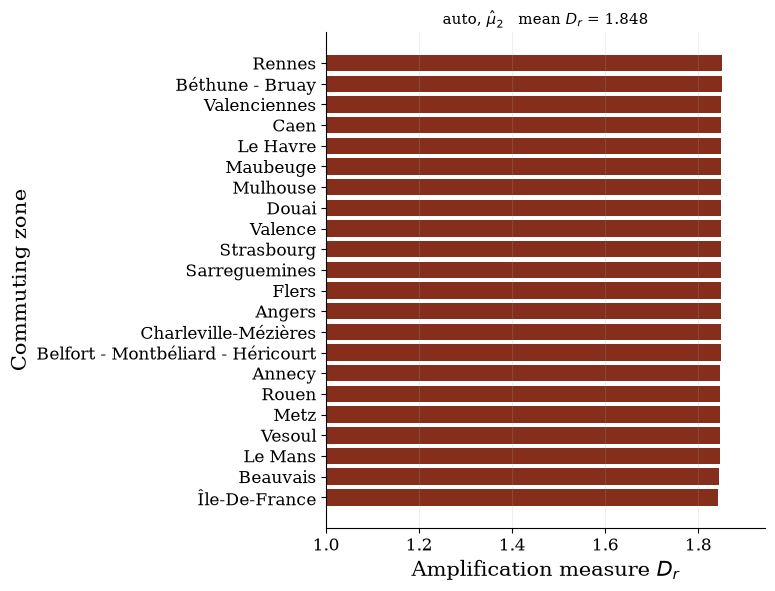

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]  variety count in suppliers.parquet:
        N_hat  varieties_in_parquet  ratio  n_replications
sector                                                    
C22B     10.0                  10.0    1.0              50
C25D     14.0                  14.0    1.0              50
C26E      9.0                   9.0    1.0              50
C27B     15.0                  15.0    1.0              50
C28A      9.0                   9.0    1.0              50
C30C     16.0                  16.0    1.0              50
C33Z      5.0                   5.0    1.0              50
G46Z      8.0                  

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,region,upstream_sales,amplification,supplier_cells,mean_upstream_distance,share_within_100km,share_within_200km
ze2010_downstream,,,,,,,
156,Brest,0.888,1.888,257,590.146,0.015,0.031
267,Cannes - Antibes,0.884,1.884,252,488.485,0.006,0.040
36,Le Havre,0.880,1.880,259,453.792,0.017,0.176
272,Marseille - Aubagne,0.878,1.878,250,395.518,0.040,0.081
193,Bayonne,0.876,1.876,251,381.133,0.057,0.223
273,Istres - Martigues,0.876,1.876,250,366.930,0.046,0.094
137,Cholet,0.874,1.874,254,335.292,0.046,0.157
7,Roissy - Sud Picardie,0.873,1.873,252,375.681,0.167,0.334
220,Valence,0.872,1.872,249,310.968,0.069,0.217


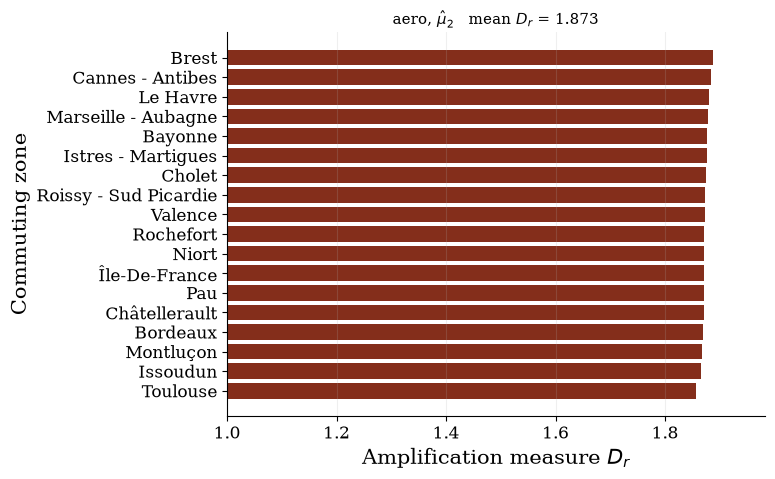

In [8]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    print(f"[{industry}, mu = {MU}]  variety count in suppliers.parquet:")
    supplier_count_check(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    print(f"\n  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    display(summ.round(3))

    plot_amplification(data, summary=summ,
                       save_to=f"{out_folder}/amplification_{industry}_mu{MU}.pdf")
    plt.show()


## Test 2 — is $D_r$ large? The input-output benchmark

Test 1 returns ~1.85. Whether that is a lot is not answerable from inside the model, so it is
read against the Leontief multipliers of the IO table.

**Two comparisons need no output data and come first**, because they are the ones that can be
made cleanly. The COMPOSITION of the downstream column — the $\pi_s$ object the $\Omega_s$
were calibrated on — against the model's simulated sector split; and the COVERAGE, the
modelled sectors' share of the industry's domestic intermediate purchases. Then
$(D_r - 1)/\text{coverage}$ is what the model implies for the downstream firm's TOTAL
intermediate share: a number that must sit below one and near $1 - \Omega_L$ to be credible.

**What the TES block cannot support, stated rather than papered over.** The technical
coefficients $a_{ij} = X_{ij}/x_j$ need GROSS OUTPUT, and the intermediate-flow block has no
value-added row, so each column must be normalised to an intermediate share supplied from
outside. Under a COMMON $m$ every column of $A$ sums to $m$, hence $\sum_i (A^k)_{ij} = m^k$
and the Leontief total is exactly $1/(1-m)$ for every sector — the cascade then measures the
assumption, not the network. The scalar path runs and says so loudly; pass a per-sector
`intermediate_share` for the informative answer.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto]  downstream industry C29A, TES from ../baseline_auto (dom), intermediate share m = 0.8448979386516853
  model  : mean D_r = 1.848  -> the modelled domestic sectors are 0.848 of downstream unit cost
  IO     : those sectors are 63.5% of the industry's DOMESTIC intermediate purchases (67.3% of dom + imp; the column is 59.0% domestic)
           => implied TOTAL intermediate share of unit cost = 1.336
           1 - aggregate labor share (the targeted moment) = 0.845
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.447 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 16% of the aggregate, 100% of round 1)
  IO subset: round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 16% of the aggregate, 100% of rou

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.845,2.559,6.447,1.848,0.156,1.004
subset,10,1.845,2.559,6.447,1.848,0.156,1.004


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C29A,1305.992,3491.482,4797.474,True,0.1602,0.0739,0.2380,0.2475
C29B,1264.404,1907.007,3171.411,True,0.1059,0.0715,0.1573,0.1385
G45Z,2368.608,0.000,2368.608,True,0.0791,0.1340,0.1175,0.1266
C28A,385.795,1799.754,2185.549,True,0.0730,0.0218,0.1084,0.1117
G46Z,1874.860,179.963,2054.823,True,0.0686,0.1060,0.1019,0.1063
C25D,1606.833,0.000,1606.833,True,0.0536,0.0909,0.0797,0.0688
C22B,841.858,514.752,1356.610,True,0.0453,0.0476,0.0673,0.0686
C33Z,1150.074,90.690,1240.764,True,0.0414,0.0650,0.0616,0.0672
M73Z,663.758,218.441,882.199,False,0.0295,0.0375,NaN,NaN


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


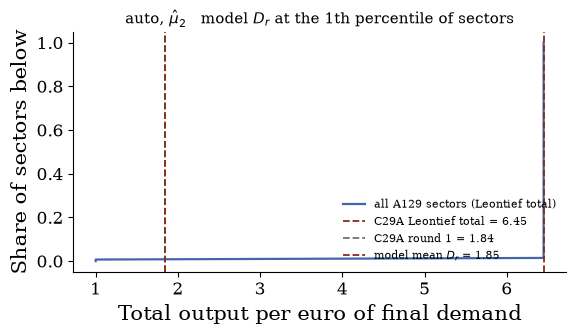

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero]  downstream industry C30C, TES from ../baseline_aero (dom), intermediate share m = 0.8510782076751053
  model  : mean D_r = 1.873  -> the modelled domestic sectors are 0.873 of downstream unit cost
  IO     : those sectors are 72.3% of the industry's DOMESTIC intermediate purchases (80.5% of dom + imp; the column is 45.8% domestic)
           => implied TOTAL intermediate share of unit cost = 1.208
           1 - aggregate labor share (the targeted moment) = 0.851
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.715 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 103% of round 1)
  IO subset: round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 103% of rou

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.851,2.575,6.715,1.873,0.153,1.026
subset,10,1.851,2.575,6.715,1.873,0.153,1.026


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C30C,6349.585,16899.867,23249.452,True,0.4979,0.2972,0.6184,0.5639
C33Z,4340.815,342.295,4683.110,True,0.1003,0.2032,0.1246,0.1366
C26E,12.912,2563.343,2576.255,True,0.0552,0.0006,0.0685,0.0811
G46Z,2124.009,203.879,2327.888,True,0.0499,0.0994,0.0619,0.0869
C28A,269.091,1255.322,1524.413,True,0.0326,0.0126,0.0405,0.0357
N78Z,977.000,0.000,977.000,False,0.0209,0.0457,NaN,NaN
M70Z,828.542,55.679,884.221,True,0.0189,0.0388,0.0235,0.0230
M71Z,569.876,148.231,718.107,True,0.0154,0.0267,0.0191,0.0247
C27B,110.626,468.915,579.541,True,0.0124,0.0052,0.0154,0.0202


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


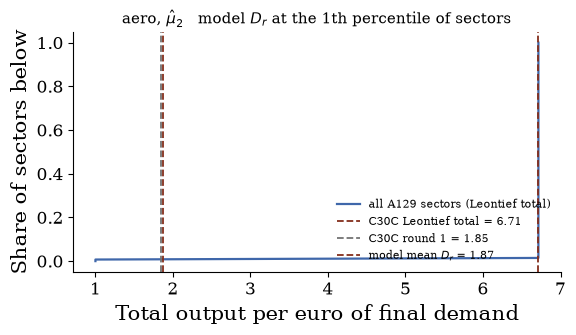

In [9]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    # Guarded: without TES_dom.csv / TES_imp.csv beside the run this prints a note
    # instead of breaking the test.
    try:
        summ = amplification_summary(data, radii=AMPLIFICATION_RADII)
        bench = io_amplification_benchmark(data, summary=summ)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")


## Test 3 — how far does the response travel?

Amplification says how large the response is, not where it lands. The first incidence
statistic is the distance the euro covers:

$$d_r = \frac{\sum_{r'} X_{r'r}\, d_{r'r}}{\sum_{r'} X_{r'r}}.$$

One number in kilometres, aggregating the whole geography of the response rather than one
radius, and the object the alignment identity of §4 governs directly.

**Two things this test does NOT settle, and says so.** The LEVEL identifies nothing on its
own: ~350 km in both industries, which is neither which force is holding the euro there nor
whether the two industries hold it there for the same reason. That is test 4. And the
cross-buyer DISPERSION of $d_r$ is partly the shape of the country — a buyer in Brest faces a
larger $d_r$ than one in Bourges under *any* allocation — which is what
`distance_normalisation` removes by dividing through the uniform-allocation distance,
anchoring the statistic at one.

Both the CDF and the histogram are drawn. The CDF is the better object for a SHIFT (the
horizontal gap between two curves is the effect at every quantile, and it uses every point
exactly); the histogram is the better object for a SHAPE. With only ~20 shocked regions the
histogram is sensitive to `bins` in a way the CDF is not — vary `bins` before believing a mode.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]  d_r: mean 347.2 km, median 358.7, min 257.3, max 407.1


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  d_r normalised by the uniform-allocation distance (1 = as far as an unselective allocation would send it):
                             mean    50%    min    max
regime                                                
Realised                    0.798  0.783  0.684  1.079
Both forces                 0.799  0.781  0.689  1.084
Distance only               0.942  0.942  0.925  0.952
Comparative advantage only  0.852  0.836  0.760  1.141


region  \
ze2010_downstream regime                                             
12                Realised                           Île-De-France   
                  Both forces                        Île-De-France   
                  Distance only                      Île-De-France   
                  Comparative advantage only         Île-De-France   
13                Realised                    Charleville-Mézières   
...                                                            ...   
220               Comparative advantage only               Valence   
230               Realised                                  Annecy   
                  Both forces                               Annecy   
                  Distance only                             Annecy   
                  Comparative advantage only                Annecy   

                                              mean_upstream_distance  \
ze2010_downstream regime                                               
12                Realised                                   257.279   
                  Both forces                                258.999   
                  Distance only                              352.579   
                  Comparative advantage only                 285.713   
13                Realised                                   338.231   
...                                                              ...   
220               Comparative advantage only                 380.935   
230               Realised                                   338.291   
                  Both forces                                337.793   
                  Distance only                              328.173   
                  Comparative advantage only                 359.319   

                                              uniform_distance  distance_ratio  
ze2010_downstream regime                                                        
12                Realised                             376.070           0.684  
                  Both forces                          376.070           0.689  
                  Distance only                        376.070           0.938  
                  Comparative advantage only           376.070           0.760  
13                Realised                             462.952           0.731  
...                                                        ...             ...  
220               Comparative advantage only           333.956           1.141  
230               Realised                             352.768           0.959  
                  Both forces                          352.768           0.958  
                  Distance only                        352.768           0.930  
                  Comparative advantage only           352.768           1.019  

[88 rows x 4 columns]

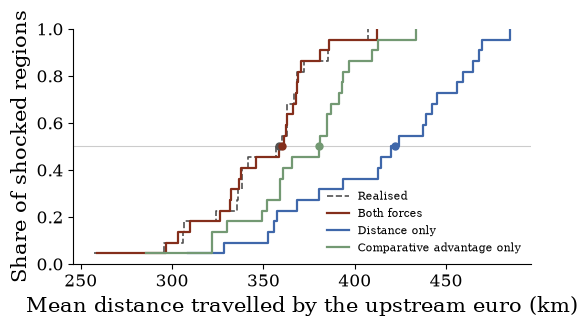

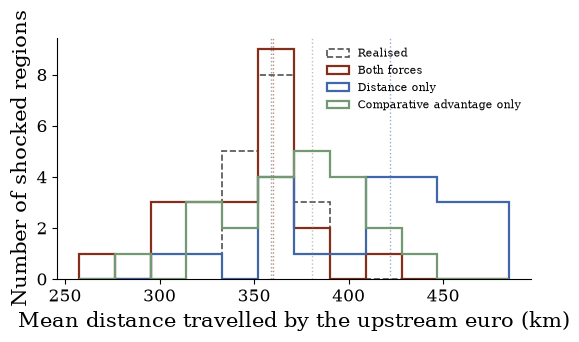

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]  d_r: mean 353.3 km, median 333.3, min 252.9, max 590.1


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  d_r normalised by the uniform-allocation distance (1 = as far as an unselective allocation would send it):
                             mean    50%    min    max
regime                                                
Realised                    0.878  0.908  0.640  0.981
Both forces                 0.881  0.908  0.639  0.981
Distance only               0.882  0.888  0.826  0.944
Comparative advantage only  0.967  0.973  0.797  1.124


region  \
ze2010_downstream regime                                              
7                 Realised                    Roissy - Sud Picardie   
                  Both forces                 Roissy - Sud Picardie   
                  Distance only               Roissy - Sud Picardie   
                  Comparative advantage only  Roissy - Sud Picardie   
11                Realised                                 Toulouse   
...                                                             ...   
272               Comparative advantage only    Marseille - Aubagne   
273               Realised                       Istres - Martigues   
                  Both forces                    Istres - Martigues   
                  Distance only                  Istres - Martigues   
                  Comparative advantage only     Istres - Martigues   

                                              mean_upstream_distance  \
ze2010_downstream regime                                               
7                 Realised                                   375.681   
                  Both forces                                376.802   
                  Distance only                              332.152   
                  Comparative advantage only                 434.096   
11                Realised                                   252.917   
...                                                              ...   
272               Comparative advantage only                 434.234   
273               Realised                                   366.930   
                  Both forces                                368.562   
                  Distance only                              378.553   
                  Comparative advantage only                 405.575   

                                              uniform_distance  distance_ratio  
ze2010_downstream regime                                                        
7                 Realised                             386.066           0.973  
                  Both forces                          386.066           0.976  
                  Distance only                        386.066           0.860  
                  Comparative advantage only           386.066           1.124  
11                Realised                             395.398           0.640  
...                                                        ...             ...  
272               Comparative advantage only           450.783           0.963  
273               Realised                             427.406           0.859  
                  Both forces                          427.406           0.862  
                  Distance only                        427.406           0.886  
                  Comparative advantage only           427.406           0.949  

[72 rows x 4 columns]

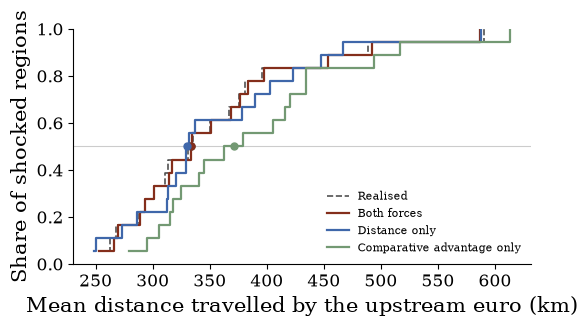

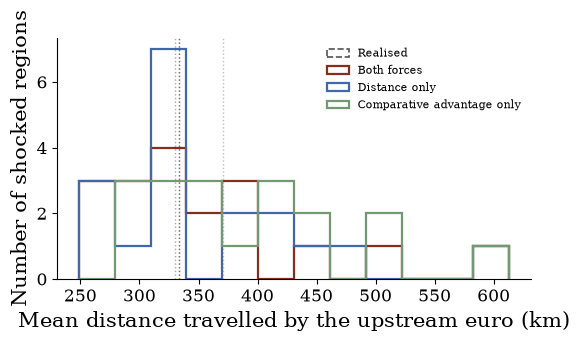

In [10]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    print(f"[{industry}, mu = {MU}]  d_r: mean {summ['mean_upstream_distance'].mean():.1f} km, "
          f"median {summ['mean_upstream_distance'].median():.1f}, "
          f"min {summ['mean_upstream_distance'].min():.1f}, "
          f"max {summ['mean_upstream_distance'].max():.1f}")

    # d_r purged of the country's shape: 1 = as far as an unselective allocation sends it
    display(distance_normalisation(data, diffusion=diff).round(3))

    plot_distance_distribution(data, diffusion=diff,
                               save_to=f"{out_folder}/counterfactual_distance_{industry}_mu{MU}.pdf")
    plt.show()
    plot_distance_histogram(data, diffusion=diff,
                            save_to=f"{out_folder}/counterfactual_distance_hist_{industry}_mu{MU}.pdf")
    plt.show()


## Test 4 — which force keeps the euro close?

The sourcing probabilities are closed form, so the same shock can be propagated with either
allocative force switched off. What is held FIXED is what the model makes a cost-share object
— how much of the euro leaves for upstream, and how it splits across SECTORS, neither of which
involves $T$ or $\alpha$. What moves is where inside a sector the euro lands.

**Two consequences, both load-bearing.** Since $\sum_l \rho_{lrs} = 1$ for every (sector,
buyer), $D_r$ is IDENTICAL under every regime: cancelling a channel moves a shock in space
without changing its size. That is why every counterfactual figure is about incidence and none
re-draws $D_r$, and it is gated to machine precision. And `Both forces` is the closed-form
EXPECTATION of the allocation while the parquet is one realised finite-variety draw of it, so
the two differ by granularity — the gap is printed, and the closed-form row, not the realised
one, is the baseline the other regimes are read against.

**The two regimes are not symmetric interventions.** Equalising $\hat T$ removes a
*supplier*-specific term; setting $\alpha = 0$ removes the *only buyer-specific* term in
$\rho_{lrs} \propto T_{a(l)s} d_{lr}^{-\theta\alpha}$. Any statistic measuring how much of its
own position a buyer's sourcing inherits must therefore go to zero under $\alpha = 0$ by
construction — that regime is an internal control on such a statistic, not an economic
counterfactual to be compared with the other.

By the alignment identity the movement of $d_r$ IS the co-location covariance evaluated at
that buyer, so the SHAPE of the shift is informative in a way its mean is not: a block shift
means the covariance is common across buyers, crossing curves mean the sign is not.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  [counterfactual] D_r is identical across regimes to 8.88e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.074 vs closed-form both-forces 0.073 — the gap is granularity, not a different economy

[auto, mu = 2]  the shock with one force switched off (D_r is the same in every regime by construction):
                            amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                                                                                                             
Realised                            1.848                 347.294               0.074                        0.074               0.238                        0.237
Both forces                         1.848                 347.593               0.073                        0.073               0.2

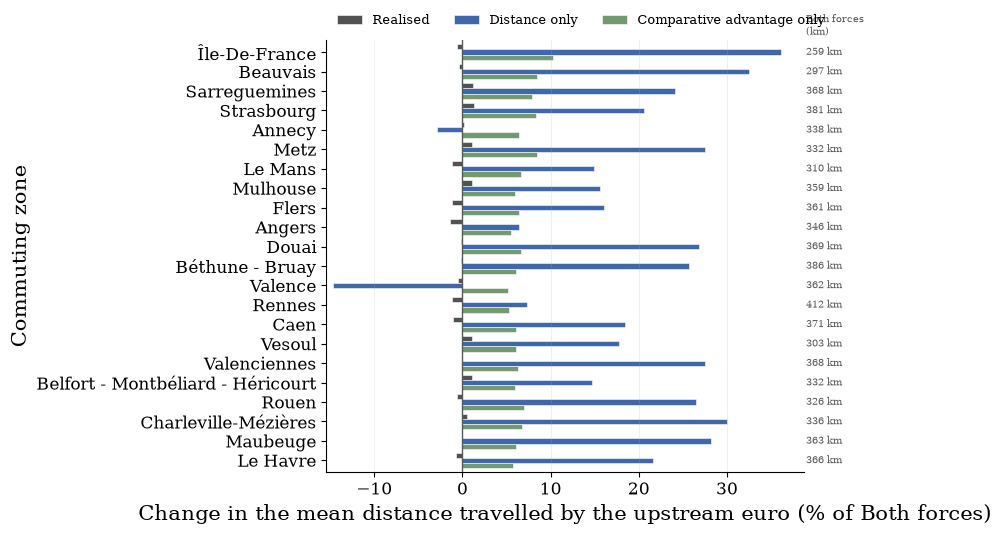

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  [counterfactual] D_r is identical across regimes to 4.44e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.088 vs closed-form both-forces 0.089 — the gap is granularity, not a different economy

[aero, mu = 2]  the shock with one force switched off (D_r is the same in every regime by construction):
                            amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                                                                                                             
Realised                            1.873                 353.850               0.088                        0.088               0.213                        0.212
Both forces                         1.873                 355.162               0.089                        0.088               0.2

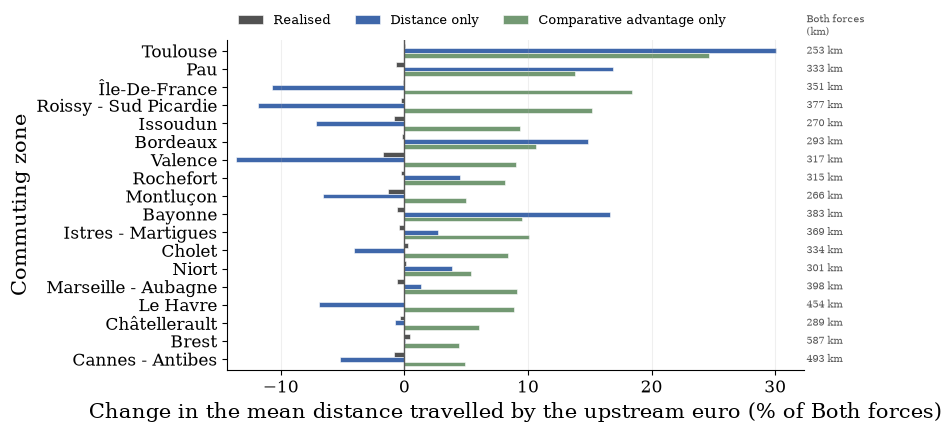

In [11]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    diff   = build_diffusion_frame(data)
    frames = counterfactual_frames(data, diffusion=diff)
    det    = counterfactual_amplification(data, radii=AMPLIFICATION_RADII,
                                          frames=frames, diffusion=diff)

    print(f"\n[{industry}, mu = {MU}]  the shock with one force switched off "
          "(D_r is the same in every regime by construction):")
    print(counterfactual_summary(data, radii=AMPLIFICATION_RADII, detail=det).round(3).to_string())

    # is the shift a block translation or a rotation? the quantile-by-quantile answer
    print("\n  the distribution of d_r behind that mean, and how each force shifts it:")
    print(distance_distribution_report(data, detail=det).to_string())

    plot_counterfactual_distance(
        data, detail=det,
        save_to=f"{out_folder}/counterfactual_distance_region_{industry}_mu{MU}.pdf")
    plt.show()


## Test 5 — where does the response land?

Test 4 says capability sits near demand in motor vehicles. It does not say whether that
capability is one broad mass inside the demand distribution, a set of local pockets, or a
small number of hubs — three different economies, and only the third is hub-and-spoke.

**The barycentre cannot make that distinction, and this is a defect rather than a taste.**
It is the FIRST MOMENT of the destination distribution, and a dispersed central pool and a
pair of distant hubs have nearly the same first moment: both sit near the national centre of
mass, since with four fifths of the euros spread nationally the mean is pinned there however
concentrated the remaining fifth is. That is exactly why every aerospace arrow lands in the
Massif Central while the euros are collected by Toulouse and Île-de-France. The shrinkage
coefficient $\lambda$ inherits the degeneracy — below 0.12 in both industries, separating
nothing. `barycentre_shrinkage` is still run below, as a reported robustness exhibit.

The object with the answer is the incidence vector $\omega_r = (X_{lr}/\sum_l X_{lr})_l$,
characterised by two numbers. CONCENTRATION is the effective number of destinations
$1/H_r$, reported RELATIVE to the uniform allocation because its level is mostly the sector's
cell count and the shape of the country. COMMONALITY is the euro share that is buyer-specific,
$\Delta_r = \tfrac12\sum_l|\omega_{lr} - \bar\omega_l|$, read against ZERO rather than against
a benchmark — the allocation is already nearly buyer-independent, so an overlap statistic in
levels sits at its ceiling in both industries.

The prediction is stated before the numbers: aerospace should be concentrated AND common
(bottom-left of the plane), motor vehicles spread and common.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

[auto, mu = 2]


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  the incidence vector: how concentrated, and how much is buyer-specific
  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share that is buyer-specific, read against 0)
                              n_eff  n_eff_ratio    hhi   top3  own_share  tv_common  cos_common  pairwise_cos  pairwise_tv
regime                                                                                                                     
Realised                    105.847        0.468  0.009  0.074      0.007      0.048       0.995         0.987        0.067
Both forces                 106.660        0.472  0.009  0.073      0.006      0.044       0.996         0.989        0.060
Distance only               227.252        1.004  0.004  0.024      0.005      0.037       0.994         0.986        0.056
Comparative advantage only  114.250        0.505  0.009  0.066      0.003      0.003       1.000         1.000        0.005
Uniform benchmark           226.188        1.000  0.004  0.020      0.

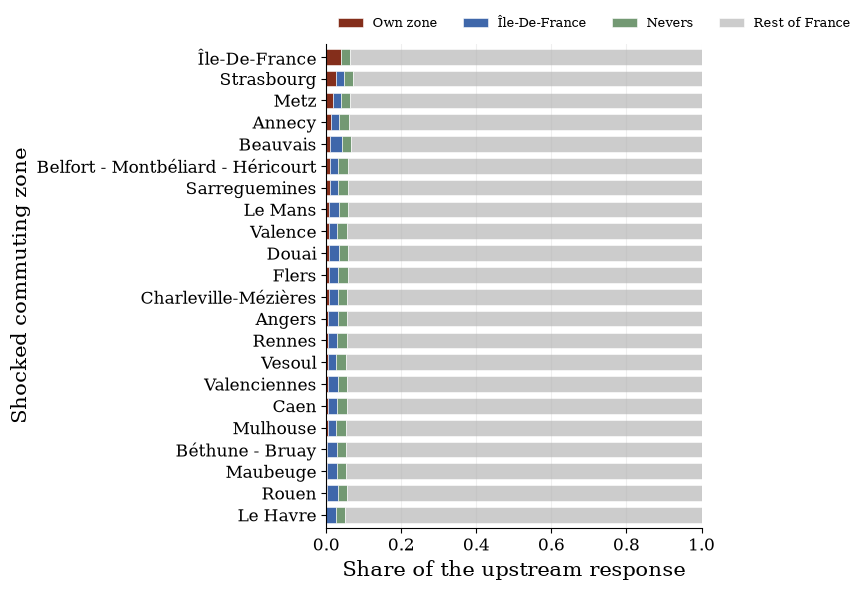

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

[aero, mu = 2]


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  the incidence vector: how concentrated, and how much is buyer-specific
  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share that is buyer-specific, read against 0)
                             n_eff  n_eff_ratio    hhi   top3  own_share  tv_common  cos_common  pairwise_cos  pairwise_tv
regime                                                                                                                    
Realised                    28.938        0.302  0.035  0.234      0.012      0.082       0.991         0.975        0.124
Both forces                 31.337        0.326  0.032  0.204      0.011      0.074       0.991         0.973        0.116
Distance only               86.661        0.895  0.012  0.085      0.009      0.103       0.955         0.875        0.157
Comparative advantage only  31.294        0.319  0.032  0.200      0.003      0.020       1.000         0.999        0.036
Uniform benchmark           98.026        1.000  0.010  0.048      0.002    

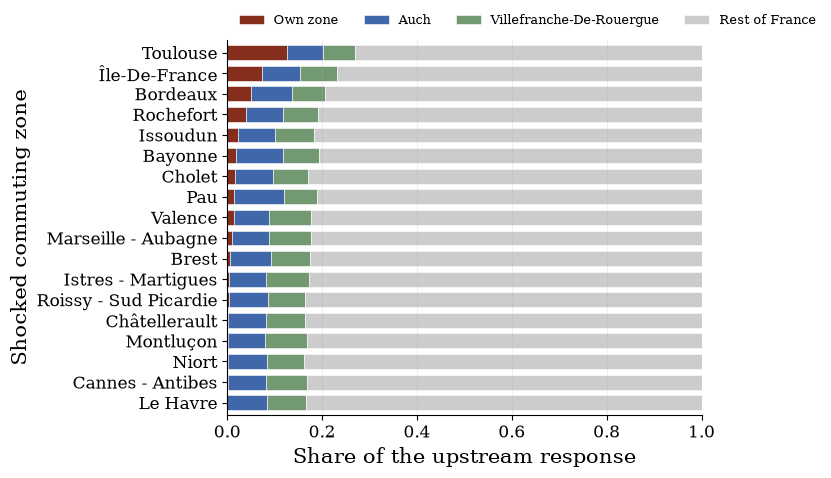

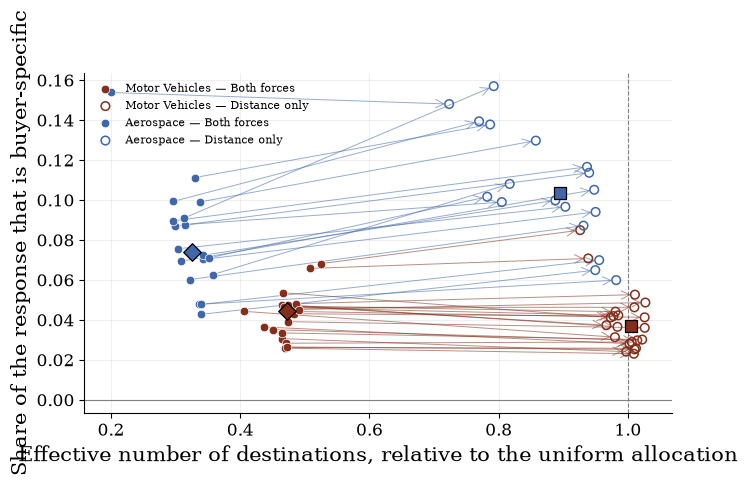

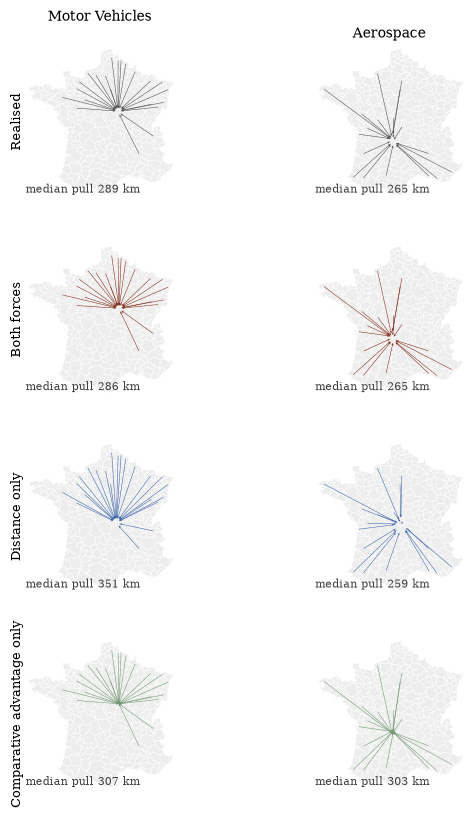

                                           slope     se       t  ci_lo  ci_hi  slope_x  slope_y     r2  dispersion_ratio  median_pull_km  median_distance_km     n
industry       regime                                                                                                                                             
Aerospace      Both forces                 0.080  0.009   8.904  0.062  0.098    0.060    0.097  0.846             0.087         264.600             335.014  18.0
               Comparative advantage only -0.023  0.007  -3.274 -0.036 -0.009   -0.002   -0.040  0.374             0.037         302.729             372.621  18.0
               Distance only               0.121  0.014   8.849  0.094  0.148    0.113    0.128  0.871             0.130         259.301             334.260  18.0
               Realised                    0.082  0.009   8.799  0.064  0.101    0.064    0.097  0.852             0.089         264.645             334.360  18.0
Motor Vehicles Both fo

slope     se       t  ci_lo  ci_hi  \
industry       regime                                                           
Aerospace      Both forces                 0.080  0.009   8.904  0.062  0.098   
               Comparative advantage only -0.023  0.007  -3.274 -0.036 -0.009   
               Distance only               0.121  0.014   8.849  0.094  0.148   
               Realised                    0.082  0.009   8.799  0.064  0.101   
Motor Vehicles Both forces                 0.065  0.002  34.472  0.062  0.069   
               Comparative advantage only -0.003  0.000 -11.668 -0.003 -0.002   
               Distance only               0.069  0.004  19.571  0.062  0.076   
               Realised                    0.068  0.002  33.809  0.064  0.072   

                                           slope_x  slope_y     r2  \
industry       regime                                                
Aerospace      Both forces                   0.060    0.097  0.846   
               Comparative advantage only   -0.002   -0.040  0.374   
               Distance only                 0.113    0.128  0.871   
               Realised                      0.064    0.097  0.852   
Motor Vehicles Both forces                   0.067    0.062  0.961   
               Comparative advantage only   -0.003   -0.002  0.830   
               Distance only                 0.067    0.073  0.955   
               Realised                      0.068    0.068  0.964   

                                           dispersion_ratio  median_pull_km  \
industry       regime                                                         
Aerospace      Both forces                            0.087         264.600   
               Comparative advantage only             0.037         302.729   
               Distance only                          0.130         259.301   
               Realised                               0.089         264.645   
Motor Vehicles Both forces                            0.067         286.461   
               Comparative advantage only             0.003         307.104   
               Distance only                          0.070         351.112   
               Realised                               0.069         288.858   

                                           median_distance_km     n  
industry       regime                                                
Aerospace      Both forces                            335.014  18.0  
               Comparative advantage only             372.621  18.0  
               Distance only                          334.260  18.0  
               Realised                               334.360  18.0  
Motor Vehicles Both forces                            353.820  22.0  
               Comparative advantage only             375.454  22.0  
               Distance only                          419.197  22.0  
               Realised                               355.277  22.0

,a,b,diff,se,t,ci_lo,ci_hi
0,Aerospace / Comparative advantage only,Aerospace / Both forces,-0.103,0.011,-9.053,-0.125,-0.080
1,Aerospace / Distance only,Aerospace / Both forces,0.041,0.016,2.512,0.009,0.073
2,Aerospace / Realised,Aerospace / Both forces,0.002,0.013,0.172,-0.023,0.028
3,Motor Vehicles / Comparative advantage only,Motor Vehicles / Both forces,-0.068,0.002,-35.622,-0.072,-0.064
4,Motor Vehicles / Distance only,Motor Vehicles / Both forces,0.003,0.004,0.796,-0.005,0.011
5,Motor Vehicles / Realised,Motor Vehicles / Both forces,0.002,0.003,0.863,-0.003,0.008
6,Motor Vehicles / Both forces,Aerospace / Both forces,-0.015,0.009,-1.588,-0.033,0.003



Motor Vehicles — where the arrows point (realised economy):


,hub_index,n_regions,sales,share_of_regions
hub,,,,
Cosne - Clamecy,3,19,16.111,0.864



Aerospace — where the arrows point (realised economy):


,hub_index,n_regions,sales,share_of_regions
hub,,,,
Ussel,210,5,4.378,0.278
Tulle,209,3,2.604,0.167
Guéret,211,2,1.744,0.111


In [12]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
incidence_tables, panel_data = [], []
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    panel_data.append(data)
    globals().update(data)

    diff   = build_diffusion_frame(data)
    frames = counterfactual_frames(data, diffusion=diff)

    print(f"\n[{industry}, mu = {MU}]")
    inc = incidence_concentration_overlap(data, frames=frames, diffusion=diff)
    incidence_tables.append((cfg["display_name"], inc))
    incidence_summary(inc)

    # the figure that replaces the barycentre arrows: own zone, the industry's hubs, rest
    plot_destination_composition(
        data, diffusion=diff,
        save_to=f"{out_folder}/destination_composition_{industry}_mu{MU}.pdf")
    plt.show()

# the 2x2 plane, both industries on one window
plot_incidence_plane(incidence_tables, save_to=f"{out_folder}/incidence_plane_mu{MU}.pdf")
plt.show()

# The barycentre, kept as a reported robustness exhibit rather than as the answer.
# Guarded: without france.gpkg (or geopandas) there is no geometry to place one in.
try:
    fig, barys = barycentre_panel(
        [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, panel_data)],
        save_to=f"{out_folder}/sourcing_barycentre_panel_mu{MU}.pdf")
    plt.show()
    shrink = barycentre_shrinkage_report(barys)
    display(shrink.round(3))
    display(barycentre_shrinkage_contrast(shrink).round(3))
    for cfg, d in zip(INDUSTRIES, panel_data):
        print(f"\n{cfg['display_name']} — where the arrows point (realised economy):")
        display(barycentre_hubs(d).round(3))
except (FileNotFoundError, KeyError, ValueError) as e:
    print(f"  barycentre panel skipped: {type(e).__name__}: {e}")


## Test 6 — how much of the shock does the region keep?

How far the euro travels is not the same question as how much of it the shocked region
retains, and it is the second that the reduced-form part of the paper measures:

$$L_r(d) = \frac{\sum_{r' : d_{r'r} \le d} X_{r'r}}{\sum_{r'} X_{r'r}}.$$

The denominator is UPSTREAM SALES ONLY — the euro of downstream demand is not in it — so it is
a share of what propagates. The radius is a free parameter throughout; the headline is 200 km,
the radius of the reduced-form evidence, and `local_share_profile` sweeps it so that number is
visibly one point on a CDF rather than assumed robust.

**This is where the sign reversal lives, and it is the section's sharpest result.** In motor
vehicles the two forces reinforce: removing either lowers the local share. In aerospace they
work against each other — equalising $\hat T$ *raises* it. Comparative advantage there is not a
localising force at all: it takes the response off the region where the shock starts and sends
it to the hubs. That is precisely the reallocation the average distance of test 4 nearly
cancels, which is why $d_r$ and $L_r$ are both needed rather than one being a check on the
other.

The map is drawn because $L_r(d)$ is a number attached to a PLACE, and a bar chart sorted by
value destroys exactly the geography the result claims. Its colour scale is PINNED and shared
across the pair: the content is that aerospace reaches 0.56 where motor vehicles never passes
0.44, and a per-panel scale would rescale that away and paint the two maps alike.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto]  within 100 km: mean 0.074, median 0.059, min 0.024, max 0.180
[auto]  within 200 km: mean 0.238, median 0.213, min 0.155, max 0.437


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


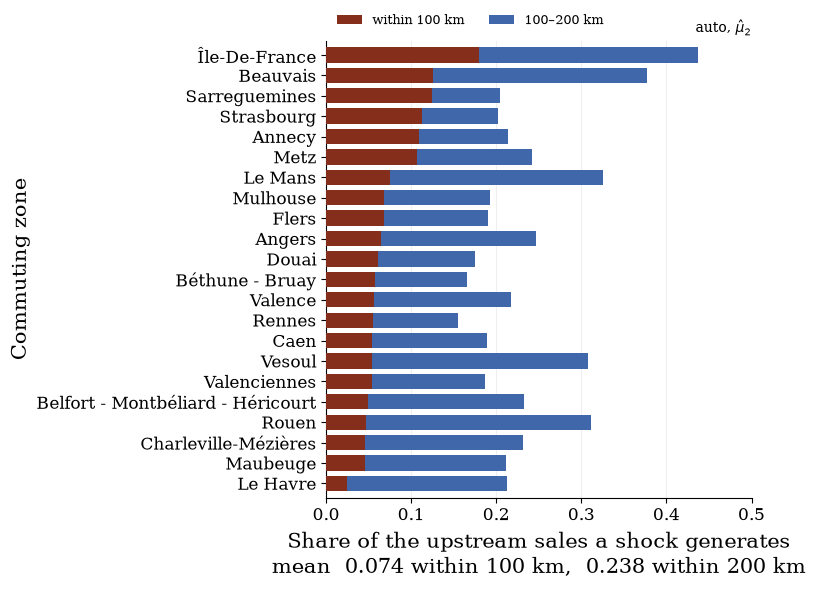

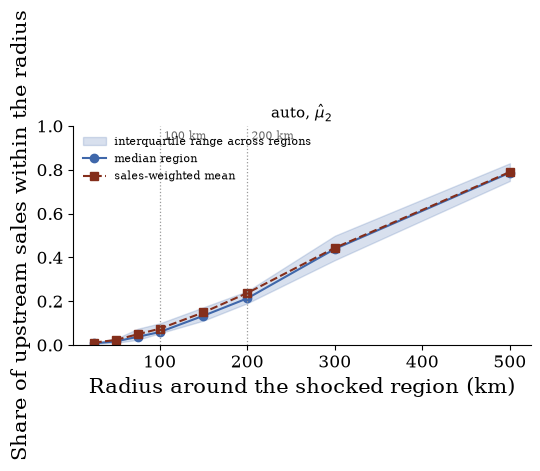

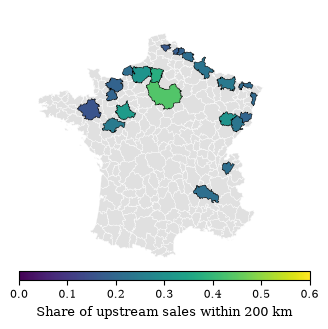

  [counterfactual] D_r is identical across regimes to 8.88e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.074 vs closed-form both-forces 0.073 — the gap is granularity, not a different economy


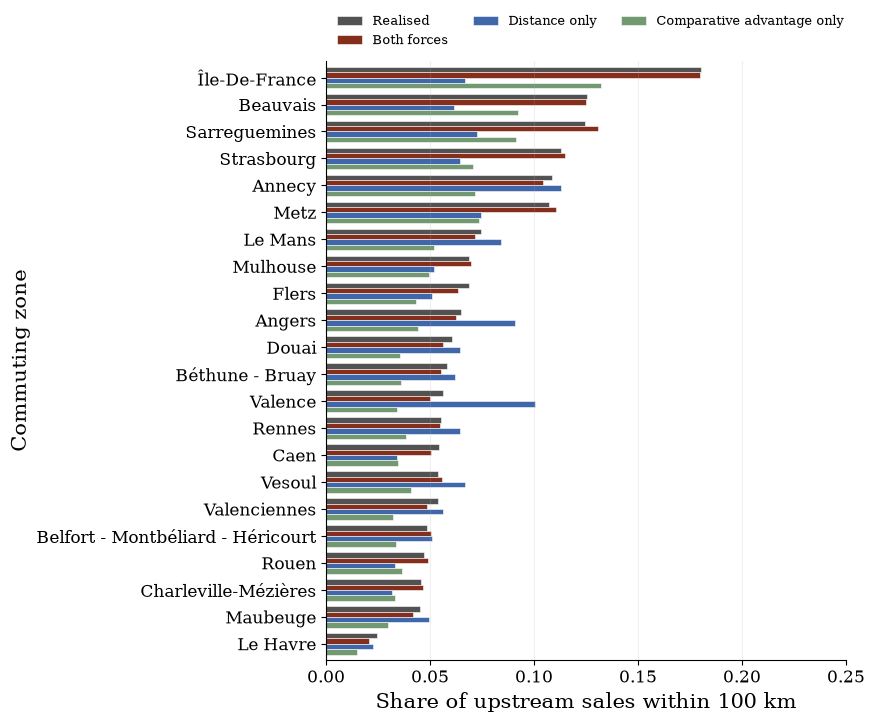

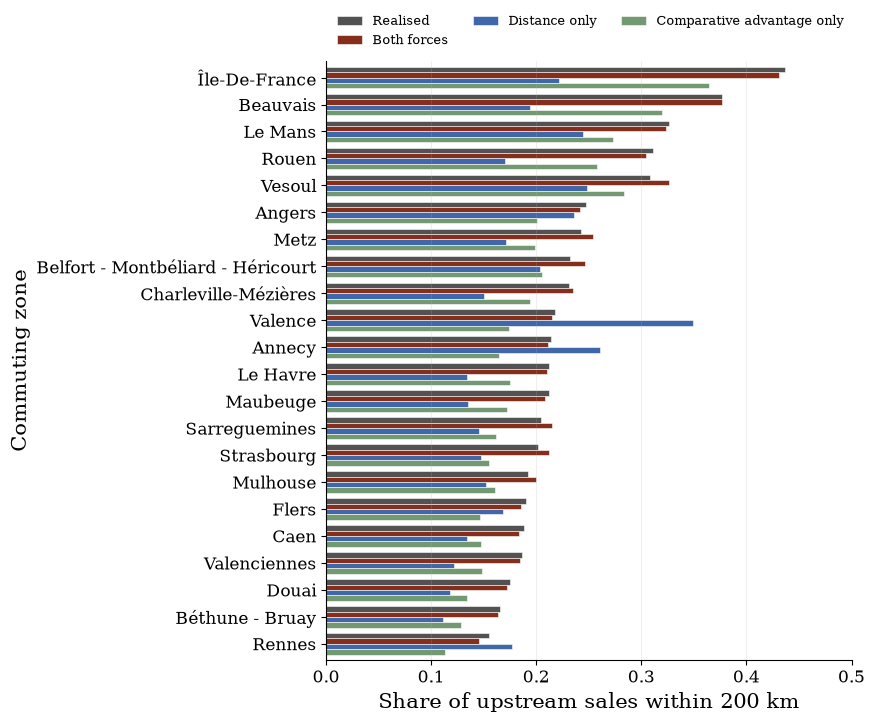

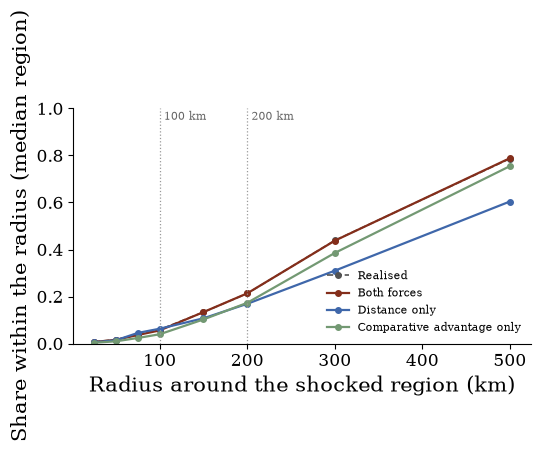

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero]  within 100 km: mean 0.088, median 0.058, min 0.006, max 0.392
[aero]  within 200 km: mean 0.213, median 0.197, min 0.031, max 0.563


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


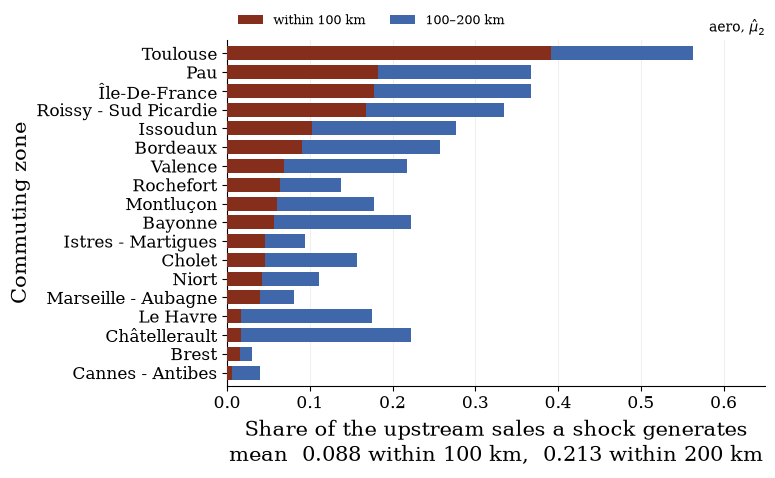

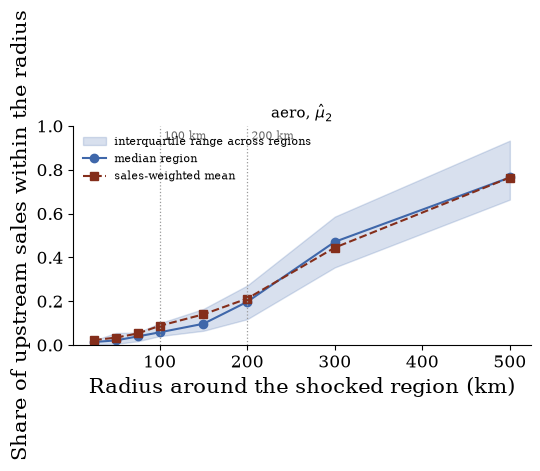

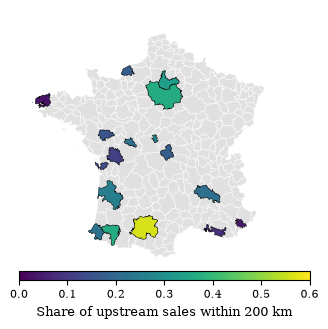

  [counterfactual] D_r is identical across regimes to 4.44e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.088 vs closed-form both-forces 0.089 — the gap is granularity, not a different economy


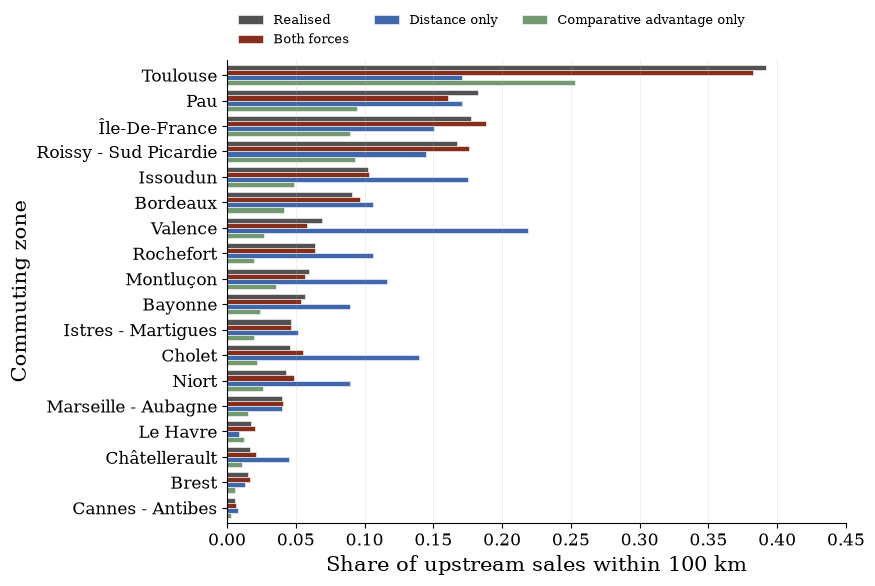

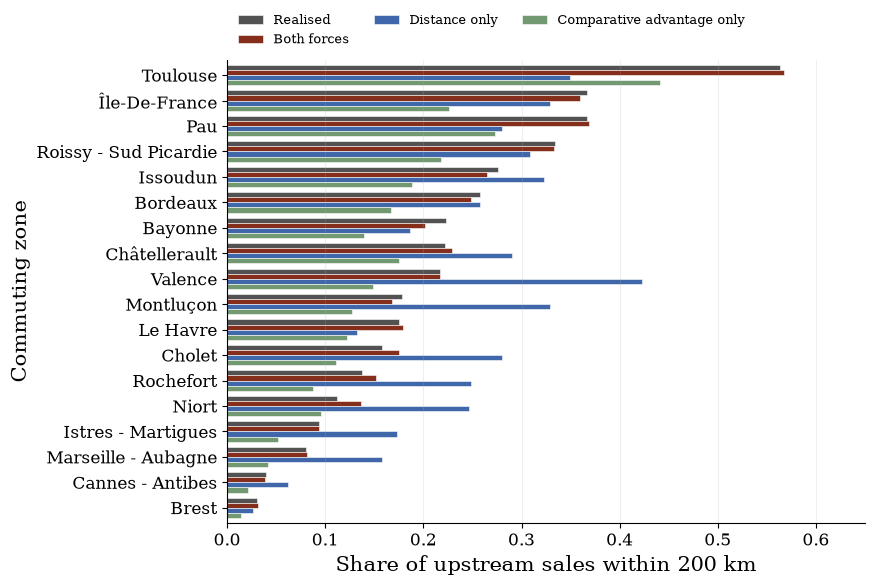

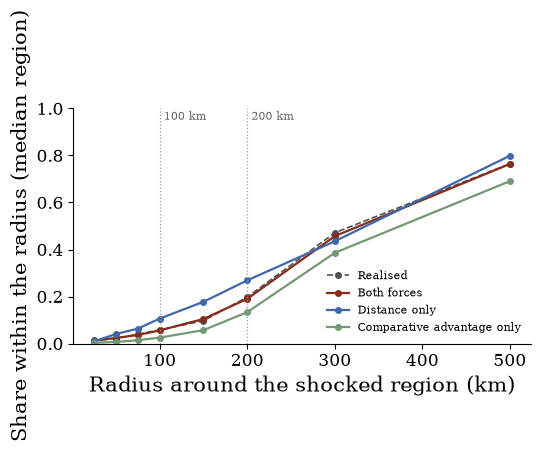

In [13]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    prof = local_share_profile(data, diffusion=diff)

    for d in AMPLIFICATION_RADII:
        c = f"share_within_{int(d)}km"
        print(f"[{industry}]  within {d:g} km: mean {summ[c].mean():.3f}, "
              f"median {summ[c].median():.3f}, min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    plot_local_share(data, radii=AMPLIFICATION_RADII, summary=summ,
                     save_to=f"{out_folder}/local_share_{industry}_mu{MU}.pdf")
    plt.show()
    plot_local_share_profile(data, profile=prof, mark=AMPLIFICATION_RADII,
                             save_to=f"{out_folder}/local_share_profile_{industry}_mu{MU}.pdf")
    plt.show()

    # the map: L_r(d) is a number attached to a place. Guarded on the geometry.
    try:
        plot_local_share_map(data, radius_km=AMPLIFICATION_RADII[-1], summary=summ,
                             vlim=LOCAL_SHARE_MAP_VLIM_WIDE,
                             save_to=f"{out_folder}/local_share_map{int(AMPLIFICATION_RADII[-1])}km_{industry}_mu{MU}.pdf")
        plt.show()
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  local-share map skipped: {type(e).__name__}: {e}")

    # the sign reversal, region by region and as the whole profile
    det = counterfactual_amplification(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    for d in AMPLIFICATION_RADII:
        plot_counterfactual_local_share(
            data, radius_km=d, detail=det,
            save_to=f"{out_folder}/counterfactual_local_share{int(d)}km_{industry}_mu{MU}.pdf")
        plt.show()
    plot_counterfactual_profile(data, mark=AMPLIFICATION_RADII, diffusion=diff,
                                save_to=f"{out_folder}/counterfactual_profile_{industry}_mu{MU}.pdf")
    plt.show()


## Test 7 — what does the finite variety count cost?

With $N_s$ finite the network is a RANDOM object, so no single realisation is a result. This
test is not a caveat on tests 1–6; it measures something they cannot see.

**What is invariant, and why.** Under Fréchet the identity of a variety's winner is
independent of its realised price, so conditionally on prices the location indicators are
i.i.d. and independent of them: $\mathbb{E}[L_r(d)]$ is EXACTLY invariant to $N_s$ — the same
argument that gives $\hat q \perp N_s$. The point estimates of tests 1, 3 and 6 were therefore
right whatever the variety count.

**What is not.** The SUPPORT: a buyer sources $\sum_s \hat N_s$ varieties, so a shock reaches a
few dozen origins rather than every commuting zone, and the loss is larger in the industry
where comparative advantage concentrates sourcing. The DISPERSION: the spread of $L_r(100)$
across realisations is of the same order as its mean, so the cross-region contrast the map
reports (a contrast of expectations) stands while a statement about one region in one year does
not. And $D_r$ rises: the within-sector index is convex in the draws, so a finite basket is on
average dearer, and with $\lambda < 1$ that raises the intermediate share — the price-index
channel, which is why the gap from the continuum is not sampling noise.


In [14]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    print(f"[{industry}, mu = {MU}]")
    try:
        granularity_report(data, radii=AMPLIFICATION_RADII)
        # the spread one draw carries, region by region
        display(granular_band(data, radii=AMPLIFICATION_RADII).round(3))
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  granularity report skipped: {type(e).__name__}: {e}")


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  granularity = the finite-variety economy minus its N_s -> infinity limit (50 realisations):
                        granular_mean  sd_across_draws  continuum  granularity  granularity_rel
quantity                                                                                       
amplification                  1.8480           0.0115     1.8378       0.0102           0.0055
mean_upstream_distance       347.2472          23.6606   345.7733       1.4739           0.0043
supplier_cells               112.9336           5.5331   273.2273    -160.2936          -0.5867
share_within_100km             0.0745           0.0301     0.0749      -0.0004          -0.0050
share_within_200km             0.2376           0.0510     0.2389      -0.0013          -0.0055
  a shock reaches 113 origins with N_hat_s varieties against 273 in the continuum — the extensive margin is the whole of what granularity is for.


,region,amplification,amplification_sd,mean_upstream_distance,mean_upstream_distance_sd,supplier_cells,supplier_cells_sd,share_within_100km,share_within_100km_sd,share_within_200km,share_within_200km_sd,n_replications
ze2010_downstream,,,,,,,,,,,,
12,Île-De-France,1.842,0.012,257.290,21.134,109.74,5.678,0.180,0.046,0.437,0.058,50
13,Charleville-Mézières,1.848,0.011,338.270,24.214,111.52,5.339,0.046,0.020,0.231,0.048,50
26,Beauvais,1.845,0.012,295.575,22.965,110.90,5.614,0.126,0.041,0.377,0.062,50
36,Le Havre,1.849,0.011,363.149,24.844,113.72,5.789,0.024,0.021,0.212,0.051,50
37,Rouen,1.847,0.012,324.287,24.289,112.52,6.018,0.047,0.024,0.311,0.064,50
58,Caen,1.849,0.011,366.721,26.145,114.68,5.593,0.054,0.036,0.189,0.053,50
68,Flers,1.849,0.011,357.089,25.632,114.92,5.428,0.069,0.039,0.190,0.051,50
88,Douai,1.849,0.011,368.355,23.505,113.00,5.406,0.061,0.026,0.175,0.040,50
89,Valenciennes,1.849,0.011,368.352,23.353,112.78,5.327,0.054,0.024,0.186,0.041,50


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  granularity = the finite-variety economy minus its N_s -> infinity limit (50 realisations):
                        granular_mean  sd_across_draws  continuum  granularity  granularity_rel
quantity                                                                                       
amplification                  1.8733           0.0171     1.8608       0.0124           0.0067
mean_upstream_distance       353.2472          30.5876   352.8476       0.3996           0.0011
supplier_cells                61.6422           3.3333   261.5000    -199.8578          -0.7643
share_within_100km             0.0883           0.0467     0.0924      -0.0041          -0.0441
share_within_200km             0.2129           0.0736     0.2122       0.0007           0.0035
  a shock reaches 62 origins with N_hat_s varieties against 262 in the continuum — the extensive margin is the whole of what granularity is for.


,region,amplification,amplification_sd,mean_upstream_distance,mean_upstream_distance_sd,supplier_cells,supplier_cells_sd,share_within_100km,share_within_100km_sd,share_within_200km,share_within_200km_sd,n_replications
ze2010_downstream,,,,,,,,,,,,
7,Roissy - Sud Picardie,1.873,0.019,375.326,44.264,57.92,3.680,0.168,0.062,0.334,0.087,50
11,Toulouse,1.857,0.015,253.227,38.852,59.06,3.053,0.391,0.111,0.562,0.095,50
12,Île-De-France,1.871,0.019,350.262,45.077,56.54,3.512,0.178,0.067,0.367,0.092,50
36,Le Havre,1.880,0.017,453.455,39.915,59.82,3.607,0.017,0.016,0.176,0.060,50
45,Issoudun,1.866,0.020,267.270,25.550,60.46,3.610,0.102,0.061,0.277,0.102,50
137,Cholet,1.874,0.017,335.252,23.200,61.94,3.216,0.046,0.034,0.157,0.065,50
156,Brest,1.888,0.016,590.059,28.932,62.14,3.314,0.015,0.017,0.031,0.029,50
170,Châtellerault,1.871,0.018,287.374,20.220,61.54,3.327,0.016,0.020,0.222,0.088,50
176,Rochefort,1.872,0.016,313.911,25.298,62.34,3.185,0.063,0.055,0.137,0.070,50
